# IEEE 8500-node feeder — OpenDSS timing (GNN2)

**This notebook file:** `IEEE8500_OpenDSS_timing.ipynb` (in your `GNN2` project folder)

**Not** the `8500-node` **folder** — that folder only holds OpenDSS `.dss` data files.

**Goal:** find `Master.dss`, run snapshot power flow, and measure **median `Solve()` time (ms)** to compare later with GNN inference at batch size 1.

| Step | What |
|------|------|
| **1** | Point OpenDSS at `Master.dss` |
| **2** | Load circuit + time 50 snapshot solves |
| **3** | Generate load-type CSVs (`run_loadtype_dataset_8500`) |
| **4** | Build `edge_index` / `edge_attr` (`build_graph_8500`) |
| **5** | Stack node `X` / `Y` tensors (`assemble_dataset_tensors_8500`) |
| **6** | MLP sweep: 5 architectures, best saved (`train_mlp_8500`) |
| **6b** | Daily-agg MLP: P/Q + cap Q + taps → vmag pu (`train_mlp_8500_vmag_control_explore`) |

Run cells **in order** (top to bottom).


## Step 1 — Path to `Master.dss`

The feeder is a **folder of `.dss` files**. The **entry file** is **`Master.dss`**. Your copy lives in **`GNN2/8500-node`**.

**This step:** set `LOCAL_8500_DIR` if you move the folder, run the code cell, and confirm it prints **`Master.dss`**.

**Pass:** `Master.dss` exists at the printed path.


In [1]:
import pathlib
import opendssdirect

# --- edit only if you move the feeder folder ---
LOCAL_8500_DIR = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node")
LOCAL_8500_MASTER = LOCAL_8500_DIR / "Master.dss"

DSS_8500: pathlib.Path | None = None

if LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    for base in (
        pathlib.Path(opendssdirect.__file__).parent,
        pathlib.Path(r"C:\Program Files\OpenDSS"),
        pathlib.Path(r"C:\OpenDSS"),
    ):
        if not base.exists():
            continue
        try:
            for f in base.rglob("Master.dss"):
                if "8500" in str(f).lower():
                    DSS_8500 = f
                    break
        except (OSError, PermissionError):
            pass
        if DSS_8500 is not None:
            break

if DSS_8500 is None:
    print("Master.dss not found. Place the full 8500-node folder at:")
    print(" ", LOCAL_8500_DIR)
else:
    print("Using entry file:", DSS_8500.resolve())


Using entry file: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss


**Checkpoint — Step 1 done**

You have the OpenDSS entry file **`Master.dss`**.

**Next:** Step 2 loads the circuit and measures solve time.


## Step 2 — Load circuit and profile `Solve()`

**This step:** `Redirect` `Master.dss`, run one solve (convergence + bus counts), then **50** snapshot solves and report **median / mean / min / max** in **ms**.

**Note:** `from opendssdirect import dss` is required — the **package** is not callable (`import opendssdirect as dss` breaks `dss(...)`).

**Pass:** `Converged: True`, buses ~4876, node-phases ~8500+, and a stable median time.


In [2]:
# Step 2 — load + time snapshot solves
import statistics
import time

import pathlib

from opendssdirect import dss

LOCAL_8500_MASTER = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss")
_d = globals().get("DSS_8500")
if _d is not None:
    DSS_8500 = _d
elif LOCAL_8500_MASTER.is_file():
    DSS_8500 = LOCAL_8500_MASTER
else:
    DSS_8500 = None
if DSS_8500 is None:
    raise RuntimeError("Run Step 1 or place Master.dss at GNN2/8500-node/Master.dss")

dss(f'redirect "{DSS_8500.resolve()}"')
dss.Solution.Mode(1)
dss.Solution.Solve()

converged = dss.Solution.Converged()
n_buses = len(dss.Circuit.AllBusNames())
all_nodes = dss.Circuit.AllNodeNames()
n_nodes = len([n for n in all_nodes if "." in n and n.split(".")[1] in ("1", "2", "3")])

print("Circuit:", DSS_8500)
print(f"  Converged    : {converged}")
print(f"  Buses        : {n_buses}")
print(f"  Node-phases  : {n_nodes} (phases 1/2/3)")
print(f"  Control iter : {dss.Solution.ControlIterations()}")
print(f"  PF iter      : {dss.Solution.Iterations()}")

times_ms = []
for _ in range(50):
    t0 = time.perf_counter()
    dss.Solution.Solve()
    times_ms.append((time.perf_counter() - t0) * 1000.0)

med = statistics.median(times_ms)
print()
print("Solve() time over 50 runs (ms):")
print(f"  median : {med:.3f} ms")
print(f"  mean   : {statistics.mean(times_ms):.3f} ms")
print(f"  min    : {min(times_ms):.3f} ms")
print(f"  max    : {max(times_ms):.3f} ms")
print()
print(f"→ Rough batch-1 target vs pure Solve(): beat ~{med:.1f} ms/step")


Circuit: C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\Master.dss
  Converged    : True
  Buses        : 4876
  Node-phases  : 8541 (phases 1/2/3)
  Control iter : 1
  PF iter      : 2

Solve() time over 50 runs (ms):
  median : 47.016 ms
  mean   : 49.884 ms
  min    : 42.119 ms
  max    : 80.902 ms

→ Rough batch-1 target vs pure Solve(): beat ~47.0 ms/step


**Checkpoint — Step 2 done**

You now have **median `Solve()` time** for this machine on the 8500-node case. Use it as an order-of-magnitude bar when comparing to a surrogate (plus PyTorch overhead, etc.).

---

## Step 3 — Generate load-type dataset (8500)

Run the **next code cell** to execute `run_loadtype_dataset_8500.py`. It writes the same style of CSVs as `run_loadtype_dataset.py`, but for **`8500-node/Master.dss`**, under **`datasets_gnn2/loadtype_8500/`**.

Edit **`n_samples`** (and seeds) in that cell if you want a smaller test first.

---

## Step 4 — Build static graph tensors (`edge_index`, `edge_attr`)

Run **after Step 3** so `gnn_edges_phase_static.csv` and `gnn_node_index_master.csv` exist. The script **`build_graph_8500.py`** writes **`graph_tensors/edge_index.pt`**, **`edge_attr.pt`**, **`graph_meta.json`**, and **`node_index_map.json`** under **`datasets_gnn2/loadtype_8500/`**.

---

## Step 5 — Stack node features / targets (`X`, `Y`)

Run **after Steps 3–4** so `gnn_node_features_and_targets.csv` exists and **`graph_meta.json`** can validate **N**. **`assemble_dataset_tensors_8500.py`** writes **`dataset_tensors/X.pt`**, **`Y.pt`**, optional **`Y_angle.pt`** (`vang_deg`), and **`tensor_manifest.json`**.

---

## Step 6 — MLP baseline (checklist *Step 5*)

Run **after Step 5** so **`X.pt`** / **`Y.pt`** exist. **`train_mlp_8500.py`** trains **five** MLP shapes on **MSE(|V|) only** (no angle), saves each under **`mlp_sweep_8500/<name>/`**, writes **`sweep_summary.json`**, and copies the **best** test MAE to **`mlp_sweep_8500/best/`**. For a **single** run use `train_mlp_baseline_8500()`. The checklist target is **test MAE under 0.005 pu** on \|V\| — expect to **increase `n_samples`** (e.g. 5k–10k) in Step 3 first.

---

## Later (outside this notebook)

- Train **`train_gnn_8500`** (checklist Step 6), then benchmark inference vs OpenDSS.


In [ ]:
# Step 3 — same pattern as GNN2 notebook: chdir to repo, run dataset script
import os

try:
    import run_loadtype_dataset_8500 as _lt8500

    os.chdir(os.path.dirname(os.path.abspath(_lt8500.__file__)))
except Exception:
    pass

# Same as: exec(open("run_loadtype_dataset_8500.py", encoding="utf-8").read())
from run_loadtype_dataset_8500 import generate_gnn_snapshot_dataset_loadtype_8500

generate_gnn_snapshot_dataset_loadtype_8500(
    n_samples=500,
    master_seed=20260322,
    sigma_load=0.12,
    sigma_pv=0.12,
)

## Step 4 — Static graph from dataset CSVs

**Pass:** `build_graph_8500.build_static_graph_8500()` prints shapes and writes files under `datasets_gnn2/loadtype_8500/graph_tensors/`.

**Next:** Step 5 — stack **`X`** / **`Y`** tensors from `gnn_node_features_and_targets.csv`.

In [ ]:
# Step 4 — edge_index / edge_attr .pt files (requires Step 3 CSVs)
import os

try:
    import build_graph_8500 as _bg
    os.chdir(os.path.dirname(os.path.abspath(_bg.__file__)))
except Exception:
    pass

from build_graph_8500 import build_static_graph_8500

build_static_graph_8500()

## Step 5 — Stacked tensors for training

**Pass:** `assemble_dataset_tensors_8500.assemble_dataset_tensors_8500()` prints shapes and writes **`dataset_tensors/X.pt`**, **`Y.pt`**, **`tensor_manifest.json`**.

Uses the same **14** load-type input columns as `run_gnn3_best7_train.LOADTYPE_FEAT`; target defaults to **`vmag_pu`**, with **`Y_angle.pt`** from **`vang_deg`** when present.

**Next:** Step 6 — five-MLP sweep (`train_mlp_architecture_sweep_8500`).

In [5]:
# Step 5 — X [S,N,F], Y [S,N] aligned with graph node order (needs Steps 3–4)
import os

try:
    import assemble_dataset_tensors_8500 as _ad
    os.chdir(os.path.dirname(os.path.abspath(_ad.__file__)))
except Exception:
    pass

from assemble_dataset_tensors_8500 import assemble_dataset_tensors_8500

assemble_dataset_tensors_8500()

[assemble_dataset_tensors_8500] Saved to C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500\dataset_tensors/
  X (500, 8541, 14)  Y (500, 8541)  target='vmag_pu'
  samples=500 (dropped incomplete samples vs N=8541)


{'dataset_dir': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500',
 'num_samples': 500,
 'num_nodes': 8541,
 'num_features': 14,
 'feature_columns': ['electrical_distance_ohm',
  'm1_p_kw',
  'm1_q_kvar',
  'm2_p_kw',
  'm2_q_kvar',
  'm4_p_kw',
  'm4_q_kvar',
  'm5_p_kw',
  'm5_q_kvar',
  'q_cap_kvar',
  'p_pv_kw',
  'q_pv_kvar',
  'p_sys_balance_kw',
  'q_sys_balance_kvar'],
 'target_column': 'vmag_pu',
 'X_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\X.pt',
 'Y_path': 'C:\\Users\\alita\\OneDrive\\Desktop\\GNN2\\datasets_gnn2\\loadtype_8500\\dataset_tensors\\Y.pt',
 'X_shape': [500, 8541, 14],
 'Y_shape': [500, 8541],
 'sample_ids': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  4

## Step 6 — MLP sweep (LaTeX checklist Step 5)

**Pass:** `train_mlp_architecture_sweep_8500()` runs **five** architectures (**|V| MSE only**), saves each under **`mlp_sweep_8500/<name>/`**, **`sweep_summary.json`**, and **`best/`** (lowest test MAE on \|V\|).

Default **100** epochs × 5 runs is slow on CPU; reduce **`epochs`** for a smoke test.

In [ ]:
# Step 6 — five MLP architectures; loss = MSE(|V|) only; best -> mlp_sweep_8500/best/
#
# Runs train_mlp_8500.py in a *new* Python process so Colab never uses a stale in-kernel import.
# If you still see ImportError on "from train_mlp_8500 import ...", DELETE that old cell — use only this one.
#
import os
import subprocess
import sys

REPO = "/content/GNN-Sandia"  # edit if your clone path differs
if os.path.isdir(REPO):
    os.chdir(REPO)
elif not os.path.isfile("train_mlp_8500.py"):
    raise RuntimeError("cd to the repo folder (or set REPO) so train_mlp_8500.py exists.")

if not os.path.isfile("train_mlp_8500.py"):
    raise FileNotFoundError(os.path.abspath("train_mlp_8500.py"))

# Stream child stdout line-by-line — Colab often shows NOTHING with subprocess.run() until the process exits.
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [sys.executable, "-u", "train_mlp_8500.py", "--epochs", "100", "--batch-size", "16"]
print("Starting (streaming logs):", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_mlp_8500.py exited with code {ret}")

## Step 6b — MLP exploration: P/Q + cap Q + taps → |V| (daily-agg CSV)

**Dataset:** `datasets_gnn2/loadtype_8500_dailyagg/` (`run_daily_aggregate_dataset_8500.py`).

**Inputs (per sample):** flattened nodal `p_load_kw`, `q_load_kvar`; post-solve `cap_*_q_post_kvar`; `reg_*_tap_pu`.

**Output:** `vmag_pu` at every node.

**Script:** `train_mlp_8500_vmag_control_explore.py` trains **five** bottleneck-style MLPs (avoids one giant `Linear(2N+G → N)`). Every **10** epochs it prints **val MAE** and **val RMSE** in **pu** on |V|.

**Saves:** `mlp_vm_control_explore_8500/<arch>/best.pt` and `summary.json`.

Run **after** the daily-aggregate dataset exists (not the `loadtype_8500` tensor Step 5 pipeline).

**Colab:** `git clone` the repo (e.g. to `/content/GNN-Sandia`), upload or mount **`datasets_gnn2/loadtype_8500_dailyagg/`** (both CSVs) under that repo, enable a **GPU** runtime if you want faster training, then run the code cell (it tries `/content/GNN-Sandia` first, then falls back to a local Windows path).

In [ ]:
# Step 6b — five MLPs: nodal P/Q + cap q_post + reg taps -> |V|_pu per node
# Runs in a subprocess (fresh import; streaming logs).
import os
import subprocess
import sys
import pathlib

# Colab: clone to /content/GNN-Sandia (or edit _REPO_PRIMARY). Local: falls back to GNN2 path.
_REPO_PRIMARY = pathlib.Path("/content/GNN-Sandia")
_REPO_FALLBACK = pathlib.Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")

if _REPO_PRIMARY.is_dir():
    os.chdir(_REPO_PRIMARY)
elif _REPO_FALLBACK.is_dir():
    os.chdir(_REPO_FALLBACK)
elif not os.path.isfile("train_mlp_8500_vmag_control_explore.py"):
    raise RuntimeError(
        "Put this notebook's cwd on the repo root, or clone to /content/GNN-Sandia, "
        "so train_mlp_8500_vmag_control_explore.py is found."
    )

if not os.path.isfile("train_mlp_8500_vmag_control_explore.py"):
    raise FileNotFoundError(os.path.abspath("train_mlp_8500_vmag_control_explore.py"))

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [
    sys.executable,
    "-u",
    "train_mlp_8500_vmag_control_explore.py",
    "--epochs",
    "100",
    "--report-every",
    "10",
]
print("Starting:", " ".join(_cmd), flush=True)
proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_mlp_8500_vmag_control_explore.py exited with code {ret}")

Starting (streaming logs): /usr/bin/python3 -u train_mlp_8500.py --epochs 100 --batch-size 16
[train_mlp_8500] Starting sweep (use: python -u for unbuffered logs in notebooks).
[sweep] Loading tensors from /content/GNN-Sandia/datasets_gnn2/loadtype_8500/dataset_tensors (large files — can take 1–2 min on Colab)...
[sweep] Loaded X,Y shape X=(500, 8541, 14) Y=(500, 8541)  samples=500
[h256_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=256  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.194693  val_mae_|V|_pu=0.422311  val_rmse_|V|_pu=0.441240  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029965  val_mae_|V|_pu=0.148543  val_rmse_|V|_pu=0.173104  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.025370  val_mae_|V|_pu=0.137473  val_rmse_|V|_pu=0.159281  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.024333  val_mae_|V|_pu=0.134085  val_rmse_|V|_pu=0.155992  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.024802  val_mae_|V|_pu=0.135087  val_rmse_|V|_pu=0.157487  lr=2.50e-04
  epoch  50/100  val_mse_|V|=0.025086  val_mae_|V|_pu=0.135854  val_rmse_|V|_pu=0.158387  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.025189  val_mae_|V|_pu=0.136122  val_rmse_|V|_pu=0.158711  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.025226  val_mae_|V|_pu=0.136220  val_rmse_|V|_pu=0.158828  lr=7.81e-06
  epoch  80/100  val_mse_|V|=0.025239  val_mae_|V|_pu=0.136258  val_rmse_|V|_pu=0.158868  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.025245  val_mae_|V|_pu=0.136272  val_rmse_|V|_pu=0.158886  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.025250  val_mae_|V|_pu=0.136285  val_rmse_|V|_pu=0.158902  lr=1.00e-06
[h256_l2] device=cuda  test MAE |V| (pu): 0.147260  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h256_l2/mlp_8500.pt

[h512_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.189136  val_mae_|V|_pu=0.416480  val_rmse_|V|_pu=0.434898  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029836  val_mae_|V|_pu=0.144683  val_rmse_|V|_pu=0.172730  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.024677  val_mae_|V|_pu=0.133137  val_rmse_|V|_pu=0.157089  lr=5.00e-04
  epoch  30/100  val_mse_|V|=0.024500  val_mae_|V|_pu=0.131465  val_rmse_|V|_pu=0.156524  lr=2.50e-04
  epoch  40/100  val_mse_|V|=0.024721  val_mae_|V|_pu=0.132318  val_rmse_|V|_pu=0.157229  lr=6.25e-05
  epoch  50/100  val_mse_|V|=0.024813  val_mae_|V|_pu=0.132479  val_rmse_|V|_pu=0.157522  lr=1.56e-05
  epoch  60/100  val_mse_|V|=0.024842  val_mae_|V|_pu=0.132551  val_rmse_|V|_pu=0.157613  lr=7.81e-06
  epoch  70/100  val_mse_|V|=0.024857  val_mae_|V|_pu=0.132593  val_rmse_|V|_pu=0.157660  lr=1.95e-06
  epoch  80/100  val_mse_|V|=0.024861  val_mae_|V|_pu=0.132605  val_rmse_|V|_pu=0.157672  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.024864  val_mae_|V|_pu=0.132612  val_rmse_|V|_pu=0.157684  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.024870  val_mae_|V|_pu=0.132631  val_rmse_|V|_pu=0.157702  lr=1.00e-06
[h512_l2] device=cuda  test MAE |V| (pu): 0.137678  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l2/mlp_8500.pt

[h768_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=768  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.175445  val_mae_|V|_pu=0.378352  val_rmse_|V|_pu=0.418862  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.037981  val_mae_|V|_pu=0.159999  val_rmse_|V|_pu=0.194886  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.021441  val_mae_|V|_pu=0.125213  val_rmse_|V|_pu=0.146427  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.023440  val_mae_|V|_pu=0.129736  val_rmse_|V|_pu=0.153103  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.023667  val_mae_|V|_pu=0.131003  val_rmse_|V|_pu=0.153842  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.023852  val_mae_|V|_pu=0.131601  val_rmse_|V|_pu=0.154442  lr=3.13e-05
  epoch  60/100  val_mse_|V|=0.023925  val_mae_|V|_pu=0.131761  val_rmse_|V|_pu=0.154678  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.023954  val_mae_|V|_pu=0.131834  val_rmse_|V|_pu=0.154772  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.023967  val_mae_|V|_pu=0.131880  val_rmse_|V|_pu=0.154813  lr=1.00e-06
  epoch  90/100  val_mse_|V|=0.023976  val_mae_|V|_pu=0.131898  val_rmse_|V|_pu=0.154842  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.023985  val_mae_|V|_pu=0.131919  val_rmse_|V|_pu=0.154872  lr=1.00e-06
[h768_l2] device=cuda  test MAE |V| (pu): 0.130161  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h768_l2/mlp_8500.pt

[h512_l3] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=512  num_hidden_layers=3  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.100906  val_mae_|V|_pu=0.277017  val_rmse_|V|_pu=0.317656  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.029848  val_mae_|V|_pu=0.144286  val_rmse_|V|_pu=0.172767  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.028737  val_mae_|V|_pu=0.146077  val_rmse_|V|_pu=0.169519  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.027394  val_mae_|V|_pu=0.141863  val_rmse_|V|_pu=0.165511  lr=5.00e-04
  epoch  40/100  val_mse_|V|=0.027944  val_mae_|V|_pu=0.143599  val_rmse_|V|_pu=0.167165  lr=1.25e-04
  epoch  50/100  val_mse_|V|=0.028129  val_mae_|V|_pu=0.144048  val_rmse_|V|_pu=0.167718  lr=6.25e-05
  epoch  60/100  val_mse_|V|=0.028249  val_mae_|V|_pu=0.144333  val_rmse_|V|_pu=0.168074  lr=1.56e-05
  epoch  70/100  val_mse_|V|=0.028289  val_mae_|V|_pu=0.144428  val_rmse_|V|_pu=0.168192  lr=3.91e-06
  epoch  80/100  val_mse_|V|=0.028302  val_mae_|V|_pu=0.144461  val_rmse_|V|_pu=0.168231  lr=1.95e-06
  epoch  90/100  val_mse_|V|=0.028307  val_mae_|V|_pu=0.144474  val_rmse_|V|_pu=0.168246  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028312  val_mae_|V|_pu=0.144487  val_rmse_|V|_pu=0.168262  lr=1.00e-06
[h512_l3] device=cuda  test MAE |V| (pu): 0.147883  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h512_l3/mlp_8500.pt

[h1024_l2] Naive baseline (val) MAE |V| = 0.000896 pu  (test naive MAE = 0.000872 pu)
  arch: hidden_dim=1024  num_hidden_layers=2  loss=MSE(|V|) only
  Training (CPU: first epoch can take several minutes — output may look idle).
  epoch   1/100  val_mse_|V|=0.151984  val_mae_|V|_pu=0.340831  val_rmse_|V|_pu=0.389851  lr=1.00e-03
  epoch  10/100  val_mse_|V|=0.041932  val_mae_|V|_pu=0.169438  val_rmse_|V|_pu=0.204774  lr=1.00e-03
  epoch  20/100  val_mse_|V|=0.030679  val_mae_|V|_pu=0.146481  val_rmse_|V|_pu=0.175154  lr=1.00e-03
  epoch  30/100  val_mse_|V|=0.026945  val_mae_|V|_pu=0.136665  val_rmse_|V|_pu=0.164150  lr=1.00e-03
  epoch  40/100  val_mse_|V|=0.027087  val_mae_|V|_pu=0.139652  val_rmse_|V|_pu=0.164580  lr=5.00e-04
  epoch  50/100  val_mse_|V|=0.027694  val_mae_|V|_pu=0.141119  val_rmse_|V|_pu=0.166415  lr=1.25e-04
  epoch  60/100  val_mse_|V|=0.027914  val_mae_|V|_pu=0.141677  val_rmse_|V|_pu=0.167076  lr=3.13e-05
  epoch  70/100  val_mse_|V|=0.028010  val_mae_|V|_pu=0.141899  val_rmse_|V|_pu=0.167362  lr=1.56e-05
  epoch  80/100  val_mse_|V|=0.028037  val_mae_|V|_pu=0.141962  val_rmse_|V|_pu=0.167441  lr=3.91e-06
  epoch  90/100  val_mse_|V|=0.028050  val_mae_|V|_pu=0.141988  val_rmse_|V|_pu=0.167481  lr=1.00e-06
  epoch 100/100  val_mse_|V|=0.028053  val_mae_|V|_pu=0.141998  val_rmse_|V|_pu=0.167490  lr=1.00e-06
[h1024_l2] device=cuda  test MAE |V| (pu): 0.150931  vs naive 0.000872  (worse than naive)
  saved /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/h1024_l2/mlp_8500.pt

============================================================
SWEEP DONE. Best architecture: h768_l2
  test MAE |V| (pu) = 0.130161
  copied to /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/best
  summary: /content/GNN-Sandia/datasets_gnn2/loadtype_8500/mlp_sweep_8500/sweep_summary.json

## Step 7 — Train the GNN baseline (`train_gnn_8500.py`)

Run this after Step 5 so `dataset_tensors/X.pt`, `Y.pt`, `Y_angle.pt` exist, and after Step 4 so `graph_tensors/edge_index.pt` and `edge_attr.pt` exist.

This is a first-pass GCN-style residual model that predicts `(vmag_pu, vang_deg)` when `Y_angle.pt` is available; otherwise it trains on `vmag_pu` only.

In [ ]:
# Step 7 — GNN training (fresh subprocess to avoid stale imports)
import os
import subprocess
import sys

REPO = "/content/GNN-Sandia"  # Colab path
if os.path.isdir(REPO):
    os.chdir(REPO)

if not os.path.isfile("train_gnn_8500.py"):
    raise FileNotFoundError(os.path.abspath("train_gnn_8500.py"))

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}

_cmd = [
    sys.executable,
    "-u",
    "train_gnn_8500.py",
    "--epochs",
    "5",
    "--hidden-dim",
    "64",
    "--num-layers",
    "3",
    "--max-train-samples",
    "20",
    "--max-val-samples",
    "20",
    "--max-test-samples",
    "10",
]

print("Starting GNN training:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_gnn_8500.py exited with code {ret}")

Starting GNN training: /usr/bin/python3 -u train_gnn_8500.py --epochs 5 --hidden-dim 64 --num-layers 3 --max-train-samples 20 --max-val-samples 20 --max-test-samples 10
[train_gnn_8500] device=cuda  S=500 N=8541 F=14 angle_target=OFF
  epoch   1/5  train_loss=0.062109  val_mae_|V|=0.090193
  epoch   2/5  train_loss=0.013216  val_mae_|V|=0.063377
  epoch   3/5  train_loss=0.010626  val_mae_|V|=0.061782
  epoch   4/5  train_loss=0.007023  val_mae_|V|=0.053858
  epoch   5/5  train_loss=0.005983  val_mae_|V|=0.047271
[train_gnn_8500] done. out_dir=/content/GNN-Sandia/datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3
  test MAE |V| (pu): 0.042507

## Step 8 — Daily OpenDSS vs MLP vs GNN comparison (`compare_daily_8500_mlp_gnn.py`)

Runs a 24h (288-step) 8500-node daily simulation and compares voltage magnitude trajectories for chosen nodes.

- Inputs: **two checkpoint paths** (`gnn_8500.pt`, `mlp_8500.pt`)
- Output: per-node plots (`OpenDSS vs MLP vs GNN`) and timing summary
- This script uses the optimized inference path (pinned host buffers, 2 CUDA streams, vectorized feature build).

In [5]:
# Step 8 — run daily OpenDSS vs MLP vs GNN (streaming logs)
import os
import subprocess
import sys

# Auto-detect repo root so this cell works both locally and in Colab.
SCRIPT_NAME = "compare_daily_8500_mlp_gnn.py"
CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",  # local Windows fallback
    "/content/GNN-Sandia",                        # Colab fallback
]

repo = None
for p in CANDIDATES:
    if os.path.isfile(os.path.join(p, SCRIPT_NAME)):
        repo = p
        break

if repo is None:
    raise FileNotFoundError(
        f"Could not find {SCRIPT_NAME}. Tried: {CANDIDATES}. "
        "Set CANDIDATES or cd to repo root first."
    )

os.chdir(repo)
print("Using repo:", os.getcwd())

# TODO: set these two checkpoint paths
GNN_CKPT = "datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt"
MLP_CKPT = "datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt"

# Nodes to plot.
# IMPORTANT: 8500-node IDs are names like m1026891.1, l3216367.2, sourcebus.1, ...
# (not 34-node IDs such as 816.1 / 840.1 / 848.2).
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]

# Validate/fix node list against the 8500 node index.
import pandas as pd
_node_csv = os.path.join("datasets_gnn2", "loadtype_8500", "gnn_node_index_master.csv")
if not os.path.isfile(_node_csv):
    raise FileNotFoundError(os.path.abspath(_node_csv))
_all_nodes = set(pd.read_csv(_node_csv)["node"].astype(str).tolist())
_valid_nodes = [n for n in PLOT_NODES if n in _all_nodes]
if len(_valid_nodes) == 0:
    # Fallback to first few non-source nodes if user-provided list is invalid.
    _df_nodes = pd.read_csv(_node_csv)
    _fallback = [n for n in _df_nodes["node"].astype(str).tolist() if not n.lower().startswith("sourcebus")][:3]
    _valid_nodes = _fallback
    print("[WARN] No requested plot nodes found in 8500 index. Falling back to:", _valid_nodes)
elif len(_valid_nodes) < len(PLOT_NODES):
    _missing = [n for n in PLOT_NODES if n not in _all_nodes]
    print("[WARN] Dropping nodes not in 8500 index:", _missing)

_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
_cmd = [
    sys.executable,
    "-u",
    SCRIPT_NAME,
    GNN_CKPT,
    MLP_CKPT,
    "--nodes",
    *_valid_nodes,
    "--output-dir",
    "gnn2_daily_compare_8500_output",
]

print("Starting daily 8500 compare:", " ".join(_cmd), flush=True)

proc = subprocess.Popen(
    _cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"{SCRIPT_NAME} exited with code {ret}")

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output


C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="

results on cpu

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Starting daily 8500 compare: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(edge_index_path, map_location="cpu").long()
C:\Users\alita\OneDrive\Desktop\GNN2\compare_daily_8500_mlp_gnn.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_attr = torch.load(edge_attr_path, map_location="cpu").float()
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.19s so far | MLP infer=0.37s so far | GNN infer=0.53s so far
[48/288] OpenDSS apply=0.36s so far | MLP infer=0.72s so far | GNN infer=0.99s so far
[72/288] OpenDSS apply=0.53s so far | MLP infer=1.08s so far | GNN infer=1.44s so far
[96/288] OpenDSS apply=0.70s so far | MLP infer=1.44s so far | GNN infer=1.89s so far
[120/288] OpenDSS apply=0.87s so far | MLP infer=1.79s so far | GNN infer=2.32s so far
[144/288] OpenDSS apply=1.04s so far | MLP infer=2.16s so far | GNN infer=2.80s so far
[168/288] OpenDSS apply=1.21s so far | MLP infer=2.53s so far | GNN infer=3.27s so far
[192/288] OpenDSS apply=1.39s so far | MLP infer=2.89s so far | GNN infer=3.73s so far
[216/288] OpenDSS apply=1.56s so far | MLP infer=3.25s so far | GNN infer=4.18s so far
[240/288] OpenDSS apply=1.74s so far | MLP infer=3.62s so far | GNN infer=4.62s so far
[264/288] OpenDSS apply=1.90s so far | MLP infer=3.98s so far | GNN infer=5.06s so far
[288/288] OpenDSS apply=2.08s so far | MLP infer=4.34s so far | GNN infer=5.52s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cpu
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 2.0817s | mean 7.228 ms/ok-step
OpenDSS solve:             total 20.5354s | mean 71.304 ms/ok-step
OpenDSS collect PV/VMag: total 0.0221s | mean 0.077 ms/ok-step
Feature build (X_raw):    total 2.8763s | mean 9.987 ms/ok-step
MLP inference:             total 4.3379s | mean 15.062 ms/ok-step
GNN inference:            total 5.5201s | mean 19.167 ms/ok-step

Saved plots to: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output

results on GPU

Using repo: /content/GNN-Sandia
Starting daily 8500 compare: /usr/bin/python3 -u compare_daily_8500_mlp_gnn.py datasets_gnn2/loadtype_8500/gnn_8500_baseline/res_gcn_h64_L3/gnn_8500.pt datasets_gnn2/loadtype_8500/mlp_sweep_8500/best/mlp_8500.pt --nodes m1026891.1 m1026891.2 m1026891.3 --output-dir gnn2_daily_compare_8500_output
[DSS] maxcontroliter=20000
[24/288] OpenDSS apply=0.17s so far | MLP infer=0.20s so far | GNN infer=0.20s so far
[48/288] OpenDSS apply=0.33s so far | MLP infer=0.25s so far | GNN infer=0.27s so far
[72/288] OpenDSS apply=0.49s so far | MLP infer=0.30s so far | GNN infer=0.33s so far
[96/288] OpenDSS apply=0.63s so far | MLP infer=0.35s so far | GNN infer=0.39s so far
[120/288] OpenDSS apply=0.77s so far | MLP infer=0.40s so far | GNN infer=0.45s so far
[144/288] OpenDSS apply=0.92s so far | MLP infer=0.45s so far | GNN infer=0.52s so far
[168/288] OpenDSS apply=1.07s so far | MLP infer=0.50s so far | GNN infer=0.58s so far
[192/288] OpenDSS apply=1.22s so far | MLP infer=0.54s so far | GNN infer=0.65s so far
[216/288] OpenDSS apply=1.36s so far | MLP infer=0.59s so far | GNN infer=0.71s so far
[240/288] OpenDSS apply=1.51s so far | MLP infer=0.64s so far | GNN infer=0.77s so far
[264/288] OpenDSS apply=1.65s so far | MLP infer=0.69s so far | GNN infer=0.83s so far
[288/288] OpenDSS apply=1.81s so far | MLP infer=0.74s so far | GNN infer=0.90s so far

=== Daily Timing Summary (IEEE 8500) ===
Device: cuda
Timesteps converged: 288/288
OpenDSS apply+feature-ctx: total 1.8127s | mean 6.294 ms/ok-step
OpenDSS solve:             total 19.9587s | mean 69.301 ms/ok-step
OpenDSS collect PV/VMag: total 0.0262s | mean 0.091 ms/ok-step
Feature build (X_raw):    total 2.0134s | mean 6.991 ms/ok-step
MLP inference:             total 0.7412s | mean 2.573 ms/ok-step
GNN inference:            total 0.9008s | mean 3.128 ms/ok-step

Saved plots to: /content/GNN-Sandia/gnn2_daily_compare_8500_output

Using repo: c:\Users\alita\OneDrive\Desktop\GNN2
[24/288] daily solve collected
[48/288] daily solve collected
[72/288] daily solve collected
[96/288] daily solve collected
[120/288] daily solve collected
[144/288] daily solve collected
[168/288] daily solve collected
[192/288] daily solve collected
[216/288] daily solve collected
[240/288] daily solve collected
[264/288] daily solve collected
[288/288] daily solve collected


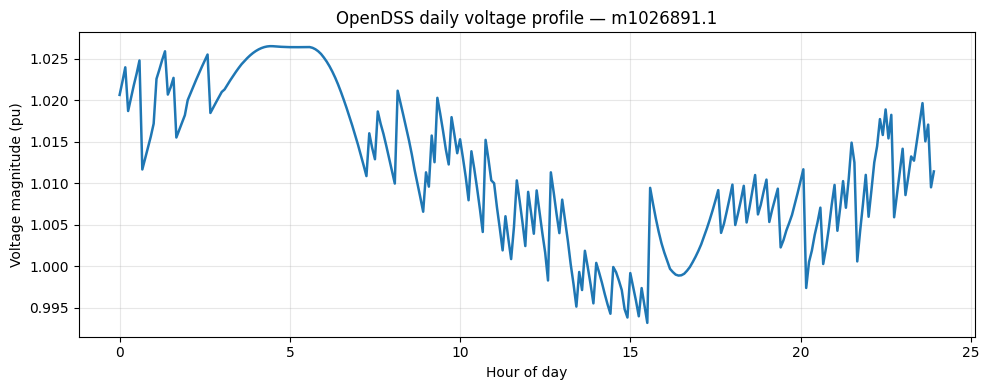

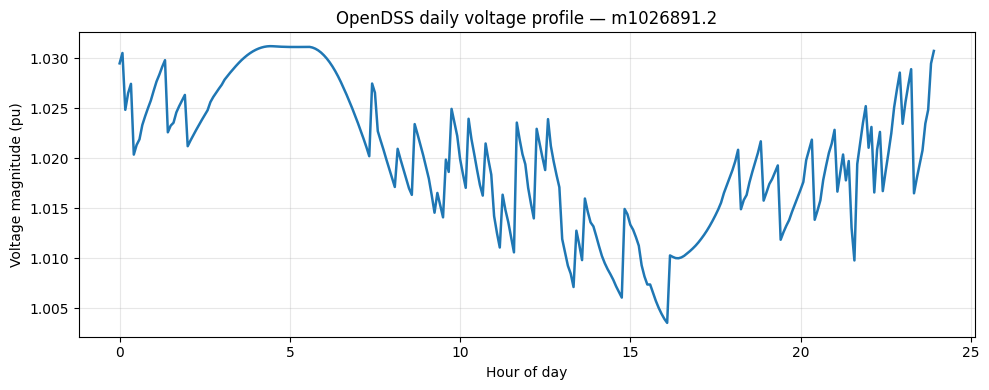

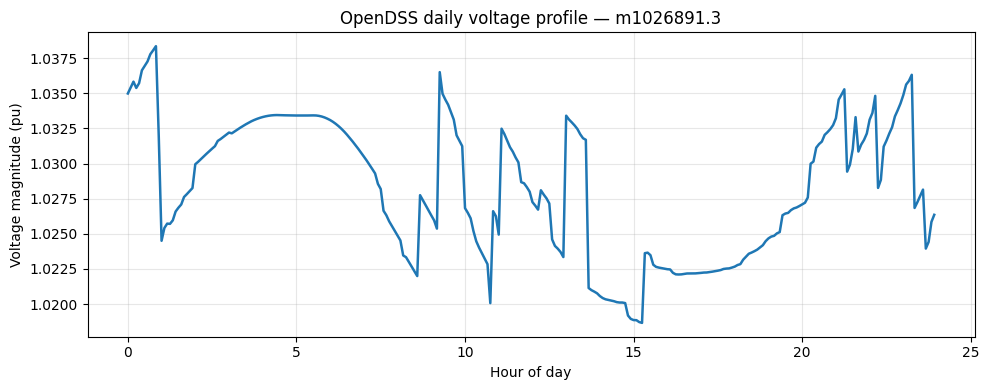

Daily solve done: nonconverged/failed steps=0, max-control-iter warnings=0


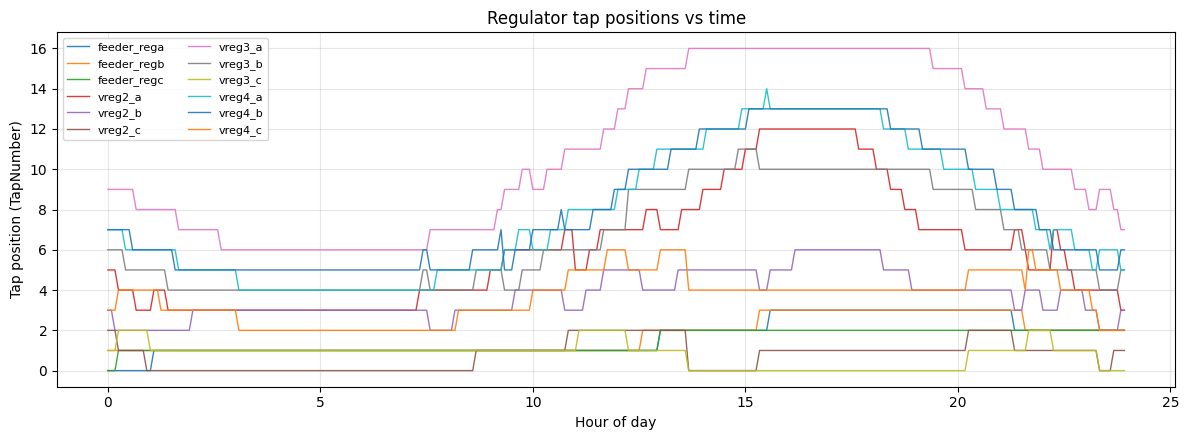

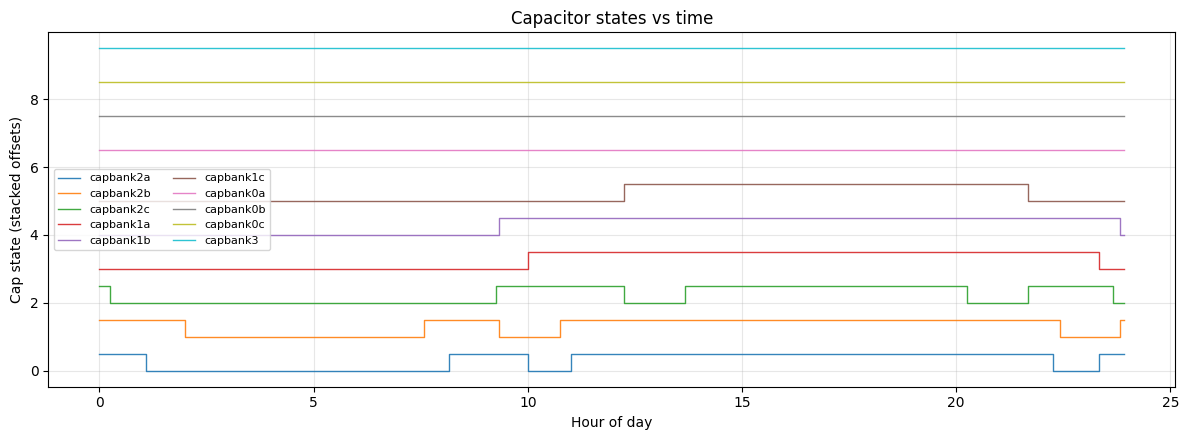


=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===
count: 2456928
min: 0.910080
p01: 0.960014
p05: 0.980945
median: 1.017059
p95: 1.041299
p99: 1.048087
max: 1.062542
mean: 1.014826
std: 0.018810
frac_below_0p95: 0.618%
frac_in_0p95_1p05: 98.904%
frac_above_1p05: 0.478%


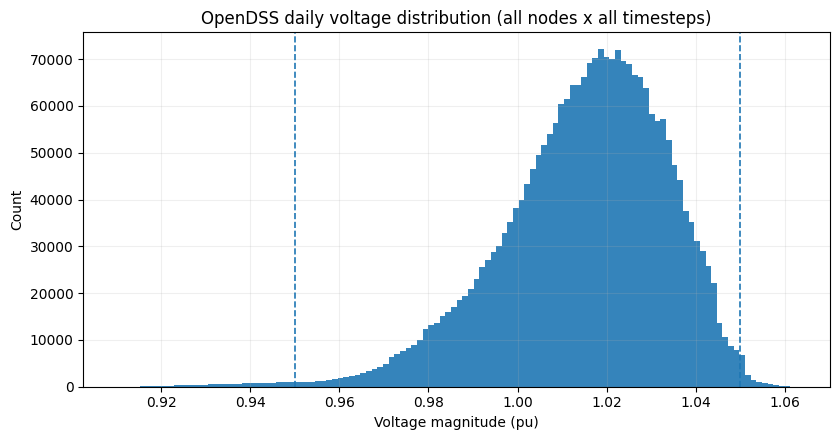


Saved:
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output
 - c:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\opendss_daily_allnode_distribution_timeseries.csv


In [5]:
# Step 9 — OpenDSS-only daily solve (5-minute, 24h) + node plots + all-node voltage distribution
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import opendssdirect as dss
import run_injection_dataset as inj

# --- repo detection (local + Colab) ---
REPO_CANDIDATES = [
    os.getcwd(),
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
]
repo = None
for p in REPO_CANDIDATES:
    if os.path.isfile(os.path.join(p, "8500-node", "Run_8500Node_Daily_5min.dss")):
        repo = p
        break
if repo is None:
    raise FileNotFoundError(f"Could not locate repo root. Tried: {REPO_CANDIDATES}")
os.chdir(repo)
print("Using repo:", os.getcwd())

# --- config ---
NPTS = 288
STEP_MIN = 5
PLOT_NODES = ["m1026891.1", "m1026891.2", "m1026891.3"]  # edit as needed
OUT_DIR = "gnn2_daily_compare_8500_output"
os.makedirs(OUT_DIR, exist_ok=True)

RUN_DSS = os.path.join("8500-node", "Run_8500Node_Daily_5min.dss")
if not os.path.isfile(RUN_DSS):
    raise FileNotFoundError(os.path.abspath(RUN_DSS))

# --- compile/setup DSS daily entrypoint ---
# Use absolute path for robust execution.
dss.Basic.ClearAll()
dss.Text.Command(f'redirect "{os.path.abspath(RUN_DSS)}"')
# Keep daily settings explicit.
dss.Text.Command("set mode=daily")
dss.Text.Command("set stepsize=5m")
dss.Text.Command("set number=1")
# Important for 8500 daily control actions (regulators/cap controls).
dss.Text.Command("set maxiterations=30")
dss.Text.Command("set maxcontroliter=20000")

# Build node list from current compiled circuit (live DSS), not dataset CSV.
all_nodes = []
for n in dss.Circuit.AllNodeNames():
    s = str(n).strip().lower()
    if "." not in s:
        continue
    bus, phs = s.rsplit(".", 1)
    try:
        ph = int(phs)
    except Exception:
        continue
    if ph in (1, 2, 3):
        all_nodes.append(s)

# Preserve DSS order while deduplicating.
all_nodes = list(dict.fromkeys(all_nodes))
if len(all_nodes) == 0:
    raise RuntimeError("No phase nodes (1/2/3) found from dss.Circuit.AllNodeNames().")

node_to_idx = {n: i for i, n in enumerate(all_nodes)}

valid_plot_nodes = [str(n).lower() for n in PLOT_NODES if str(n).lower() in node_to_idx]
if len(valid_plot_nodes) == 0:
    valid_plot_nodes = [n for n in all_nodes if not n.startswith("sourcebus")][:3]
    print("[WARN] Requested nodes not found in live DSS nodes. Falling back to:", valid_plot_nodes)
elif len(valid_plot_nodes) < len(PLOT_NODES):
    missing = [n for n in PLOT_NODES if str(n).lower() not in node_to_idx]
    print("[WARN] Dropping missing nodes:", missing)

# --- run 24h day and collect voltages + control states ---
time_hours = np.arange(NPTS, dtype=np.float32) * (STEP_MIN / 60.0)
V_all = np.full((NPTS, len(all_nodes)), np.nan, dtype=np.float32)

# Track regulator taps and capacitor states over time.
reg_names = [n for n in dss.RegControls.AllNames() if str(n).lower() != "none"]
cap_names = [n for n in dss.Capacitors.AllNames() if str(n).lower() != "none"]

reg_taps = np.full((NPTS, len(reg_names)), np.nan, dtype=np.float32)
cap_states = np.full((NPTS, len(cap_names)), np.nan, dtype=np.float32)

n_nonconv = 0
n_ctrl_warn = 0
for t in range(NPTS):
    hr = int(t // 12)
    sec = int((t % 12) * 300)
    dss.Text.Command(f"set hour={hr} sec={sec}")
    try:
        dss.Solution.Solve()
    except Exception as e:
        # OpenDSS warning 485 can be raised as Python exception by opendssdirect.
        if "Max Control Iterations Exceeded" in str(e):
            n_ctrl_warn += 1
        n_nonconv += 1
        continue
    if not dss.Solution.Converged():
        n_nonconv += 1
        continue

    vmag, _ = inj.get_all_node_voltage_pu_and_angle_filtered(all_nodes)
    V_all[t, :] = np.asarray(vmag, dtype=np.float32)

    # Regulator tap positions
    for j, rn in enumerate(reg_names):
        try:
            dss.RegControls.Name(rn)
            reg_taps[t, j] = float(dss.RegControls.TapNumber())
        except Exception:
            reg_taps[t, j] = np.nan

    # Capacitor states: if multi-step state array exists, use 1 if any step is ON else 0
    for j, cn in enumerate(cap_names):
        try:
            dss.Capacitors.Name(cn)
            st = dss.Capacitors.States()
            if isinstance(st, (list, tuple, np.ndarray)):
                cap_states[t, j] = 1.0 if np.any(np.asarray(st, dtype=float) > 0.5) else 0.0
            else:
                cap_states[t, j] = float(st)
        except Exception:
            cap_states[t, j] = np.nan

    if (t + 1) % 24 == 0:
        print(f"[{t+1}/{NPTS}] daily solve collected", flush=True)

# --- plot selected node profiles ---
for n in valid_plot_nodes:
    i = node_to_idx[n]
    plt.figure(figsize=(10, 4))
    plt.plot(time_hours, V_all[:, i], linewidth=1.8)
    plt.xlabel("Hour of day")
    plt.ylabel("Voltage magnitude (pu)")
    plt.title(f"OpenDSS daily voltage profile — {n}")
    plt.grid(True, alpha=0.3)
    out_png = os.path.join(OUT_DIR, f"opendss_daily_profile_{n.replace('.', '_')}.png")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()

print(f"Daily solve done: nonconverged/failed steps={n_nonconv}, max-control-iter warnings={n_ctrl_warn}")

# --- control traces plots (regulators + capacitors) ---
if len(reg_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, rn in enumerate(reg_names):
        plt.plot(time_hours, reg_taps[:, j], linewidth=1.0, alpha=0.9, label=rn)
    plt.xlabel("Hour of day")
    plt.ylabel("Tap position (TapNumber)")
    plt.title("Regulator tap positions vs time")
    plt.grid(True, alpha=0.3)
    # Too many legend entries can clutter the plot.
    if len(reg_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    reg_png = os.path.join(OUT_DIR, "opendss_daily_regulator_taps.png")
    plt.tight_layout()
    plt.savefig(reg_png, dpi=170)
    plt.show()

if len(cap_names) > 0:
    plt.figure(figsize=(12, 4.5))
    for j, cn in enumerate(cap_names):
        # vertical offset so state traces are distinguishable
        y = cap_states[:, j] * 0.5 + 1.0 * j
        plt.step(time_hours, y, where="post", linewidth=1.0, alpha=0.9, label=cn)
    plt.xlabel("Hour of day")
    plt.ylabel("Cap state (stacked offsets)")
    plt.title("Capacitor states vs time")
    plt.grid(True, alpha=0.3)
    if len(cap_names) <= 12:
        plt.legend(ncol=2, fontsize=8)
    cap_png = os.path.join(OUT_DIR, "opendss_daily_capacitor_states.png")
    plt.tight_layout()
    plt.savefig(cap_png, dpi=170)
    plt.show()

# --- all-node all-day distribution ---
vals = V_all[np.isfinite(V_all)]
if vals.size == 0:
    raise RuntimeError("No converged finite voltages collected for daily run.")

summary = {
    "count": int(vals.size),
    "min": float(np.min(vals)),
    "p01": float(np.percentile(vals, 1)),
    "p05": float(np.percentile(vals, 5)),
    "median": float(np.percentile(vals, 50)),
    "p95": float(np.percentile(vals, 95)),
    "p99": float(np.percentile(vals, 99)),
    "max": float(np.max(vals)),
    "mean": float(np.mean(vals)),
    "std": float(np.std(vals)),
    "frac_below_0p95": float(np.mean(vals < 0.95)),
    "frac_in_0p95_1p05": float(np.mean((vals >= 0.95) & (vals <= 1.05))),
    "frac_above_1p05": float(np.mean(vals > 1.05)),
}

print("\n=== OpenDSS daily voltage distribution (all nodes, all timesteps) ===")
for k, v in summary.items():
    if k.startswith("frac_"):
        print(f"{k}: {100.0*v:.3f}%")
    else:
        print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

# Histogram for all node-phase voltages across full day.
plt.figure(figsize=(8.5, 4.5))
plt.hist(vals, bins=120, alpha=0.9)
plt.axvline(0.95, linestyle="--", linewidth=1.2)
plt.axvline(1.05, linestyle="--", linewidth=1.2)
plt.xlabel("Voltage magnitude (pu)")
plt.ylabel("Count")
plt.title("OpenDSS daily voltage distribution (all nodes x all timesteps)")
plt.grid(True, alpha=0.2)
hist_png = os.path.join(OUT_DIR, "opendss_daily_allnode_voltage_hist.png")
plt.tight_layout()
plt.savefig(hist_png, dpi=170)
plt.show()

# Persist per-step distribution stats as CSV.
df_step = pd.DataFrame({
    "t_index": np.arange(NPTS, dtype=int),
    "hour": time_hours,
    "n_finite": np.sum(np.isfinite(V_all), axis=1),
    "vmin": np.nanmin(V_all, axis=1),
    "vmax": np.nanmax(V_all, axis=1),
    "vmean": np.nanmean(V_all, axis=1),
    "v_p05": np.nanpercentile(V_all, 5, axis=1),
    "v_p50": np.nanpercentile(V_all, 50, axis=1),
    "v_p95": np.nanpercentile(V_all, 95, axis=1),
})
out_csv = os.path.join(OUT_DIR, "opendss_daily_allnode_distribution_timeseries.csv")
df_step.to_csv(out_csv, index=False)
print("\nSaved:")
print(" -", os.path.abspath(OUT_DIR))
print(" -", os.path.abspath(out_csv))

dataset generation

In [13]:
import os, hashlib

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    os.getcwd(),
]

script_path = None
for root in CANDIDATES:
    p = os.path.join(root, "run_daily_aggregate_dataset_8500.py")
    if os.path.isfile(p):
        script_path = os.path.abspath(p)
        break

if script_path is None:
    raise FileNotFoundError("run_daily_aggregate_dataset_8500.py not found in candidates.")

os.chdir(os.path.dirname(script_path))
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

# Verify this is the updated script
txt = open(script_path, encoding="utf-8").read()
print("has_new_diag:", ("top_offenders" in txt and "pct_out" in txt and "n_v_below_safe_band" in txt))
print("md5:", hashlib.md5(txt.encode("utf-8")).hexdigest())

exec(txt, {"__name__": "__main__", "__file__": script_path})

CWD: c:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_daily_aggregate_dataset_8500.py
has_new_diag: True
md5: 8140fa1c268b15f99a8f754d276d9a59
[diag] safe-band eval: 8531/8531 nodes (all phase nodes, no kVBase filter — aligned with notebook Step 9)
[saved] phase-edge CSV -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_edges_phase_static.csv | rows=14238 | cols=17 | bidirectional=True
[diag] electrical_distance_ohm: min=0 max=40.8786 (|Z| sum along min-|Z| path from substation)
[diag] regcontrols=12 capacitors=10
[scenario 1/500] scale=0.788 kept_samples=20 nonconv_this_s=0 badV_this_s=0 v_outside_band_this_s=0 (below=0, above=0, pct=0.00%) N_nodes=8531 top_offenders=[none] skip_nonconv_total=0 skip_badV_total=0
[scenario 2/500] scale=1.241 kept_samples=40 nonconv_this_s=0 badV_this_s=0 v_outside_band_this_s=84 (below=84, above=0, pct=0.05%) N_nodes=8531 top_offenders=[sx2767342a.1:3, sx2767342a.2:3, sx2748780a.1:3, s

In [4]:
import os
import pandas as pd

base = r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg"

sample_csv = os.path.join(base, "gnn_sample_meta.csv")
node_csv   = os.path.join(base, "gnn_node_features_and_targets.csv")
edge_csv   = os.path.join(base, "gnn_edges_phase_static.csv")

print("=== sample meta (first 20 rows) ===")
df_s = pd.read_csv(sample_csv, nrows=0)
print(df_s)

print("\n=== node features/targets (first 20 rows) ===")
df_n = pd.read_csv(node_csv, nrows=100)
print(df_n)

print("\n=== edges (first 20 rows) ===")
df_e = pd.read_csv(edge_csv, nrows=0)
print(df_e)

=== sample meta (first 20 rows) ===
Empty DataFrame
Columns: [sample_id, scenario_id, t_index, t_minutes, scenario_total_load_scale, m_loadshape, effective_total_scale, P_load_sum_post_kw, Q_load_sum_post_kvar, P_loss_total_post_kw, Q_loss_total_post_kvar, P_grid_upstream_post_kw, Q_grid_upstream_post_kvar, sigma_device, safe_vmin_pu, safe_vmax_pu, n_v_outside_safe_band, n_v_below_safe_band, n_v_above_safe_band, reg_feeder_rega_tap_pu, reg_feeder_regb_tap_pu, reg_feeder_regc_tap_pu, reg_vreg2_a_tap_pu, reg_vreg2_b_tap_pu, reg_vreg2_c_tap_pu, reg_vreg3_a_tap_pu, reg_vreg3_b_tap_pu, reg_vreg3_c_tap_pu, reg_vreg4_a_tap_pu, reg_vreg4_b_tap_pu, reg_vreg4_c_tap_pu, cap_capbank0a_n_steps_on, cap_capbank0a_q_nominal_kvar, cap_capbank0a_q_post_kvar, cap_capbank0b_n_steps_on, cap_capbank0b_q_nominal_kvar, cap_capbank0b_q_post_kvar, cap_capbank0c_n_steps_on, cap_capbank0c_q_nominal_kvar, cap_capbank0c_q_post_kvar, cap_capbank1a_n_steps_on, cap_capbank1a_q_nominal_kvar, cap_capbank1a_q_post_kvar, 

### 8500 device-state MLP architecture search

Trains five **non-graph** MLPs on the flattened nodal vector (**p_load_kw**, **q_load_kvar** for every node) to predict **22** device-state targets in `gnn_sample_meta.csv`. No edge or static graph features are used. Checkpoints (`best.pt`) and `summary.json` are written to `gnn2_architecture_search/`. The first run streams the large node CSV once; `--node-cache` saves a tensor `.pt` for faster reruns.

**Colab:** Run your **setup cell** first (clone to `/content/GNN-Sandia` and `chdir` there), or ensure the cwd is the repo root so `train_8500_device_state_arch_search.py` is visible. The training cell also checks `/content/GNN-Sandia` and `/content/GNN2`. Optional: `os.environ["GNN_REPO"] = "/content/GNN-Sandia"`.

Then add `datasets_gnn2/loadtype_8500_dailyagg/` (upload or Google Drive).

In [ ]:
import os
import subprocess
import sys
from pathlib import Path


def _detect_repo_root() -> Path:
    """Return a directory that contains train_8500_device_state_arch_search.py (never a non-existent path)."""
    marker = "train_8500_device_state_arch_search.py"

    def _has_script(p: Path) -> bool:
        return (p / marker).is_file()

    env = (os.environ.get("GNN2_REPO") or os.environ.get("GNN_REPO") or "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if _has_script(p):
            return p
        raise FileNotFoundError(
            f"GNN2_REPO/GNN_REPO={env!r} but {marker} not found there. Fix the path or unset the env var."
        )

    # If the notebook cwd is already the repo (e.g. after os.chdir("/content/GNN-Sandia")), use it.
    cwd = Path.cwd().resolve()
    if _has_script(cwd):
        return cwd

    try:
        import google.colab  # noqa: F401

        _colab = True
    except ImportError:
        _colab = False

    if _colab:
        # Match common Colab clone targets (setup cell often uses /content/GNN-Sandia)
        for p in (
            Path("/content/GNN-Sandia"),
            Path("/content/GNN2"),
            Path("/content/drive/MyDrive/GNN-Sandia"),
            Path("/content/drive/MyDrive/GNN2"),
            Path("/content/drive/MyDrive/Desktop/GNN2"),
        ):
            if _has_script(p):
                return p.resolve()

    win = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
    if _has_script(win):
        return win.resolve()

    raise FileNotFoundError(
        "Cannot find the repo (missing train_8500_device_state_arch_search.py).\n"
        "On Colab run your setup cell first (clone + chdir), e.g.:\n"
        "  !git clone https://github.com/alitasavori/GNN-Sandia.git /content/GNN-Sandia\n"
        "  %cd /content/GNN-Sandia\n"
        "Or set: os.environ['GNN_REPO'] = '/content/GNN-Sandia'"
    )


repo = str(_detect_repo_root())
os.chdir(repo)
outd = os.path.join(repo, "gnn2_architecture_search")
cache = os.path.join(outd, "node_features_X.pt")
os.makedirs(outd, exist_ok=True)

cmd = [
    sys.executable,
    "-u",
    "train_8500_device_state_arch_search.py",
    "--repo-root",
    repo,
    "--epochs",
    "100",
    "--out-dir",
    outd,
    "--node-cache",
    cache,
    "--log-every",
    "10",
]
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
print("Starting (streaming logs):", " ".join(cmd), flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_8500_device_state_arch_search.py exited with code {ret}")

### 8500 device-state: 22 targets x 3 MLP architectures (softmax)

This trains **3 different MLP architectures per target** for all **22 targets** (**66 total training runs**). Each target is still an independent softmax classifier (discrete tap/step classes), but only the **best architecture per target** is saved as `best.pt`. All run metrics are reported and written to `summary.json` under `gnn2_architecture_search_softmax_22/`.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path


def _detect_repo_root() -> Path:
    marker = "train_8500_device_state_softmax_22models.py"

    def _has_script(p: Path) -> bool:
        return (p / marker).is_file()

    env = (os.environ.get("GNN_REPO") or os.environ.get("GNN2_REPO") or "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if _has_script(p):
            return p
        raise FileNotFoundError(f"Repo env points to {p}, but {marker} not found there.")

    cwd = Path.cwd().resolve()
    if _has_script(cwd):
        return cwd

    for p in (
        Path("/content/GNN-Sandia"),
        Path("/content/GNN2"),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
    ):
        if _has_script(p):
            return p.resolve()

    raise FileNotFoundError(
        "Could not find train_8500_device_state_softmax_22models.py.\n"
        "Clone/open the repo root first."
    )


repo = str(_detect_repo_root())
os.chdir(repo)
outd = os.path.join(repo, "gnn2_architecture_search_softmax_22")
cache = os.path.join(outd, "node_features_X.pt")
os.makedirs(outd, exist_ok=True)

cmd = [
    sys.executable,
    "-u",
    "train_8500_device_state_softmax_22models.py",
    "--repo-root",
    repo,
    "--epochs",
    "100",
    "--out-dir",
    outd,
    "--node-cache",
    cache,
    "--log-every",
    "10",
]
_env = {**os.environ, "PYTHONUNBUFFERED": "1"}
print("Starting (streaming logs):", " ".join(cmd), flush=True)

proc = subprocess.Popen(
    cmd,
    cwd=os.getcwd(),
    env=_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding="utf-8",
    errors="replace",
    bufsize=1,
)
assert proc.stdout is not None
for line in proc.stdout:
    print(line, end="", flush=True)
ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"train_8500_device_state_softmax_22models.py exited with code {ret}")

Starting (streaming logs): /usr/bin/python3 -u train_8500_device_state_softmax_22models.py --repo-root /content/GNN-Sandia --epochs 100 --out-dir /content/GNN-Sandia/gnn2_architecture_search_softmax_22 --node-cache /content/GNN-Sandia/gnn2_architecture_search_softmax_22/node_features_X.pt --log-every 10
[8500 softmax-22] repo_root=/content/GNN-Sandia
[8500 softmax-22] dataset_dir=/content/GNN-Sandia/datasets_gnn2/loadtype_8500_dailyagg
  inferring N_nodes from gnn_node_features_and_targets.csv...
  loading node tensor from cache /content/GNN-Sandia/gnn2_architecture_search_softmax_22/node_features_X.pt
  samples=9770 n_nodes=8531 flat_dim=17062 targets=22
  split train=6839 val=1465 test=1466
  device=cuda log_every=10
  architecture_search=enabled (3 architectures/target)

--- Training target 1/22: reg_feeder_rega_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.785128  train_acc=0.3103  val_ce=2.093726  val_acc=0.4451  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.311132  train_acc=0.4698  val_ce=1.520507  val_acc=0.4314  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.201159  train_acc=0.5233  val_ce=1.180545  val_acc=0.5283  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.179941  train_acc=0.5299  val_ce=1.395881  val_acc=0.5058  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.143537  train_acc=0.5337  val_ce=1.248413  val_acc=0.5010  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.068557  train_acc=0.5540  val_ce=1.197619  val_acc=0.5468  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.026291  train_acc=0.5646  val_ce=1.265716  val_acc=0.5911  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.025558  train_acc=0.5670  val_ce=1.313340  val_acc=0.5857  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=1.010194  train_acc=0.5700  val_ce=1.321608  val_acc=0.5857  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.996759  train_acc=0.5768  val_ce=1.312797  val_acc=0.5850  lr=1.56e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.003836  train_acc=0.5748  val_ce=1.305724  val_acc=0.5836  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.960953  train_acc=0.3006  val_ce=1.932253  val_acc=0.5311  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.184163  train_acc=0.4888  val_ce=1.121602  val_acc=0.5017  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.141700  train_acc=0.5284  val_ce=1.218022  val_acc=0.4997  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.123540  train_acc=0.5384  val_ce=1.189193  val_acc=0.5406  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.066635  train_acc=0.5510  val_ce=1.049067  val_acc=0.5433  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.121683  train_acc=0.5499  val_ce=1.016442  val_acc=0.5570  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.045906  train_acc=0.5681  val_ce=1.039007  val_acc=0.5775  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.972322  train_acc=0.5706  val_ce=1.014052  val_acc=0.5809  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.976394  train_acc=0.5682  val_ce=1.127213  val_acc=0.5809  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.948580  train_acc=0.5694  val_ce=1.033746  val_acc=0.5863  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.953587  train_acc=0.5793  val_ce=1.081262  val_acc=0.5836  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.204298  train_acc=0.1019  val_ce=2.390252  val_acc=0.3072  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.321440  train_acc=0.4607  val_ce=1.332625  val_acc=0.4901  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.237681  train_acc=0.4651  val_ce=1.360731  val_acc=0.4792  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.206019  train_acc=0.4862  val_ce=1.175159  val_acc=0.4976  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.273325  train_acc=0.4837  val_ce=1.186417  val_acc=0.4696  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.136436  train_acc=0.4979  val_ce=1.240652  val_acc=0.5256  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.046295  train_acc=0.5112  val_ce=1.185225  val_acc=0.5242  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.069537  train_acc=0.5194  val_ce=1.199074  val_acc=0.5358  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.023499  train_acc=0.5153  val_ce=1.150149  val_acc=0.5229  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.028631  train_acc=0.5201  val_ce=1.169092  val_acc=0.5317  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.076475  train_acc=0.5181  val_ce=1.159809  val_acc=0.5331  lr=1.56e-05
  done reg_feeder_rega_tap_pu: best_arch=a2_mid_deep val_ce=0.960882  val_acc=0.5502 n_classes=10

--- Training target 2/22: reg_feeder_regb_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=3.443107  train_acc=0.2335  val_ce=2.593592  val_acc=0.3174  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.442946  train_acc=0.4751  val_ce=1.522068  val_acc=0.4130  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.475067  train_acc=0.4982  val_ce=1.420610  val_acc=0.4567  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.106600  train_acc=0.5391  val_ce=1.148813  val_acc=0.5515  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=1.118390  train_acc=0.5495  val_ce=1.158905  val_acc=0.5352  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.096515  train_acc=0.5463  val_ce=1.045493  val_acc=0.5577  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.097504  train_acc=0.5445  val_ce=1.069627  val_acc=0.5686  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.015036  train_acc=0.5672  val_ce=1.041160  val_acc=0.5543  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.034784  train_acc=0.5548  val_ce=1.046675  val_acc=0.5488  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.024875  train_acc=0.5629  val_ce=1.067027  val_acc=0.5645  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.979793  train_acc=0.5589  val_ce=1.082639  val_acc=0.5563  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.290009  train_acc=0.2521  val_ce=2.220945  val_acc=0.3823  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.508930  train_acc=0.4524  val_ce=1.526969  val_acc=0.4642  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.305545  train_acc=0.5125  val_ce=1.269828  val_acc=0.5242  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.357094  train_acc=0.5059  val_ce=1.143978  val_acc=0.4491  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.295037  train_acc=0.5093  val_ce=1.187982  val_acc=0.4976  lr=1.00e-03
    [a2_mid_deep] epoch   50/100  train_ce=1.314754  train_acc=0.5203  val_ce=1.291568  val_acc=0.4744  lr=1.00e-03
    [a2_mid_deep] epoch   60/100  train_ce=1.184360  train_acc=0.5334  val_ce=1.084545  val_acc=0.5167  lr=1.00e-03
    [a2_mid_deep] epoch   70/100  train_ce=1.302275  train_acc=0.5350  val_ce=1.025362  val_acc=0.5188  lr=1.00e-03
    [a2_mid_deep] epoch   80/100  train_ce=1.000850  train_acc=0.5495  val_ce=0.911330  val_acc=0.5283  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=0.990973  train_acc=0.5523  val_ce=1.098895  val_acc=0.5563  lr=5.00e-04
    [a2_mid_deep] epoch  100/100  train_ce=0.964533  train_acc=0.5572  val_ce=0.881883  val_acc=0.5372  lr=2.50e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.517990  train_acc=0.0512  val_ce=2.559258  val_acc=0.1003  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.540433  train_acc=0.3698  val_ce=1.451906  val_acc=0.3672  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.392646  train_acc=0.3821  val_ce=1.253878  val_acc=0.3877  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.357510  train_acc=0.3967  val_ce=1.235270  val_acc=0.4075  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.256715  train_acc=0.4062  val_ce=1.109031  val_acc=0.4109  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.215762  train_acc=0.4068  val_ce=1.054626  val_acc=0.3898  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.193072  train_acc=0.4201  val_ce=1.032079  val_acc=0.4061  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.138338  train_acc=0.4274  val_ce=1.082019  val_acc=0.4485  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.055890  train_acc=0.4325  val_ce=1.020669  val_acc=0.4594  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.096085  train_acc=0.4362  val_ce=0.959708  val_acc=0.4635  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.114437  train_acc=0.4388  val_ce=0.949575  val_acc=0.4478  lr=3.13e-05
  done reg_feeder_regb_tap_pu: best_arch=a2_mid_deep val_ce=0.853694  val_acc=0.5509 n_classes=12

--- Training target 3/22: reg_feeder_regc_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.980528  train_acc=0.3325  val_ce=2.109731  val_acc=0.5010  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.820866  train_acc=0.5667  val_ce=0.765428  val_acc=0.5761  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.828353  train_acc=0.5666  val_ce=0.775789  val_acc=0.6137  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.704356  train_acc=0.5872  val_ce=0.604688  val_acc=0.6498  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.683436  train_acc=0.5852  val_ce=0.854221  val_acc=0.6553  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.645240  train_acc=0.5916  val_ce=0.616979  val_acc=0.6294  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.649375  train_acc=0.5928  val_ce=0.583700  val_acc=0.6164  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.638907  train_acc=0.5994  val_ce=0.581280  val_acc=0.6410  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.633085  train_acc=0.6049  val_ce=0.546892  val_acc=0.6410  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.637447  train_acc=0.6113  val_ce=0.533528  val_acc=0.6389  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.616834  train_acc=0.6075  val_ce=0.498729  val_acc=0.6266  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.376888  train_acc=0.3705  val_ce=1.203657  val_acc=0.3870  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.882876  train_acc=0.5648  val_ce=0.890855  val_acc=0.5891  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.745848  train_acc=0.5726  val_ce=0.999508  val_acc=0.6491  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.670154  train_acc=0.5906  val_ce=0.600318  val_acc=0.6246  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.674820  train_acc=0.5903  val_ce=0.606627  val_acc=0.6457  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.610172  train_acc=0.6070  val_ce=0.520240  val_acc=0.6396  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.610058  train_acc=0.5970  val_ce=0.500874  val_acc=0.6300  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.618407  train_acc=0.6083  val_ce=0.493887  val_acc=0.6396  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.609285  train_acc=0.6036  val_ce=0.493371  val_acc=0.6280  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.615898  train_acc=0.6055  val_ce=0.491645  val_acc=0.6341  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.590565  train_acc=0.6049  val_ce=0.497643  val_acc=0.6348  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.480873  train_acc=0.3189  val_ce=1.178436  val_acc=0.4744  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.902165  train_acc=0.5024  val_ce=0.847397  val_acc=0.6430  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.784326  train_acc=0.5590  val_ce=0.631226  val_acc=0.6628  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.733360  train_acc=0.5809  val_ce=0.592219  val_acc=0.6355  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.713048  train_acc=0.5803  val_ce=0.544397  val_acc=0.6382  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.758696  train_acc=0.5767  val_ce=0.591380  val_acc=0.6437  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.660032  train_acc=0.5770  val_ce=0.522912  val_acc=0.6382  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.681346  train_acc=0.5874  val_ce=0.521724  val_acc=0.6423  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.625090  train_acc=0.5913  val_ce=0.543611  val_acc=0.6396  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.636787  train_acc=0.5903  val_ce=0.505213  val_acc=0.6341  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.674618  train_acc=0.5975  val_ce=0.506462  val_acc=0.6444  lr=6.25e-05
  done reg_feeder_regc_tap_pu: best_arch=a2_mid_deep val_ce=0.491271  val_acc=0.6334 n_classes=6

--- Training target 4/22: reg_vreg2_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.852436  train_acc=0.1512  val_ce=2.364968  val_acc=0.2102  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.981566  train_acc=0.2614  val_ce=1.856023  val_acc=0.2635  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.920550  train_acc=0.2870  val_ce=1.874677  val_acc=0.2430  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.892291  train_acc=0.2797  val_ce=1.849393  val_acc=0.2785  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.901371  train_acc=0.2812  val_ce=1.897536  val_acc=0.2737  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.834037  train_acc=0.3125  val_ce=1.797937  val_acc=0.2935  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.819876  train_acc=0.3106  val_ce=1.768523  val_acc=0.3208  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.789409  train_acc=0.3258  val_ce=1.759392  val_acc=0.3195  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.788949  train_acc=0.3258  val_ce=1.762972  val_acc=0.3256  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.773418  train_acc=0.3204  val_ce=1.758553  val_acc=0.3092  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.767813  train_acc=0.3202  val_ce=1.758884  val_acc=0.3167  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.612315  train_acc=0.1165  val_ce=2.117136  val_acc=0.2294  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.956978  train_acc=0.2540  val_ce=1.834561  val_acc=0.2587  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.912346  train_acc=0.2628  val_ce=1.914074  val_acc=0.3003  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.883249  train_acc=0.2867  val_ce=1.804562  val_acc=0.3290  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.859324  train_acc=0.2913  val_ce=1.823919  val_acc=0.3474  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.839336  train_acc=0.2916  val_ce=1.792415  val_acc=0.3392  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.818499  train_acc=0.2954  val_ce=1.864542  val_acc=0.3345  lr=5.00e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.809168  train_acc=0.3022  val_ce=1.756115  val_acc=0.3078  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.802874  train_acc=0.3101  val_ce=1.751330  val_acc=0.3352  lr=2.50e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.782457  train_acc=0.3131  val_ce=1.746677  val_acc=0.3229  lr=1.25e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.771743  train_acc=0.3142  val_ce=1.741425  val_acc=0.3160  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.717541  train_acc=0.0659  val_ce=2.355420  val_acc=0.0710  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=2.005182  train_acc=0.2451  val_ce=1.871374  val_acc=0.3188  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.979275  train_acc=0.2462  val_ce=1.907893  val_acc=0.3072  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.949745  train_acc=0.2824  val_ce=1.859057  val_acc=0.3058  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.916957  train_acc=0.2739  val_ce=1.903024  val_acc=0.3147  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.868669  train_acc=0.2882  val_ce=1.779077  val_acc=0.3038  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.832366  train_acc=0.2935  val_ce=1.754323  val_acc=0.2942  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.841344  train_acc=0.2898  val_ce=1.756016  val_acc=0.2935  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.807249  train_acc=0.2965  val_ce=1.763495  val_acc=0.2956  lr=1.25e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.800530  train_acc=0.3062  val_ce=1.740816  val_acc=0.3201  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.805238  train_acc=0.3119  val_ce=1.738047  val_acc=0.3263  lr=6.25e-05
  done reg_vreg2_a_tap_pu: best_arch=a2_mid_deep val_ce=1.736592  val_acc=0.2990 n_classes=18

--- Training target 5/22: reg_vreg2_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=4.328225  train_acc=0.1538  val_ce=2.794092  val_acc=0.1413  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=2.065607  train_acc=0.2524  val_ce=1.988864  val_acc=0.2799  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=2.018243  train_acc=0.2701  val_ce=2.151392  val_acc=0.2751  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.858376  train_acc=0.3078  val_ce=2.098429  val_acc=0.3638  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.832572  train_acc=0.3081  val_ce=1.897879  val_acc=0.3420  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.819361  train_acc=0.3239  val_ce=1.742139  val_acc=0.3399  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.812760  train_acc=0.3227  val_ce=3.401402  val_acc=0.3358  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.776114  train_acc=0.3210  val_ce=1.750331  val_acc=0.3338  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.679872  train_acc=0.3438  val_ce=1.733603  val_acc=0.3263  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.689068  train_acc=0.3414  val_ce=1.717854  val_acc=0.3208  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.656735  train_acc=0.3370  val_ce=1.694439  val_acc=0.3283  lr=1.25e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=3.038969  train_acc=0.1233  val_ce=2.518837  val_acc=0.0792  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=2.015205  train_acc=0.2405  val_ce=1.848197  val_acc=0.3017  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.904347  train_acc=0.2929  val_ce=1.903603  val_acc=0.3072  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.944949  train_acc=0.2777  val_ce=1.824089  val_acc=0.2491  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.809118  train_acc=0.3214  val_ce=1.884050  val_acc=0.3795  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.800476  train_acc=0.3265  val_ce=1.712627  val_acc=0.3413  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.849888  train_acc=0.3017  val_ce=2.048462  val_acc=0.3345  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.712145  train_acc=0.3265  val_ce=1.684630  val_acc=0.3427  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.638941  train_acc=0.3384  val_ce=1.648122  val_acc=0.3276  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.626677  train_acc=0.3308  val_ce=1.704317  val_acc=0.3201  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.579011  train_acc=0.3373  val_ce=1.685961  val_acc=0.3188  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.958426  train_acc=0.0322  val_ce=2.836592  val_acc=0.0096  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=2.138258  train_acc=0.1449  val_ce=1.970567  val_acc=0.3092  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=2.096134  train_acc=0.1986  val_ce=1.833573  val_acc=0.2007  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=2.087389  train_acc=0.2212  val_ce=2.413283  val_acc=0.2805  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.909990  train_acc=0.2821  val_ce=1.889753  val_acc=0.3208  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.802581  train_acc=0.2933  val_ce=1.847383  val_acc=0.3154  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.753046  train_acc=0.3094  val_ce=1.798178  val_acc=0.3024  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.692842  train_acc=0.3153  val_ce=1.800004  val_acc=0.3010  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.668507  train_acc=0.3258  val_ce=1.828870  val_acc=0.2997  lr=3.13e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.650897  train_acc=0.3274  val_ce=1.787772  val_acc=0.3003  lr=1.56e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.647728  train_acc=0.3262  val_ce=1.817200  val_acc=0.2962  lr=7.81e-06
  done reg_vreg2_b_tap_pu: best_arch=a2_mid_deep val_ce=1.592399  val_acc=0.3379 n_classes=18

--- Training target 6/22: reg_vreg2_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.777652  train_acc=0.2250  val_ce=3.106838  val_acc=0.1904  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.464234  train_acc=0.2445  val_ce=1.473196  val_acc=0.3147  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.462029  train_acc=0.2487  val_ce=1.491361  val_acc=0.2758  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.424047  train_acc=0.2597  val_ce=1.418414  val_acc=0.2751  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=1.428276  train_acc=0.2590  val_ce=1.428547  val_acc=0.2826  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.412674  train_acc=0.2610  val_ce=1.403563  val_acc=0.2683  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.395153  train_acc=0.2688  val_ce=1.422559  val_acc=0.2703  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.388895  train_acc=0.2740  val_ce=1.399531  val_acc=0.2724  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.396520  train_acc=0.2707  val_ce=1.392459  val_acc=0.2785  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.407835  train_acc=0.2766  val_ce=1.400029  val_acc=0.2710  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.387826  train_acc=0.2742  val_ce=1.393122  val_acc=0.2751  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.754166  train_acc=0.2731  val_ce=2.134874  val_acc=0.2983  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.468629  train_acc=0.2483  val_ce=1.454470  val_acc=0.3065  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.455575  train_acc=0.2530  val_ce=1.444639  val_acc=0.2239  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.441613  train_acc=0.2534  val_ce=1.481925  val_acc=0.2771  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.436074  train_acc=0.2502  val_ce=1.426451  val_acc=0.2744  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.429147  train_acc=0.2591  val_ce=1.443108  val_acc=0.2614  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.423044  train_acc=0.2524  val_ce=1.419561  val_acc=0.2635  lr=5.00e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.421580  train_acc=0.2509  val_ce=1.400641  val_acc=0.2915  lr=5.00e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.403336  train_acc=0.2695  val_ce=1.403081  val_acc=0.2696  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.399050  train_acc=0.2647  val_ce=1.394228  val_acc=0.2717  lr=2.50e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.405502  train_acc=0.2607  val_ce=1.391502  val_acc=0.2621  lr=1.25e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.663707  train_acc=0.2797  val_ce=1.623673  val_acc=0.1904  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.581272  train_acc=0.3410  val_ce=1.607340  val_acc=0.4696  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.581187  train_acc=0.3147  val_ce=1.609540  val_acc=0.2983  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=1.577290  train_acc=0.2990  val_ce=1.611001  val_acc=0.2983  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.576415  train_acc=0.3019  val_ce=1.611650  val_acc=0.2983  lr=6.25e-05
    [a3_narrow_deeper] epoch   50/100  train_ce=1.577647  train_acc=0.2968  val_ce=1.611821  val_acc=0.2983  lr=3.13e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=1.577043  train_acc=0.2940  val_ce=1.611887  val_acc=0.2983  lr=1.56e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=1.578586  train_acc=0.2838  val_ce=1.611891  val_acc=0.2983  lr=7.81e-06
    [a3_narrow_deeper] epoch   80/100  train_ce=1.576291  train_acc=0.2927  val_ce=1.611878  val_acc=0.2983  lr=3.91e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=1.579352  train_acc=0.2958  val_ce=1.611892  val_acc=0.2983  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=1.576220  train_acc=0.2987  val_ce=1.611899  val_acc=0.2983  lr=9.77e-07
  done reg_vreg2_c_tap_pu: best_arch=a2_mid_deep val_ce=1.385897  val_acc=0.2710 n_classes=5

--- Training target 7/22: reg_vreg3_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.574374  train_acc=0.1664  val_ce=2.172363  val_acc=0.1911  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.899372  train_acc=0.3370  val_ce=1.824104  val_acc=0.3440  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.856317  train_acc=0.3410  val_ce=1.807177  val_acc=0.3167  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.825598  train_acc=0.3460  val_ce=1.774283  val_acc=0.3242  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.791594  train_acc=0.3501  val_ce=1.765075  val_acc=0.3392  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.798600  train_acc=0.3498  val_ce=1.740756  val_acc=0.3638  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=1.784759  train_acc=0.3603  val_ce=1.744254  val_acc=0.3413  lr=1.00e-03
    [a1_wide_shallow] epoch   70/100  train_ce=1.753953  train_acc=0.3734  val_ce=1.702266  val_acc=0.3782  lr=5.00e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.744749  train_acc=0.3752  val_ce=1.699131  val_acc=0.3754  lr=5.00e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.737066  train_acc=0.3777  val_ce=1.710622  val_acc=0.3543  lr=5.00e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.724701  train_acc=0.3772  val_ce=1.694401  val_acc=0.3741  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.466337  train_acc=0.1642  val_ce=2.170825  val_acc=0.2075  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.865512  train_acc=0.3354  val_ce=1.814839  val_acc=0.3167  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.835076  train_acc=0.3451  val_ce=1.776143  val_acc=0.3352  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.808699  train_acc=0.3521  val_ce=1.762006  val_acc=0.3427  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.766147  train_acc=0.3653  val_ce=1.712380  val_acc=0.3761  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.742301  train_acc=0.3638  val_ce=1.707394  val_acc=0.3618  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.723627  train_acc=0.3724  val_ce=1.682473  val_acc=0.3768  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.731774  train_acc=0.3752  val_ce=1.684098  val_acc=0.3788  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.720492  train_acc=0.3724  val_ce=1.676726  val_acc=0.3863  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.706972  train_acc=0.3793  val_ce=1.673526  val_acc=0.3836  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.711832  train_acc=0.3812  val_ce=1.674866  val_acc=0.3816  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.757239  train_acc=0.1041  val_ce=2.324218  val_acc=0.1809  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.921853  train_acc=0.3245  val_ce=1.924404  val_acc=0.2491  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.893942  train_acc=0.3405  val_ce=1.792617  val_acc=0.3891  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.854199  train_acc=0.3455  val_ce=1.777295  val_acc=0.3741  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.839376  train_acc=0.3460  val_ce=1.809518  val_acc=0.3311  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.786310  train_acc=0.3609  val_ce=1.762571  val_acc=0.3406  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.789836  train_acc=0.3582  val_ce=1.756662  val_acc=0.3392  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.778604  train_acc=0.3616  val_ce=1.767275  val_acc=0.3365  lr=5.00e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.757695  train_acc=0.3692  val_ce=1.704322  val_acc=0.3741  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.763279  train_acc=0.3692  val_ce=1.711228  val_acc=0.3440  lr=2.50e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.744833  train_acc=0.3707  val_ce=1.695452  val_acc=0.3720  lr=1.25e-04
  done reg_vreg3_a_tap_pu: best_arch=a2_mid_deep val_ce=1.671616  val_acc=0.3857 n_classes=20

--- Training target 8/22: reg_vreg3_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.796199  train_acc=0.1149  val_ce=2.112484  val_acc=0.1761  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.743457  train_acc=0.2897  val_ce=1.725847  val_acc=0.2464  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.700063  train_acc=0.3139  val_ce=1.623089  val_acc=0.3379  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.694252  train_acc=0.3135  val_ce=1.589508  val_acc=0.3631  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.644048  train_acc=0.3223  val_ce=1.674642  val_acc=0.3072  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.578174  train_acc=0.3482  val_ce=1.570648  val_acc=0.3399  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.554313  train_acc=0.3490  val_ce=1.554994  val_acc=0.3700  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.513484  train_acc=0.3620  val_ce=1.508873  val_acc=0.3706  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.495303  train_acc=0.3578  val_ce=1.501007  val_acc=0.3679  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.499659  train_acc=0.3560  val_ce=1.503325  val_acc=0.3693  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.486734  train_acc=0.3653  val_ce=1.495040  val_acc=0.3631  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.525344  train_acc=0.1138  val_ce=2.057831  val_acc=0.2000  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.705156  train_acc=0.2916  val_ce=1.593271  val_acc=0.3666  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.613738  train_acc=0.3031  val_ce=1.589949  val_acc=0.3672  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=1.604429  train_acc=0.3132  val_ce=1.566949  val_acc=0.3577  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.550666  train_acc=0.3367  val_ce=1.519475  val_acc=0.3631  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.541339  train_acc=0.3335  val_ce=1.508626  val_acc=0.3631  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.511429  train_acc=0.3403  val_ce=1.493335  val_acc=0.3659  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.507287  train_acc=0.3378  val_ce=1.492561  val_acc=0.3570  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=1.492154  train_acc=0.3506  val_ce=1.492733  val_acc=0.3549  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.491310  train_acc=0.3451  val_ce=1.492979  val_acc=0.3522  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.487372  train_acc=0.3471  val_ce=1.488984  val_acc=0.3543  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.688257  train_acc=0.0727  val_ce=2.223783  val_acc=0.2075  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.807731  train_acc=0.2609  val_ce=1.693534  val_acc=0.3365  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.694475  train_acc=0.2940  val_ce=1.654808  val_acc=0.3311  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=1.651094  train_acc=0.2980  val_ce=1.579184  val_acc=0.3311  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.611122  train_acc=0.3068  val_ce=1.568226  val_acc=0.3536  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.622584  train_acc=0.3072  val_ce=1.568488  val_acc=0.3433  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.564279  train_acc=0.3305  val_ce=1.511087  val_acc=0.3570  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.567847  train_acc=0.3256  val_ce=1.512148  val_acc=0.3488  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.547154  train_acc=0.3372  val_ce=1.506800  val_acc=0.3522  lr=1.25e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.541315  train_acc=0.3359  val_ce=1.502553  val_acc=0.3495  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.532730  train_acc=0.3340  val_ce=1.505401  val_acc=0.3495  lr=6.25e-05
  done reg_vreg3_b_tap_pu: best_arch=a2_mid_deep val_ce=1.488059  val_acc=0.3556 n_classes=20

--- Training target 9/22: reg_vreg3_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.951935  train_acc=0.2785  val_ce=1.540195  val_acc=0.3652  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.358691  train_acc=0.3957  val_ce=1.305276  val_acc=0.3208  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.322436  train_acc=0.4056  val_ce=1.315957  val_acc=0.3563  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.307857  train_acc=0.4120  val_ce=1.263093  val_acc=0.3338  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.299695  train_acc=0.4159  val_ce=1.256265  val_acc=0.4294  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.293500  train_acc=0.4058  val_ce=1.245261  val_acc=0.4191  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=1.255274  train_acc=0.4172  val_ce=1.236022  val_acc=0.4157  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.230305  train_acc=0.4198  val_ce=1.215804  val_acc=0.4102  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.228872  train_acc=0.4195  val_ce=1.209355  val_acc=0.4123  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.227026  train_acc=0.4116  val_ce=1.208299  val_acc=0.4130  lr=2.50e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.228918  train_acc=0.4137  val_ce=1.204297  val_acc=0.4294  lr=2.50e-04
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=1.769292  train_acc=0.2996  val_ce=1.442545  val_acc=0.4355  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.355905  train_acc=0.3957  val_ce=1.325881  val_acc=0.3706  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.319218  train_acc=0.4170  val_ce=1.269292  val_acc=0.4212  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.270730  train_acc=0.4101  val_ce=1.230332  val_acc=0.4164  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.262968  train_acc=0.4020  val_ce=1.238225  val_acc=0.4089  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.234170  train_acc=0.4097  val_ce=1.215872  val_acc=0.4157  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.225576  train_acc=0.4112  val_ce=1.205152  val_acc=0.4321  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.218944  train_acc=0.4237  val_ce=1.197980  val_acc=0.4369  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.207945  train_acc=0.4265  val_ce=1.197828  val_acc=0.4382  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.205562  train_acc=0.4236  val_ce=1.194610  val_acc=0.4334  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.204113  train_acc=0.4254  val_ce=1.194332  val_acc=0.4307  lr=6.25e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=1.901939  train_acc=0.2094  val_ce=1.670862  val_acc=0.4389  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.373168  train_acc=0.3963  val_ce=1.299753  val_acc=0.3945  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.343930  train_acc=0.4061  val_ce=1.272238  val_acc=0.3727  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.307357  train_acc=0.4030  val_ce=1.269674  val_acc=0.3993  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=1.288603  train_acc=0.4131  val_ce=1.251615  val_acc=0.3863  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=1.263843  train_acc=0.4106  val_ce=1.230525  val_acc=0.4061  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.249230  train_acc=0.4198  val_ce=1.227530  val_acc=0.3966  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.235067  train_acc=0.4119  val_ce=1.221437  val_acc=0.4068  lr=6.25e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=1.247693  train_acc=0.4123  val_ce=1.227085  val_acc=0.3966  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.237313  train_acc=0.4037  val_ce=1.219509  val_acc=0.4048  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.239816  train_acc=0.4077  val_ce=1.219300  val_acc=0.4068  lr=1.56e-05
  done reg_vreg3_c_tap_pu: best_arch=a2_mid_deep val_ce=1.190855  val_acc=0.4321 n_classes=8

--- Training target 10/22: reg_vreg4_a_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.858224  train_acc=0.1358  val_ce=2.088564  val_acc=0.2225  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.842913  train_acc=0.2927  val_ce=1.774983  val_acc=0.3427  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.815933  train_acc=0.3277  val_ce=1.739839  val_acc=0.3543  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.774128  train_acc=0.3310  val_ce=1.753158  val_acc=0.3283  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.736487  train_acc=0.3432  val_ce=1.701568  val_acc=0.3809  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.702224  train_acc=0.3705  val_ce=1.669093  val_acc=0.3768  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.692945  train_acc=0.3768  val_ce=1.652743  val_acc=0.3761  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.688086  train_acc=0.3717  val_ce=1.655583  val_acc=0.3747  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.679473  train_acc=0.3780  val_ce=1.651369  val_acc=0.3829  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.675174  train_acc=0.3841  val_ce=1.649061  val_acc=0.3809  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.673973  train_acc=0.3936  val_ce=1.647987  val_acc=0.3713  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.528086  train_acc=0.1236  val_ce=2.012077  val_acc=0.2867  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.833115  train_acc=0.3078  val_ce=1.771028  val_acc=0.3468  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.795684  train_acc=0.3221  val_ce=1.744205  val_acc=0.3365  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.739987  train_acc=0.3451  val_ce=1.685817  val_acc=0.3556  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.745063  train_acc=0.3448  val_ce=1.673399  val_acc=0.3829  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.726408  train_acc=0.3512  val_ce=1.672563  val_acc=0.3863  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.726242  train_acc=0.3480  val_ce=1.674935  val_acc=0.3706  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.694671  train_acc=0.3620  val_ce=1.649008  val_acc=0.3747  lr=2.50e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.681278  train_acc=0.3770  val_ce=1.636279  val_acc=0.3645  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.672163  train_acc=0.3816  val_ce=1.637815  val_acc=0.3720  lr=6.25e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.668807  train_acc=0.3819  val_ce=1.641688  val_acc=0.3659  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.709051  train_acc=0.0942  val_ce=2.182357  val_acc=0.1925  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.903220  train_acc=0.2778  val_ce=1.758158  val_acc=0.3147  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.856328  train_acc=0.2882  val_ce=1.805723  val_acc=0.3672  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.831759  train_acc=0.3129  val_ce=1.742650  val_acc=0.3659  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.816405  train_acc=0.3261  val_ce=1.747479  val_acc=0.3461  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.750145  train_acc=0.3457  val_ce=1.725476  val_acc=0.3652  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=1.759123  train_acc=0.3400  val_ce=1.712587  val_acc=0.3754  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.723720  train_acc=0.3569  val_ce=1.659752  val_acc=0.3686  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.723087  train_acc=0.3565  val_ce=1.661235  val_acc=0.3782  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.702388  train_acc=0.3660  val_ce=1.651524  val_acc=0.3788  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.700376  train_acc=0.3705  val_ce=1.652285  val_acc=0.3713  lr=6.25e-05
  done reg_vreg4_a_tap_pu: best_arch=a2_mid_deep val_ce=1.636113  val_acc=0.3706 n_classes=19

--- Training target 11/22: reg_vreg4_b_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.734120  train_acc=0.1570  val_ce=1.974439  val_acc=0.2341  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.823783  train_acc=0.2566  val_ce=1.831456  val_acc=0.2819  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.761096  train_acc=0.2998  val_ce=1.766199  val_acc=0.3017  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.716647  train_acc=0.3098  val_ce=1.688084  val_acc=0.3181  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.703427  train_acc=0.3198  val_ce=1.644292  val_acc=0.3679  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=1.678940  train_acc=0.3344  val_ce=1.648297  val_acc=0.3386  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.631236  train_acc=0.3549  val_ce=1.640656  val_acc=0.3399  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.621820  train_acc=0.3591  val_ce=1.618426  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.618689  train_acc=0.3631  val_ce=1.616580  val_acc=0.3577  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.617433  train_acc=0.3617  val_ce=1.618268  val_acc=0.3556  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=1.605355  train_acc=0.3653  val_ce=1.613623  val_acc=0.3529  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.415985  train_acc=0.1541  val_ce=1.930884  val_acc=0.2901  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.832058  train_acc=0.2041  val_ce=1.818913  val_acc=0.2068  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.806659  train_acc=0.2142  val_ce=1.759115  val_acc=0.2177  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.785570  train_acc=0.2152  val_ce=1.768348  val_acc=0.2280  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=1.764039  train_acc=0.2316  val_ce=1.725300  val_acc=0.2212  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.738130  train_acc=0.2484  val_ce=1.713525  val_acc=0.2334  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.703485  train_acc=0.2578  val_ce=1.703636  val_acc=0.2403  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.699094  train_acc=0.2530  val_ce=1.698365  val_acc=0.2519  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=1.698971  train_acc=0.2509  val_ce=1.697641  val_acc=0.2451  lr=1.25e-04
    [a2_mid_deep] epoch   90/100  train_ce=1.692591  train_acc=0.2543  val_ce=1.696761  val_acc=0.2498  lr=1.25e-04
    [a2_mid_deep] epoch  100/100  train_ce=1.695694  train_acc=0.2547  val_ce=1.698470  val_acc=0.2396  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.566845  train_acc=0.1122  val_ce=2.086907  val_acc=0.2362  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.865954  train_acc=0.2233  val_ce=1.764102  val_acc=0.2655  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.783109  train_acc=0.2565  val_ce=1.709538  val_acc=0.2867  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.777169  train_acc=0.2878  val_ce=1.700337  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.744106  train_acc=0.2885  val_ce=1.686501  val_acc=0.3085  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.754812  train_acc=0.2946  val_ce=1.673197  val_acc=0.3126  lr=1.00e-03
    [a3_narrow_deeper] epoch   60/100  train_ce=1.723264  train_acc=0.3132  val_ce=1.654680  val_acc=0.3379  lr=1.00e-03
    [a3_narrow_deeper] epoch   70/100  train_ce=1.686827  train_acc=0.3138  val_ce=1.653093  val_acc=0.3126  lr=5.00e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.680320  train_acc=0.3145  val_ce=1.639781  val_acc=0.3399  lr=5.00e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=1.662673  train_acc=0.3199  val_ce=1.632826  val_acc=0.3201  lr=2.50e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=1.646821  train_acc=0.3272  val_ce=1.629434  val_acc=0.3242  lr=1.25e-04
  done reg_vreg4_b_tap_pu: best_arch=a1_wide_shallow val_ce=1.613550  val_acc=0.3543 n_classes=18

--- Training target 12/22: reg_vreg4_c_tap_pu ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=2.756340  train_acc=0.1766  val_ce=2.359284  val_acc=0.2737  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=1.631448  train_acc=0.3211  val_ce=1.541062  val_acc=0.3427  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=1.563538  train_acc=0.3503  val_ce=1.531144  val_acc=0.3447  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=1.481627  train_acc=0.3518  val_ce=1.424047  val_acc=0.3625  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=1.443730  train_acc=0.3515  val_ce=1.496067  val_acc=0.3468  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=1.370310  train_acc=0.3717  val_ce=1.286039  val_acc=0.3911  lr=5.00e-04
    [a1_wide_shallow] epoch   60/100  train_ce=1.388743  train_acc=0.3713  val_ce=1.285002  val_acc=0.3863  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=1.285063  train_acc=0.3670  val_ce=1.372000  val_acc=0.3741  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=1.299710  train_acc=0.3797  val_ce=1.355250  val_acc=0.3809  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=1.299767  train_acc=0.3794  val_ce=1.261549  val_acc=0.3884  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=1.227364  train_acc=0.3834  val_ce=1.254134  val_acc=0.3850  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=2.261013  train_acc=0.1451  val_ce=2.237119  val_acc=0.2177  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=1.539308  train_acc=0.3220  val_ce=1.481560  val_acc=0.3406  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=1.525926  train_acc=0.3288  val_ce=1.438286  val_acc=0.3270  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=1.377746  train_acc=0.3626  val_ce=1.303126  val_acc=0.3816  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=1.329591  train_acc=0.3493  val_ce=1.363702  val_acc=0.3768  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=1.378940  train_acc=0.3509  val_ce=1.320947  val_acc=0.3666  lr=5.00e-04
    [a2_mid_deep] epoch   60/100  train_ce=1.283416  train_acc=0.3604  val_ce=1.322797  val_acc=0.3720  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=1.269744  train_acc=0.3660  val_ce=1.306340  val_acc=0.3747  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=1.234484  train_acc=0.3604  val_ce=1.215889  val_acc=0.3850  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=1.200240  train_acc=0.3676  val_ce=1.181403  val_acc=0.3904  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=1.211905  train_acc=0.3724  val_ce=1.166909  val_acc=0.3945  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=2.434237  train_acc=0.1100  val_ce=2.347415  val_acc=0.2082  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=1.569714  train_acc=0.2788  val_ce=1.465736  val_acc=0.2853  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=1.526495  train_acc=0.3158  val_ce=1.456210  val_acc=0.3263  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=1.581638  train_acc=0.3192  val_ce=1.413805  val_acc=0.3706  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=1.477484  train_acc=0.3214  val_ce=1.308538  val_acc=0.3461  lr=1.00e-03
    [a3_narrow_deeper] epoch   50/100  train_ce=1.469207  train_acc=0.3195  val_ce=1.348519  val_acc=0.3584  lr=1.00e-03
    [a3_narrow_deeper] epoch   60/100  train_ce=1.335704  train_acc=0.3297  val_ce=1.342944  val_acc=0.3652  lr=5.00e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=1.314330  train_acc=0.3394  val_ce=1.367305  val_acc=0.3543  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=1.319678  train_acc=0.3506  val_ce=1.226756  val_acc=0.3850  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=1.254341  train_acc=0.3490  val_ce=1.254014  val_acc=0.3823  lr=6.25e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=1.247592  train_acc=0.3442  val_ce=1.191306  val_acc=0.3782  lr=6.25e-05
  done reg_vreg4_c_tap_pu: best_arch=a2_mid_deep val_ce=1.164280  val_acc=0.3884 n_classes=13

--- Training target 13/22: cap_capbank0a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.318550  train_acc=0.8946  val_ce=0.158869  val_acc=0.9099  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.144666  train_acc=0.9193  val_ce=0.121479  val_acc=0.9229  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.128847  train_acc=0.9265  val_ce=0.134788  val_acc=0.9024  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.117471  train_acc=0.9326  val_ce=0.115302  val_acc=0.9338  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.115510  train_acc=0.9288  val_ce=0.111477  val_acc=0.9276  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.115991  train_acc=0.9313  val_ce=0.114124  val_acc=0.9229  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.110153  train_acc=0.9348  val_ce=0.115547  val_acc=0.9195  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.106016  train_acc=0.9351  val_ce=0.114192  val_acc=0.9276  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.107530  train_acc=0.9354  val_ce=0.112116  val_acc=0.9276  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.105392  train_acc=0.9362  val_ce=0.113467  val_acc=0.9276  lr=1.56e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.106403  train_acc=0.9349  val_ce=0.112641  val_acc=0.9276  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.232497  train_acc=0.8988  val_ce=0.125230  val_acc=0.9229  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.146380  train_acc=0.9060  val_ce=0.118045  val_acc=0.9276  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.139099  train_acc=0.9093  val_ce=0.172062  val_acc=0.8730  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.135584  train_acc=0.9114  val_ce=0.150812  val_acc=0.8942  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.114798  train_acc=0.9308  val_ce=0.112836  val_acc=0.9229  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.117607  train_acc=0.9314  val_ce=0.122837  val_acc=0.9113  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.108648  train_acc=0.9352  val_ce=0.113612  val_acc=0.9201  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.108232  train_acc=0.9323  val_ce=0.113340  val_acc=0.9215  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.109026  train_acc=0.9349  val_ce=0.111851  val_acc=0.9263  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.106927  train_acc=0.9323  val_ce=0.111850  val_acc=0.9256  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.106370  train_acc=0.9343  val_ce=0.111692  val_acc=0.9263  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.288454  train_acc=0.9048  val_ce=0.156080  val_acc=0.9543  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.141182  train_acc=0.9213  val_ce=0.158364  val_acc=0.8737  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.158340  train_acc=0.9133  val_ce=0.136395  val_acc=0.8969  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.129814  train_acc=0.9250  val_ce=0.115817  val_acc=0.9379  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.130780  train_acc=0.9251  val_ce=0.113928  val_acc=0.9324  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.116093  train_acc=0.9303  val_ce=0.121112  val_acc=0.9113  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.118981  train_acc=0.9301  val_ce=0.131473  val_acc=0.9051  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.109610  train_acc=0.9323  val_ce=0.111294  val_acc=0.9270  lr=1.25e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.106785  train_acc=0.9343  val_ce=0.113589  val_acc=0.9276  lr=6.25e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.108051  train_acc=0.9329  val_ce=0.111957  val_acc=0.9263  lr=3.13e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.105166  train_acc=0.9355  val_ce=0.112393  val_acc=0.9276  lr=1.56e-05
  done cap_capbank0a_n_steps_on: best_arch=a2_mid_deep val_ce=0.111082  val_acc=0.9276 n_classes=2

--- Training target 14/22: cap_capbank0b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.298239  train_acc=0.9022  val_ce=0.108131  val_acc=0.9522  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.133598  train_acc=0.9240  val_ce=0.108385  val_acc=0.9386  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.126475  train_acc=0.9285  val_ce=0.103449  val_acc=0.9502  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.125002  train_acc=0.9307  val_ce=0.105206  val_acc=0.9502  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.128616  train_acc=0.9272  val_ce=0.105945  val_acc=0.9399  lr=1.00e-03
    [a1_wide_shallow] epoch   50/100  train_ce=0.120979  train_acc=0.9300  val_ce=0.102560  val_acc=0.9461  lr=1.00e-03
    [a1_wide_shallow] epoch   60/100  train_ce=0.120911  train_acc=0.9294  val_ce=0.103967  val_acc=0.9413  lr=5.00e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.119517  train_acc=0.9311  val_ce=0.101474  val_acc=0.9488  lr=5.00e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.115043  train_acc=0.9267  val_ce=0.101402  val_acc=0.9379  lr=2.50e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.112145  train_acc=0.9317  val_ce=0.100211  val_acc=0.9399  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.113806  train_acc=0.9298  val_ce=0.100221  val_acc=0.9413  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.215149  train_acc=0.9069  val_ce=0.141475  val_acc=0.9584  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.132216  train_acc=0.9272  val_ce=0.104346  val_acc=0.9468  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.125049  train_acc=0.9342  val_ce=0.103386  val_acc=0.9522  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.130692  train_acc=0.9243  val_ce=0.102233  val_acc=0.9509  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.118570  train_acc=0.9314  val_ce=0.103262  val_acc=0.9481  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.115711  train_acc=0.9317  val_ce=0.100150  val_acc=0.9440  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.114902  train_acc=0.9313  val_ce=0.100867  val_acc=0.9413  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.115567  train_acc=0.9317  val_ce=0.100956  val_acc=0.9413  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.113155  train_acc=0.9327  val_ce=0.099015  val_acc=0.9461  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.111917  train_acc=0.9339  val_ce=0.100155  val_acc=0.9468  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.111838  train_acc=0.9308  val_ce=0.099601  val_acc=0.9454  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.296298  train_acc=0.9020  val_ce=0.113882  val_acc=0.9522  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.137822  train_acc=0.9174  val_ce=0.105742  val_acc=0.9420  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.134083  train_acc=0.9319  val_ce=0.111209  val_acc=0.9283  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.127237  train_acc=0.9338  val_ce=0.102717  val_acc=0.9399  lr=1.00e-03
    [a3_narrow_deeper] epoch   40/100  train_ce=0.124329  train_acc=0.9279  val_ce=0.106269  val_acc=0.9413  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.118114  train_acc=0.9269  val_ce=0.104111  val_acc=0.9304  lr=2.50e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.117566  train_acc=0.9279  val_ce=0.101830  val_acc=0.9365  lr=1.25e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.115466  train_acc=0.9278  val_ce=0.102376  val_acc=0.9365  lr=6.25e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.116362  train_acc=0.9281  val_ce=0.101634  val_acc=0.9365  lr=3.13e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.113266  train_acc=0.9292  val_ce=0.101009  val_acc=0.9352  lr=1.56e-05
    [a3_narrow_deeper] epoch  100/100  train_ce=0.112133  train_acc=0.9272  val_ce=0.101341  val_acc=0.9352  lr=7.81e-06
  done cap_capbank0b_n_steps_on: best_arch=a2_mid_deep val_ce=0.099015  val_acc=0.9461 n_classes=2

--- Training target 15/22: cap_capbank0c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.394447  train_acc=0.8741  val_ce=0.155160  val_acc=0.9031  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.153484  train_acc=0.9188  val_ce=0.160892  val_acc=0.9433  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.144328  train_acc=0.9165  val_ce=0.142709  val_acc=0.8956  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.138667  train_acc=0.9155  val_ce=0.135866  val_acc=0.9119  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.137610  train_acc=0.9186  val_ce=0.134991  val_acc=0.9229  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.136170  train_acc=0.9194  val_ce=0.136439  val_acc=0.9256  lr=6.25e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.136914  train_acc=0.9196  val_ce=0.136131  val_acc=0.9235  lr=3.13e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.135435  train_acc=0.9203  val_ce=0.134910  val_acc=0.9208  lr=1.56e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.133787  train_acc=0.9210  val_ce=0.134793  val_acc=0.9222  lr=7.81e-06
    [a1_wide_shallow] epoch   90/100  train_ce=0.133071  train_acc=0.9215  val_ce=0.135009  val_acc=0.9222  lr=3.91e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.134698  train_acc=0.9212  val_ce=0.134996  val_acc=0.9208  lr=1.95e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.256373  train_acc=0.8823  val_ce=0.172769  val_acc=0.9481  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.145947  train_acc=0.9190  val_ce=0.143213  val_acc=0.9317  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.144037  train_acc=0.9229  val_ce=0.143080  val_acc=0.9317  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.144124  train_acc=0.9184  val_ce=0.138631  val_acc=0.9154  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.141027  train_acc=0.9205  val_ce=0.135788  val_acc=0.9167  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.137501  train_acc=0.9206  val_ce=0.136778  val_acc=0.9263  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.136195  train_acc=0.9216  val_ce=0.139913  val_acc=0.9263  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.136453  train_acc=0.9206  val_ce=0.138824  val_acc=0.9242  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.135083  train_acc=0.9209  val_ce=0.136185  val_acc=0.9235  lr=1.56e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.134972  train_acc=0.9218  val_ce=0.135276  val_acc=0.9208  lr=7.81e-06
    [a2_mid_deep] epoch  100/100  train_ce=0.134882  train_acc=0.9206  val_ce=0.135257  val_acc=0.9229  lr=3.91e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.287371  train_acc=0.8934  val_ce=0.160566  val_acc=0.9481  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.154866  train_acc=0.9187  val_ce=0.145528  val_acc=0.9406  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.148652  train_acc=0.9172  val_ce=0.139504  val_acc=0.9188  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.142384  train_acc=0.9218  val_ce=0.136422  val_acc=0.9078  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.138963  train_acc=0.9247  val_ce=0.136985  val_acc=0.9229  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.139883  train_acc=0.9212  val_ce=0.138018  val_acc=0.9235  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.137008  train_acc=0.9219  val_ce=0.140022  val_acc=0.9229  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.136180  train_acc=0.9210  val_ce=0.137410  val_acc=0.9188  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.135619  train_acc=0.9219  val_ce=0.136907  val_acc=0.9201  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.136961  train_acc=0.9219  val_ce=0.136845  val_acc=0.9188  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.134171  train_acc=0.9221  val_ce=0.136782  val_acc=0.9188  lr=3.91e-06
  done cap_capbank0c_n_steps_on: best_arch=a1_wide_shallow val_ce=0.133057  val_acc=0.9235 n_classes=2

--- Training target 16/22: cap_capbank1a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.885960  train_acc=0.7932  val_ce=0.205342  val_acc=0.9003  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.213305  train_acc=0.8947  val_ce=0.198757  val_acc=0.9065  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.204694  train_acc=0.8903  val_ce=0.215619  val_acc=0.9085  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.202726  train_acc=0.8938  val_ce=0.203470  val_acc=0.9072  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.196664  train_acc=0.8949  val_ce=0.186311  val_acc=0.8997  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.194569  train_acc=0.8946  val_ce=0.187667  val_acc=0.9031  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.189985  train_acc=0.8952  val_ce=0.184466  val_acc=0.9003  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.190536  train_acc=0.8949  val_ce=0.185092  val_acc=0.8990  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.190647  train_acc=0.8950  val_ce=0.184618  val_acc=0.9010  lr=3.13e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.189678  train_acc=0.8960  val_ce=0.184302  val_acc=0.8990  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.189039  train_acc=0.8956  val_ce=0.184151  val_acc=0.8990  lr=1.56e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.304051  train_acc=0.8475  val_ce=0.229039  val_acc=0.8997  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.203090  train_acc=0.8941  val_ce=0.205696  val_acc=0.9044  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.202860  train_acc=0.8968  val_ce=0.247721  val_acc=0.9126  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.204525  train_acc=0.8912  val_ce=0.194131  val_acc=0.9024  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.203850  train_acc=0.8906  val_ce=0.193565  val_acc=0.9038  lr=5.00e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.198558  train_acc=0.8921  val_ce=0.190674  val_acc=0.8956  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.196815  train_acc=0.8887  val_ce=0.184354  val_acc=0.8990  lr=2.50e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.190890  train_acc=0.8944  val_ce=0.184327  val_acc=0.9010  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.189839  train_acc=0.8921  val_ce=0.184906  val_acc=0.9010  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.188863  train_acc=0.8937  val_ce=0.184447  val_acc=0.9003  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.188785  train_acc=0.8947  val_ce=0.184798  val_acc=0.8983  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.347483  train_acc=0.7966  val_ce=0.204037  val_acc=0.9010  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.212273  train_acc=0.8959  val_ce=0.222469  val_acc=0.9072  lr=5.00e-04
    [a3_narrow_deeper] epoch   20/100  train_ce=0.205193  train_acc=0.8915  val_ce=0.189536  val_acc=0.9010  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.206168  train_acc=0.8880  val_ce=0.195533  val_acc=0.8990  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.197481  train_acc=0.8960  val_ce=0.188088  val_acc=0.9031  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.195645  train_acc=0.8911  val_ce=0.188334  val_acc=0.9003  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.194461  train_acc=0.8921  val_ce=0.189129  val_acc=0.9010  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.192448  train_acc=0.8925  val_ce=0.188708  val_acc=0.9010  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.191573  train_acc=0.8943  val_ce=0.188131  val_acc=0.9003  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.190962  train_acc=0.8938  val_ce=0.187930  val_acc=0.9010  lr=3.91e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.190462  train_acc=0.8928  val_ce=0.187872  val_acc=0.9017  lr=1.95e-06
  done cap_capbank1a_n_steps_on: best_arch=a2_mid_deep val_ce=0.183115  val_acc=0.8990 n_classes=2

--- Training target 17/22: cap_capbank1b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.390905  train_acc=0.8465  val_ce=0.224412  val_acc=0.9058  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.203142  train_acc=0.8931  val_ce=0.194806  val_acc=0.9044  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.197219  train_acc=0.8903  val_ce=0.193287  val_acc=0.9051  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.197872  train_acc=0.8966  val_ce=0.193816  val_acc=0.9072  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.191152  train_acc=0.8952  val_ce=0.190074  val_acc=0.9058  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.190184  train_acc=0.8934  val_ce=0.186802  val_acc=0.9044  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.189502  train_acc=0.8946  val_ce=0.184691  val_acc=0.9065  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.190286  train_acc=0.8956  val_ce=0.184255  val_acc=0.9072  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.186820  train_acc=0.8943  val_ce=0.183616  val_acc=0.9058  lr=6.25e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.186608  train_acc=0.8949  val_ce=0.184399  val_acc=0.9072  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.186631  train_acc=0.8963  val_ce=0.183682  val_acc=0.9058  lr=7.81e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.326608  train_acc=0.8370  val_ce=0.198675  val_acc=0.9051  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.201890  train_acc=0.8921  val_ce=0.203186  val_acc=0.9058  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.199777  train_acc=0.8938  val_ce=0.196550  val_acc=0.9051  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.196100  train_acc=0.8933  val_ce=0.188893  val_acc=0.9072  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.192040  train_acc=0.8944  val_ce=0.191664  val_acc=0.9072  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.190678  train_acc=0.8934  val_ce=0.185571  val_acc=0.9072  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.190040  train_acc=0.8941  val_ce=0.185298  val_acc=0.9065  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.190746  train_acc=0.8947  val_ce=0.185578  val_acc=0.9072  lr=1.25e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.188856  train_acc=0.8947  val_ce=0.185846  val_acc=0.9058  lr=6.25e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.185979  train_acc=0.8960  val_ce=0.184857  val_acc=0.9065  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.185141  train_acc=0.8960  val_ce=0.185103  val_acc=0.9051  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.334908  train_acc=0.8066  val_ce=0.242235  val_acc=0.8997  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.210322  train_acc=0.8938  val_ce=0.226893  val_acc=0.9031  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.210763  train_acc=0.8908  val_ce=0.190053  val_acc=0.9044  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.202826  train_acc=0.8933  val_ce=0.208471  val_acc=0.9051  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.194906  train_acc=0.8897  val_ce=0.189715  val_acc=0.9044  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.190905  train_acc=0.8915  val_ce=0.185632  val_acc=0.9058  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.188406  train_acc=0.8941  val_ce=0.186954  val_acc=0.9065  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.188300  train_acc=0.8953  val_ce=0.188031  val_acc=0.9058  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.186302  train_acc=0.8933  val_ce=0.187249  val_acc=0.9065  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.185499  train_acc=0.8960  val_ce=0.187320  val_acc=0.9072  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.185348  train_acc=0.8952  val_ce=0.187297  val_acc=0.9065  lr=3.91e-06
  done cap_capbank1b_n_steps_on: best_arch=a1_wide_shallow val_ce=0.183495  val_acc=0.9051 n_classes=2

--- Training target 18/22: cap_capbank1c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=1.081321  train_acc=0.7773  val_ce=0.128992  val_acc=0.9433  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.139449  train_acc=0.9266  val_ce=0.135046  val_acc=0.9454  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.134720  train_acc=0.9251  val_ce=0.144821  val_acc=0.9440  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.128328  train_acc=0.9295  val_ce=0.127300  val_acc=0.9399  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.126577  train_acc=0.9285  val_ce=0.127539  val_acc=0.9311  lr=1.25e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.125551  train_acc=0.9324  val_ce=0.124872  val_acc=0.9379  lr=1.25e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.126117  train_acc=0.9316  val_ce=0.125059  val_acc=0.9358  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.124704  train_acc=0.9327  val_ce=0.122764  val_acc=0.9317  lr=6.25e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.124882  train_acc=0.9324  val_ce=0.122611  val_acc=0.9290  lr=6.25e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.123856  train_acc=0.9311  val_ce=0.122058  val_acc=0.9317  lr=6.25e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.123984  train_acc=0.9317  val_ce=0.122631  val_acc=0.9379  lr=3.13e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.254688  train_acc=0.8743  val_ce=0.261508  val_acc=0.9495  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.143637  train_acc=0.9216  val_ce=0.131779  val_acc=0.9099  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.131500  train_acc=0.9272  val_ce=0.140060  val_acc=0.9440  lr=5.00e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.128340  train_acc=0.9307  val_ce=0.127328  val_acc=0.9399  lr=2.50e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.126904  train_acc=0.9288  val_ce=0.123372  val_acc=0.9311  lr=1.25e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.125833  train_acc=0.9316  val_ce=0.122773  val_acc=0.9311  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.123602  train_acc=0.9322  val_ce=0.122860  val_acc=0.9283  lr=6.25e-05
    [a2_mid_deep] epoch   70/100  train_ce=0.124100  train_acc=0.9320  val_ce=0.123298  val_acc=0.9304  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.124907  train_acc=0.9314  val_ce=0.122445  val_acc=0.9276  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.123320  train_acc=0.9341  val_ce=0.122313  val_acc=0.9290  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.122845  train_acc=0.9317  val_ce=0.121965  val_acc=0.9317  lr=3.13e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.292653  train_acc=0.8121  val_ce=0.134823  val_acc=0.9392  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.168125  train_acc=0.9130  val_ce=0.160930  val_acc=0.9474  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.136964  train_acc=0.9303  val_ce=0.136614  val_acc=0.9440  lr=5.00e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.133504  train_acc=0.9304  val_ce=0.126613  val_acc=0.9386  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.128924  train_acc=0.9313  val_ce=0.125913  val_acc=0.9283  lr=1.25e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.125509  train_acc=0.9326  val_ce=0.125568  val_acc=0.9311  lr=6.25e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.125035  train_acc=0.9329  val_ce=0.125540  val_acc=0.9276  lr=3.13e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.125654  train_acc=0.9304  val_ce=0.125915  val_acc=0.9270  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.124901  train_acc=0.9319  val_ce=0.125791  val_acc=0.9317  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.123442  train_acc=0.9304  val_ce=0.126119  val_acc=0.9317  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.124000  train_acc=0.9305  val_ce=0.126130  val_acc=0.9317  lr=9.77e-07
  done cap_capbank1c_n_steps_on: best_arch=a2_mid_deep val_ce=0.121822  val_acc=0.9270 n_classes=2

--- Training target 19/22: cap_capbank2a_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.463267  train_acc=0.8228  val_ce=0.276570  val_acc=0.8628  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.265111  train_acc=0.8762  val_ce=0.280728  val_acc=0.8833  lr=5.00e-04
    [a1_wide_shallow] epoch   20/100  train_ce=0.258072  train_acc=0.8830  val_ce=0.273906  val_acc=0.8805  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.252051  train_acc=0.8868  val_ce=0.269147  val_acc=0.8799  lr=2.50e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.251210  train_acc=0.8903  val_ce=0.264835  val_acc=0.8826  lr=1.25e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.250199  train_acc=0.8887  val_ce=0.265834  val_acc=0.8805  lr=6.25e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.250092  train_acc=0.8909  val_ce=0.263465  val_acc=0.8805  lr=6.25e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.249131  train_acc=0.8897  val_ce=0.261637  val_acc=0.8812  lr=3.13e-05
    [a1_wide_shallow] epoch   80/100  train_ce=0.248325  train_acc=0.8922  val_ce=0.262307  val_acc=0.8805  lr=1.56e-05
    [a1_wide_shallow] epoch   90/100  train_ce=0.248111  train_acc=0.8930  val_ce=0.263093  val_acc=0.8792  lr=7.81e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.247983  train_acc=0.8914  val_ce=0.263151  val_acc=0.8805  lr=3.91e-06
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.365859  train_acc=0.8216  val_ce=0.303237  val_acc=0.8778  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.266309  train_acc=0.8808  val_ce=0.295878  val_acc=0.8799  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.260662  train_acc=0.8829  val_ce=0.280905  val_acc=0.8812  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.261757  train_acc=0.8804  val_ce=0.273305  val_acc=0.8553  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.258376  train_acc=0.8795  val_ce=0.275117  val_acc=0.8792  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.252192  train_acc=0.8814  val_ce=0.263693  val_acc=0.8785  lr=1.25e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.250574  train_acc=0.8829  val_ce=0.263274  val_acc=0.8792  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.249465  train_acc=0.8830  val_ce=0.262484  val_acc=0.8771  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.248756  train_acc=0.8835  val_ce=0.262579  val_acc=0.8792  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.248238  train_acc=0.8832  val_ce=0.263160  val_acc=0.8785  lr=1.56e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.248163  train_acc=0.8830  val_ce=0.263481  val_acc=0.8785  lr=7.81e-06
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.372192  train_acc=0.8064  val_ce=0.336062  val_acc=0.8751  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.270067  train_acc=0.8794  val_ce=0.266847  val_acc=0.8785  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.269588  train_acc=0.8772  val_ce=0.274324  val_acc=0.8785  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.258481  train_acc=0.8852  val_ce=0.271417  val_acc=0.8792  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.254861  train_acc=0.8855  val_ce=0.270107  val_acc=0.8826  lr=2.50e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.252466  train_acc=0.8877  val_ce=0.263119  val_acc=0.8826  lr=1.25e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.251158  train_acc=0.8873  val_ce=0.263347  val_acc=0.8805  lr=6.25e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.250672  train_acc=0.8896  val_ce=0.263791  val_acc=0.8826  lr=3.13e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.251015  train_acc=0.8880  val_ce=0.264708  val_acc=0.8812  lr=1.56e-05
    [a3_narrow_deeper] epoch   90/100  train_ce=0.249377  train_acc=0.8896  val_ce=0.264887  val_acc=0.8805  lr=7.81e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.250784  train_acc=0.8881  val_ce=0.265180  val_acc=0.8805  lr=1.95e-06
  done cap_capbank2a_n_steps_on: best_arch=a1_wide_shallow val_ce=0.261412  val_acc=0.8819 n_classes=2

--- Training target 20/22: cap_capbank2b_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.622740  train_acc=0.7934  val_ce=0.414071  val_acc=0.8573  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.329512  train_acc=0.8690  val_ce=0.360360  val_acc=0.8628  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.318734  train_acc=0.8783  val_ce=0.341665  val_acc=0.8655  lr=5.00e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.313226  train_acc=0.8725  val_ce=0.333551  val_acc=0.8683  lr=5.00e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.310532  train_acc=0.8767  val_ce=0.324378  val_acc=0.8655  lr=2.50e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.305890  train_acc=0.8786  val_ce=0.319842  val_acc=0.8662  lr=1.25e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.304002  train_acc=0.8779  val_ce=0.317512  val_acc=0.8676  lr=1.25e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.302987  train_acc=0.8798  val_ce=0.317328  val_acc=0.8669  lr=1.25e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.299429  train_acc=0.8795  val_ce=0.316304  val_acc=0.8683  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.300035  train_acc=0.8798  val_ce=0.317462  val_acc=0.8683  lr=3.13e-05
    [a1_wide_shallow] epoch  100/100  train_ce=0.296930  train_acc=0.8802  val_ce=0.318114  val_acc=0.8669  lr=1.56e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.402402  train_acc=0.8172  val_ce=0.354297  val_acc=0.8648  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.330603  train_acc=0.8728  val_ce=0.351833  val_acc=0.8628  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.326396  train_acc=0.8741  val_ce=0.345124  val_acc=0.8655  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.321360  train_acc=0.8665  val_ce=0.324323  val_acc=0.8669  lr=1.00e-03
    [a2_mid_deep] epoch   40/100  train_ce=0.317156  train_acc=0.8726  val_ce=0.329545  val_acc=0.8628  lr=1.00e-03
    [a2_mid_deep] epoch   50/100  train_ce=0.313358  train_acc=0.8709  val_ce=0.325885  val_acc=0.8669  lr=1.00e-03
    [a2_mid_deep] epoch   60/100  train_ce=0.317073  train_acc=0.8737  val_ce=0.328256  val_acc=0.8662  lr=1.00e-03
    [a2_mid_deep] epoch   70/100  train_ce=0.307396  train_acc=0.8805  val_ce=0.318375  val_acc=0.8662  lr=5.00e-04
    [a2_mid_deep] epoch   80/100  train_ce=0.300787  train_acc=0.8798  val_ce=0.315551  val_acc=0.8662  lr=5.00e-04
    [a2_mid_deep] epoch   90/100  train_ce=0.299073  train_acc=0.8800  val_ce=0.315411  val_acc=0.8669  lr=2.50e-04
    [a2_mid_deep] epoch  100/100  train_ce=0.298788  train_acc=0.8823  val_ce=0.317061  val_acc=0.8669  lr=2.50e-04
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.424498  train_acc=0.7894  val_ce=0.393105  val_acc=0.8567  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.336097  train_acc=0.8715  val_ce=0.357602  val_acc=0.8669  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.329139  train_acc=0.8726  val_ce=0.350745  val_acc=0.8655  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.322997  train_acc=0.8740  val_ce=0.332678  val_acc=0.8655  lr=5.00e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.319158  train_acc=0.8741  val_ce=0.346837  val_acc=0.8648  lr=5.00e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.317658  train_acc=0.8751  val_ce=0.327984  val_acc=0.8628  lr=5.00e-04
    [a3_narrow_deeper] epoch   60/100  train_ce=0.320719  train_acc=0.8779  val_ce=0.326660  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   70/100  train_ce=0.315847  train_acc=0.8745  val_ce=0.333549  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   80/100  train_ce=0.312554  train_acc=0.8764  val_ce=0.327445  val_acc=0.8655  lr=2.50e-04
    [a3_narrow_deeper] epoch   90/100  train_ce=0.305249  train_acc=0.8792  val_ce=0.319211  val_acc=0.8669  lr=1.25e-04
    [a3_narrow_deeper] epoch  100/100  train_ce=0.306625  train_acc=0.8785  val_ce=0.321189  val_acc=0.8662  lr=6.25e-05
  done cap_capbank2b_n_steps_on: best_arch=a2_mid_deep val_ce=0.314852  val_acc=0.8669 n_classes=2

--- Training target 21/22: cap_capbank2c_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.710502  train_acc=0.7544  val_ce=0.484766  val_acc=0.8239  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.407406  train_acc=0.8083  val_ce=0.417987  val_acc=0.8184  lr=1.00e-03
    [a1_wide_shallow] epoch   20/100  train_ce=0.396678  train_acc=0.8130  val_ce=0.403914  val_acc=0.8191  lr=1.00e-03
    [a1_wide_shallow] epoch   30/100  train_ce=0.390868  train_acc=0.8131  val_ce=0.397834  val_acc=0.8020  lr=1.00e-03
    [a1_wide_shallow] epoch   40/100  train_ce=0.375882  train_acc=0.8051  val_ce=0.390486  val_acc=0.7891  lr=5.00e-04
    [a1_wide_shallow] epoch   50/100  train_ce=0.369768  train_acc=0.8049  val_ce=0.380673  val_acc=0.8157  lr=2.50e-04
    [a1_wide_shallow] epoch   60/100  train_ce=0.371555  train_acc=0.8060  val_ce=0.376902  val_acc=0.8075  lr=2.50e-04
    [a1_wide_shallow] epoch   70/100  train_ce=0.372591  train_acc=0.8112  val_ce=0.378730  val_acc=0.8198  lr=2.50e-04
    [a1_wide_shallow] epoch   80/100  train_ce=0.369715  train_acc=0.8128  val_ce=0.375609  val_acc=0.8171  lr=1.25e-04
    [a1_wide_shallow] epoch   90/100  train_ce=0.366781  train_acc=0.8137  val_ce=0.377099  val_acc=0.8212  lr=1.25e-04
    [a1_wide_shallow] epoch  100/100  train_ce=0.365497  train_acc=0.8152  val_ce=0.373689  val_acc=0.8205  lr=6.25e-05
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.514022  train_acc=0.7574  val_ce=0.450910  val_acc=0.8212  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.402043  train_acc=0.8169  val_ce=0.399247  val_acc=0.8218  lr=1.00e-03
    [a2_mid_deep] epoch   20/100  train_ce=0.405346  train_acc=0.8120  val_ce=0.407841  val_acc=0.8007  lr=1.00e-03
    [a2_mid_deep] epoch   30/100  train_ce=0.380936  train_acc=0.8163  val_ce=0.399920  val_acc=0.7966  lr=5.00e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.370824  train_acc=0.8158  val_ce=0.379418  val_acc=0.8130  lr=2.50e-04
    [a2_mid_deep] epoch   50/100  train_ce=0.370639  train_acc=0.8175  val_ce=0.378292  val_acc=0.8157  lr=2.50e-04
    [a2_mid_deep] epoch   60/100  train_ce=0.368579  train_acc=0.8165  val_ce=0.378978  val_acc=0.8205  lr=1.25e-04
    [a2_mid_deep] epoch   70/100  train_ce=0.364934  train_acc=0.8163  val_ce=0.376015  val_acc=0.8205  lr=6.25e-05
    [a2_mid_deep] epoch   80/100  train_ce=0.364405  train_acc=0.8156  val_ce=0.373361  val_acc=0.8198  lr=3.13e-05
    [a2_mid_deep] epoch   90/100  train_ce=0.363479  train_acc=0.8162  val_ce=0.372875  val_acc=0.8198  lr=3.13e-05
    [a2_mid_deep] epoch  100/100  train_ce=0.363142  train_acc=0.8159  val_ce=0.372679  val_acc=0.8191  lr=1.56e-05
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.500493  train_acc=0.7475  val_ce=0.481141  val_acc=0.8225  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.422325  train_acc=0.8087  val_ce=0.421296  val_acc=0.8225  lr=1.00e-03
    [a3_narrow_deeper] epoch   20/100  train_ce=0.422378  train_acc=0.8165  val_ce=0.426893  val_acc=0.8198  lr=1.00e-03
    [a3_narrow_deeper] epoch   30/100  train_ce=0.413497  train_acc=0.8158  val_ce=0.419731  val_acc=0.8123  lr=2.50e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.407103  train_acc=0.8156  val_ce=0.425043  val_acc=0.8205  lr=1.25e-04
    [a3_narrow_deeper] epoch   50/100  train_ce=0.405644  train_acc=0.8178  val_ce=0.422559  val_acc=0.8184  lr=6.25e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.405920  train_acc=0.8190  val_ce=0.422269  val_acc=0.8184  lr=3.13e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.404158  train_acc=0.8194  val_ce=0.422203  val_acc=0.8191  lr=1.56e-05
    [a3_narrow_deeper] epoch   80/100  train_ce=0.405147  train_acc=0.8185  val_ce=0.421860  val_acc=0.8191  lr=7.81e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.405454  train_acc=0.8190  val_ce=0.421911  val_acc=0.8198  lr=3.91e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.403361  train_acc=0.8169  val_ce=0.421803  val_acc=0.8198  lr=1.95e-06
  done cap_capbank2c_n_steps_on: best_arch=a2_mid_deep val_ce=0.372611  val_acc=0.8191 n_classes=2

--- Training target 22/22: cap_capbank3_n_steps_on ---
  -> arch=a1_wide_shallow hidden=256 layers=2 dropout=0.1
    [a1_wide_shallow] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a1_wide_shallow] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a1_wide_shallow] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a1_wide_shallow] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a1_wide_shallow] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a1_wide_shallow] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a1_wide_shallow] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a1_wide_shallow] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a1_wide_shallow] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a1_wide_shallow] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a1_wide_shallow] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  -> arch=a2_mid_deep hidden=192 layers=4 dropout=0.1
    [a2_mid_deep] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a2_mid_deep] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a2_mid_deep] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a2_mid_deep] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a2_mid_deep] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a2_mid_deep] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a2_mid_deep] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a2_mid_deep] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a2_mid_deep] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a2_mid_deep] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a2_mid_deep] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  -> arch=a3_narrow_deeper hidden=128 layers=6 dropout=0.15
    [a3_narrow_deeper] epoch    1/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.00e-03
    [a3_narrow_deeper] epoch   10/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=5.00e-04
    [a3_narrow_deeper] epoch   20/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=2.50e-04
    [a3_narrow_deeper] epoch   30/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.25e-04
    [a3_narrow_deeper] epoch   40/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=6.25e-05
    [a3_narrow_deeper] epoch   50/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.13e-05
    [a3_narrow_deeper] epoch   60/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.56e-05
    [a3_narrow_deeper] epoch   70/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=7.81e-06
    [a3_narrow_deeper] epoch   80/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=3.91e-06
    [a3_narrow_deeper] epoch   90/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=1.95e-06
    [a3_narrow_deeper] epoch  100/100  train_ce=0.000000  train_acc=1.0000  val_ce=0.000000  val_acc=1.0000  lr=4.88e-07
  done cap_capbank3_n_steps_on: best_arch=a1_wide_shallow val_ce=0.000000  val_acc=1.0000 n_classes=1

[8500 softmax-22] Done. mean_best_val_acc=0.6375, mean_best_val_ce=0.798440
  summary -> /content/GNN-Sandia/gnn2_architecture_search_softmax_22/summary.json

288 time step daily juxtapose 

Using repo: C:\Users\alita\OneDrive\Desktop\GNN2
Checkpoint dir: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\gnn2_architecture_search_softmax_22
[24/288] DSS baseline collected
[48/288] DSS baseline collected
[72/288] DSS baseline collected
[96/288] DSS baseline collected
[120/288] DSS baseline collected
[144/288] DSS baseline collected
[168/288] DSS baseline collected
[192/288] DSS baseline collected
[216/288] DSS baseline collected
[240/288] DSS baseline collected
[264/288] DSS baseline collected
[288/288] DSS baseline collected
DSS baseline solve done: nonconverged/failed=0, max-control warnings=0


C:\Users\alita\AppData\Local\Temp\ipykernel_24872\2683479587.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck_norm = torch.load(pt_dir / c / "best.pt", map_location=

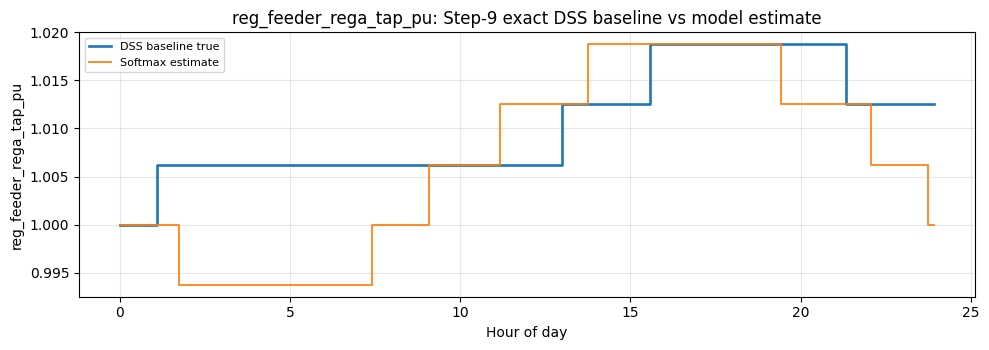

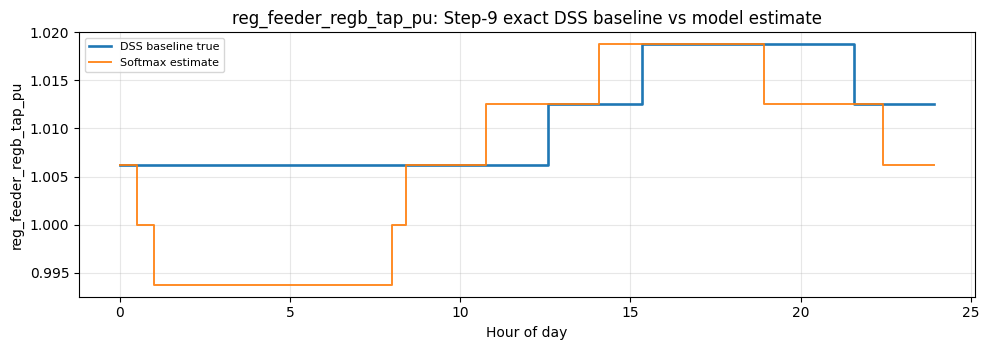

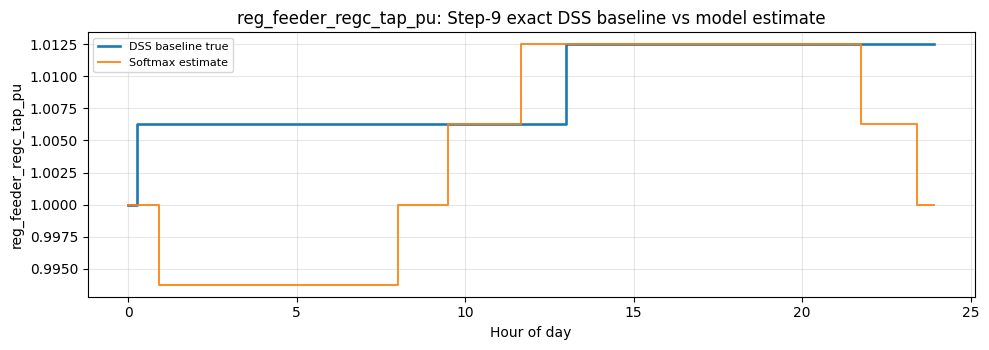

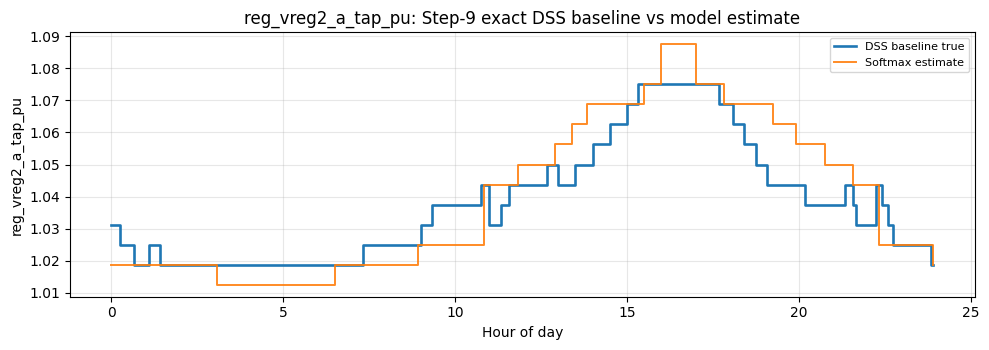

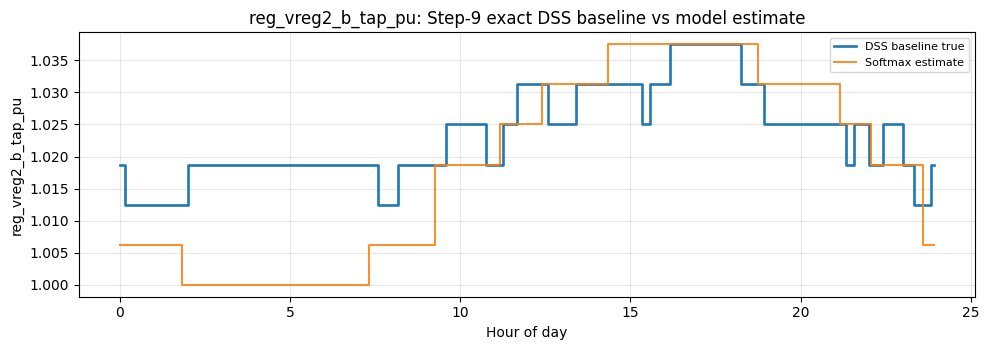

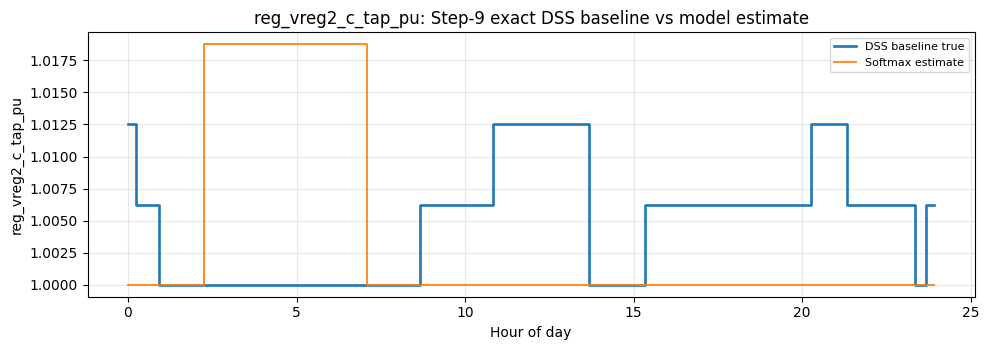

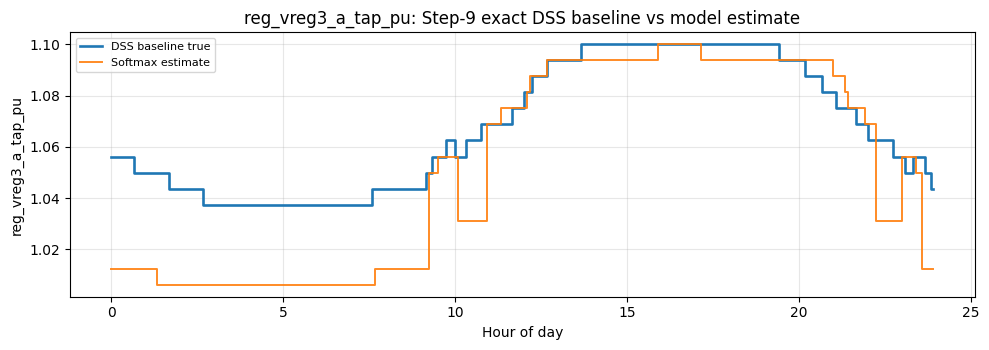

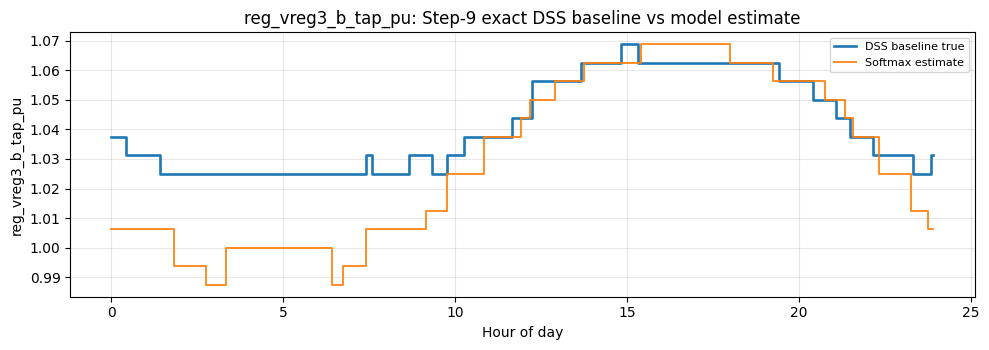

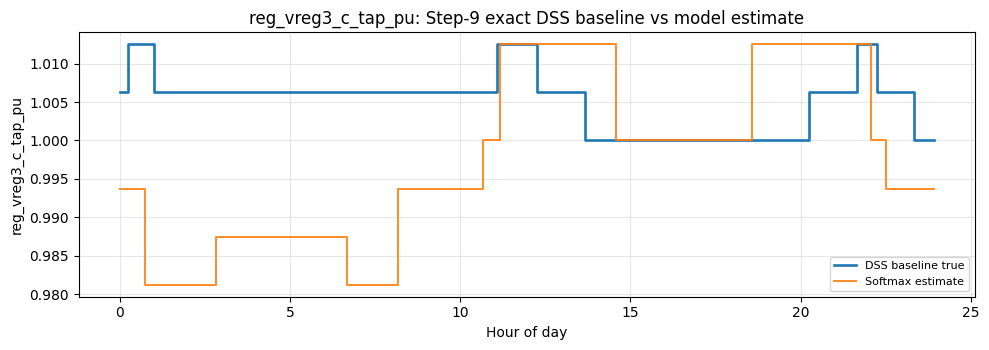

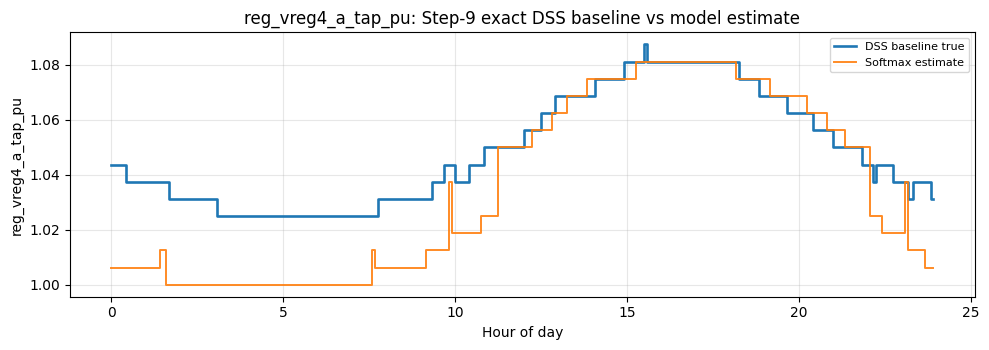

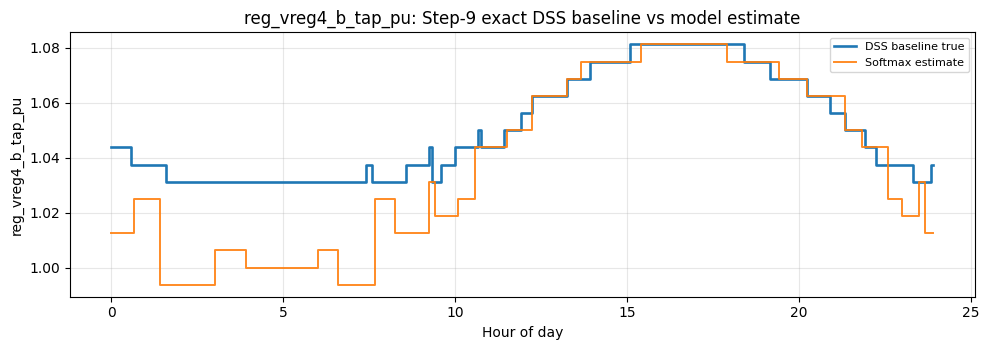

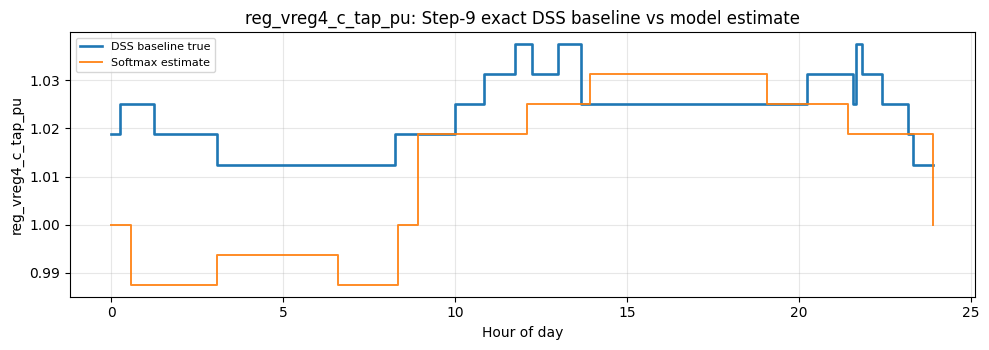

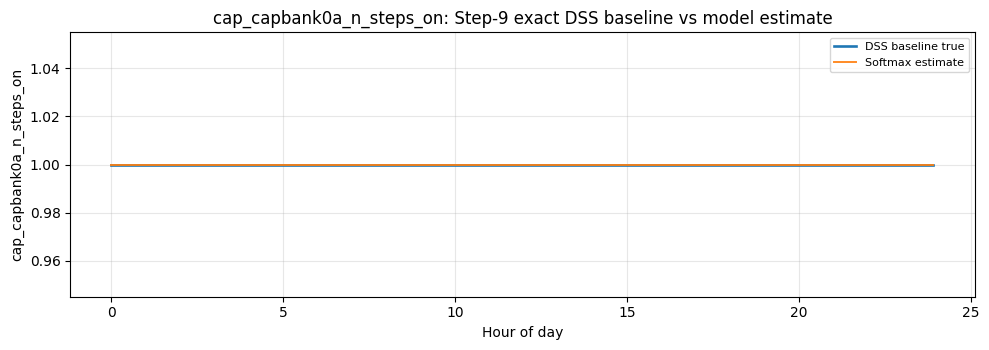

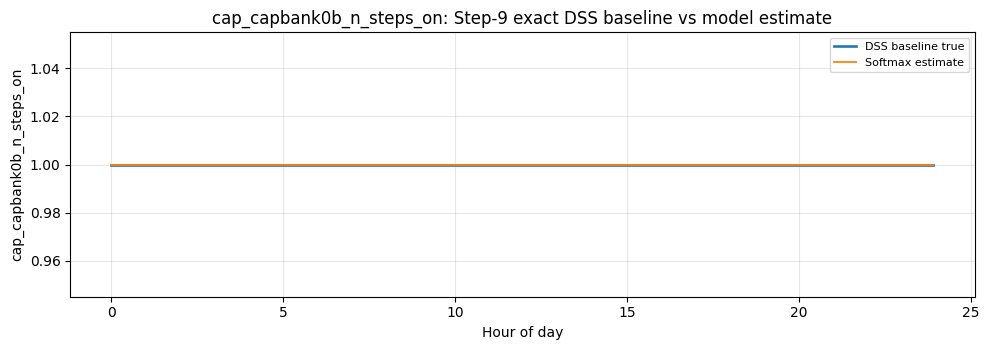

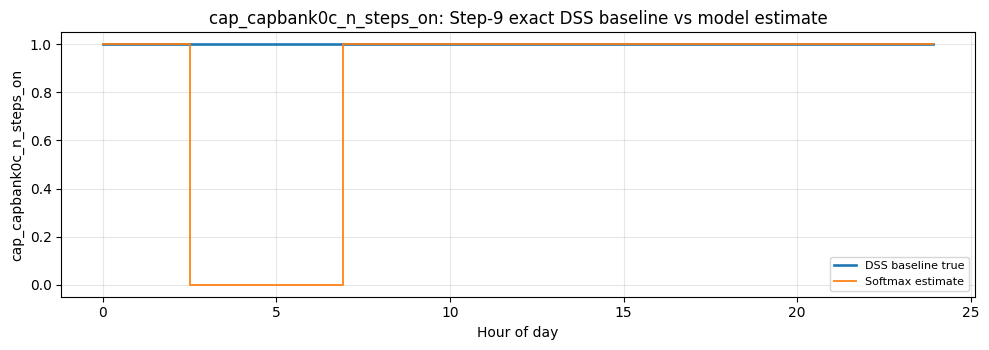

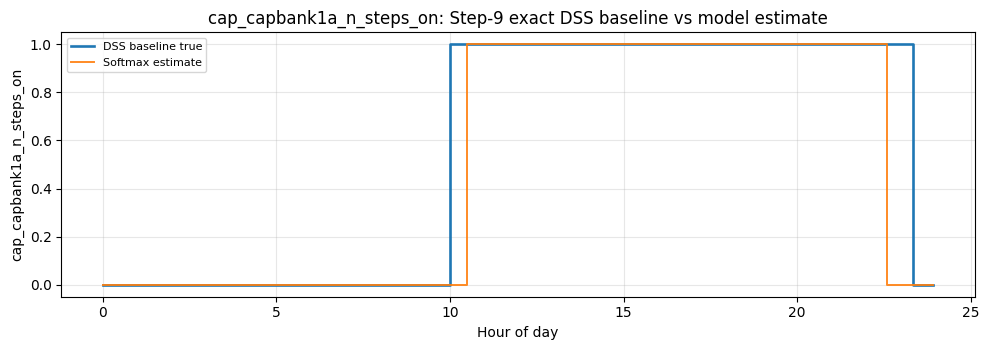

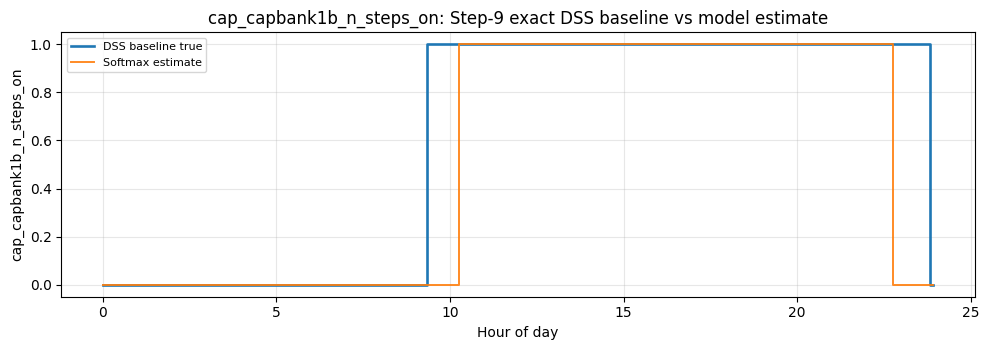

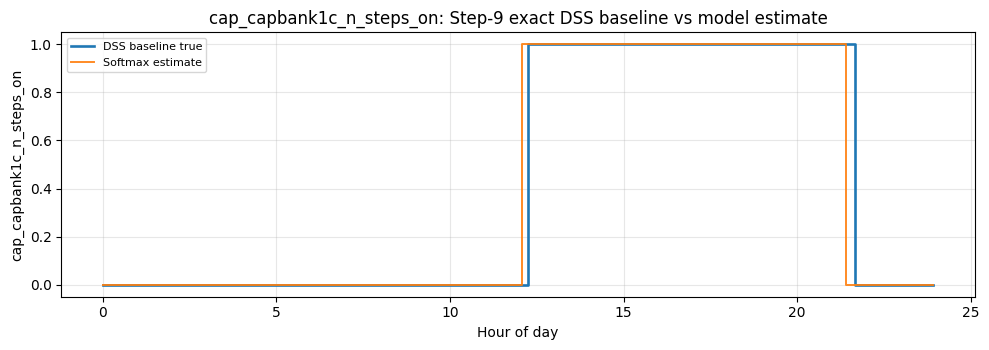

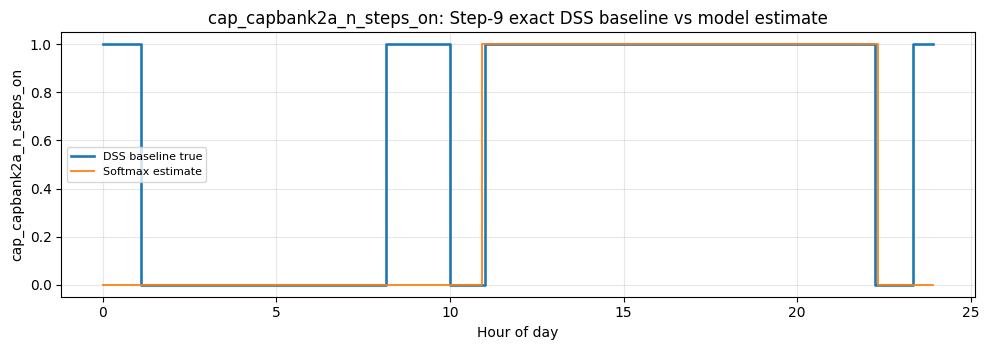

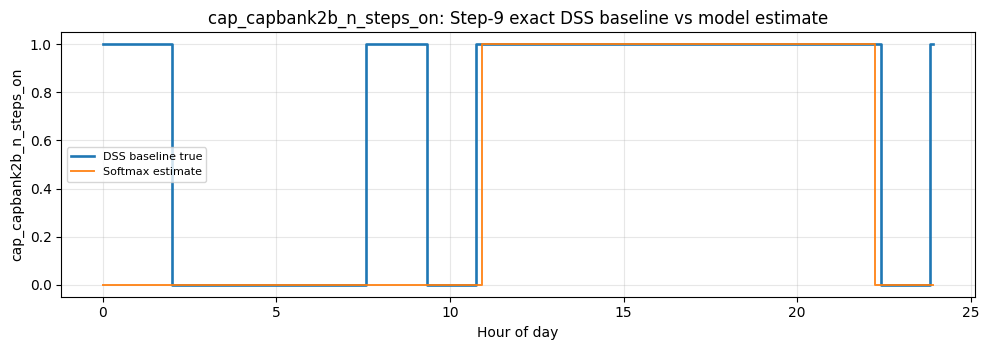

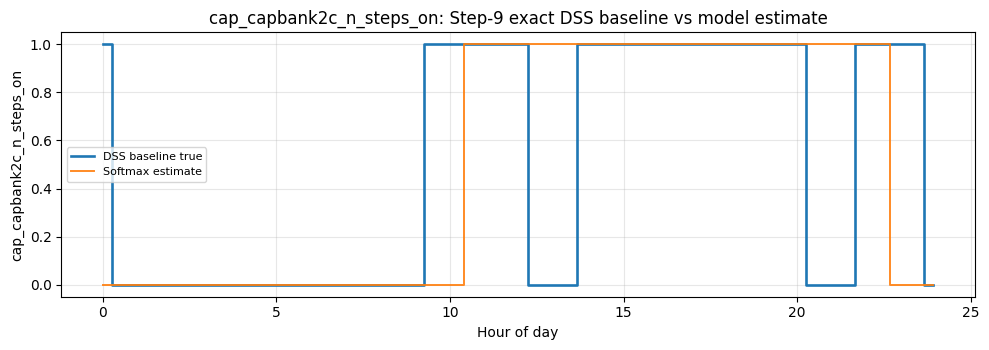

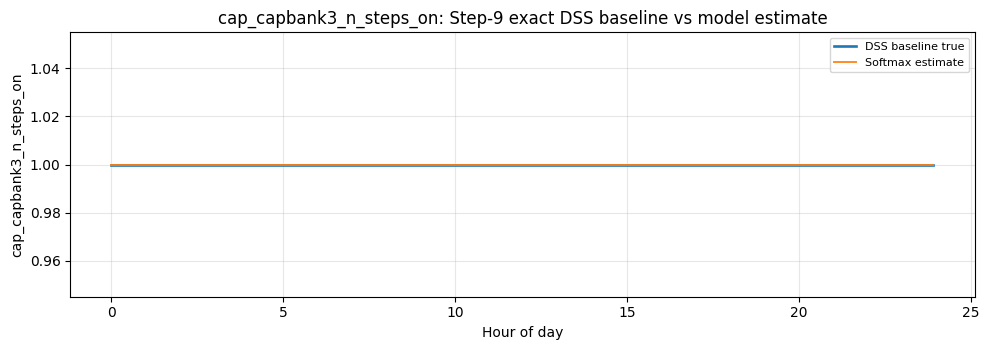

Saved per-device plots and CSV to: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\step9_exact_baseline_device_state_plots_softmax22
Timeseries CSV: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output\step9_exact_baseline_device_state_plots_softmax22\step9_exact_dss_vs_softmax22_timeseries.csv


In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import opendssdirect as dss

import run_loadtype_dataset_8500 as lt8500
import run_daily_aggregate_dataset_8500 as daily8500

TARGET_COLS = [
    "reg_feeder_rega_tap_pu",
    "reg_feeder_regb_tap_pu",
    "reg_feeder_regc_tap_pu",
    "reg_vreg2_a_tap_pu",
    "reg_vreg2_b_tap_pu",
    "reg_vreg2_c_tap_pu",
    "reg_vreg3_a_tap_pu",
    "reg_vreg3_b_tap_pu",
    "reg_vreg3_c_tap_pu",
    "reg_vreg4_a_tap_pu",
    "reg_vreg4_b_tap_pu",
    "reg_vreg4_c_tap_pu",
    "cap_capbank0a_n_steps_on",
    "cap_capbank0b_n_steps_on",
    "cap_capbank0c_n_steps_on",
    "cap_capbank1a_n_steps_on",
    "cap_capbank1b_n_steps_on",
    "cap_capbank1c_n_steps_on",
    "cap_capbank2a_n_steps_on",
    "cap_capbank2b_n_steps_on",
    "cap_capbank2c_n_steps_on",
    "cap_capbank3_n_steps_on",
]
NPTS = 288
STEP_MIN = 5


class MLPClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden: int, num_layers: int, dropout: float, n_classes: int):
        super().__init__()
        layers = []
        d = in_dim
        for i in range(num_layers):
            layers.append(nn.Linear(d, hidden))
            layers.append(nn.ReLU())
            if dropout > 0 and i < num_layers - 1:
                layers.append(nn.Dropout(dropout))
            d = hidden
        layers.append(nn.Linear(d, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def detect_repo_root() -> Path:
    candidates = [
        Path(os.environ.get("GNN_REPO", "")),
        Path(os.environ.get("GNN2_REPO", "")),
        Path.cwd(),
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path("/content/GNN-Sandia"),
    ]
    for p in candidates:
        if not str(p):
            continue
        if (p / "8500-node" / "Run_8500Node_Daily_5min.dss").is_file():
            return p.resolve()
    raise FileNotFoundError("Could not locate repo root with 8500-node/Run_8500Node_Daily_5min.dss")


repo = detect_repo_root()
os.chdir(repo)
print("Using repo:", repo)

pt_dir_candidates = [
    repo / "gnn2_architecture_search_softmax_22",
    repo / "gnn2_architecture_search" / "gnn2_architecture_search_softmax_22",
]
pt_dir = None
for p in pt_dir_candidates:
    if p.is_dir():
        pt_dir = p
        break
if pt_dir is None:
    raise FileNotFoundError(f"Could not find softmax checkpoint folder. Tried: {pt_dir_candidates}")
print("Checkpoint dir:", pt_dir)

# Exact Step-9 baseline solve setup
dss.Basic.ClearAll()
run_dss = repo / "8500-node" / "Run_8500Node_Daily_5min.dss"
dss.Text.Command(f'redirect "{os.path.abspath(str(run_dss))}"')
dss.Text.Command("set mode=daily")
dss.Text.Command("set stepsize=5m")
dss.Text.Command("set number=1")
dss.Text.Command("set maxiterations=30")
dss.Text.Command("set maxcontroliter=20000")

# Node order from live DSS
all_nodes = []
for n in dss.Circuit.AllNodeNames():
    s = str(n).strip().lower()
    if "." not in s:
        continue
    bus, phs = s.rsplit(".", 1)
    try:
        ph = int(phs)
    except Exception:
        continue
    if ph in (1, 2, 3):
        all_nodes.append(s)
all_nodes = list(dict.fromkeys(all_nodes))
if not all_nodes:
    raise RuntimeError("No phase nodes found from live DSS")

loads, load_to_busph = daily8500._collect_loads_and_maps()
load_names = [str(d["name"]) for d in loads]
reg_names = daily8500._discover_reg_controls()
cap_names = daily8500._discover_capacitors()

time_h = np.arange(NPTS, dtype=float) * (STEP_MIN / 60.0)
X = np.zeros((NPTS, len(all_nodes), 2), dtype=np.float32)
truth = pd.DataFrame({"t_index": np.arange(NPTS, dtype=int), "hour": time_h})

n_nonconv = 0
n_ctrl_warn = 0
for t in range(NPTS):
    hr = int(t // 12)
    sec = int((t % 12) * 300)
    dss.Text.Command(f"set hour={hr} sec={sec}")
    try:
        dss.Solution.Solve()
    except Exception as e:
        if "Max Control Iterations Exceeded" in str(e):
            n_ctrl_warn += 1
        n_nonconv += 1
        continue
    if not dss.Solution.Converged():
        n_nonconv += 1
        continue

    busphP_load = {}
    busphQ_load = {}
    for ln in load_names:
        try:
            dss.Circuit.SetActiveElement(f"Load.{ln}")
            pq = dss.CktElement.TotalPowers()
            p_set = abs(float(pq[0])) if len(pq) >= 1 else 0.0
            q_set = abs(float(pq[1])) if len(pq) >= 2 else 0.0
            fracs = load_to_busph.get(ln, lt8500._busph_fracs_load(ln))
            for (bus, ph, w) in fracs:
                busphP_load[(bus, ph)] = busphP_load.get((bus, ph), 0.0) + p_set * float(w)
                busphQ_load[(bus, ph)] = busphQ_load.get((bus, ph), 0.0) + q_set * float(w)
        except Exception:
            continue

    for i, node in enumerate(all_nodes):
        bus, phs = node.rsplit(".", 1)
        ph = int(phs)
        X[t, i, 0] = float(busphP_load.get((bus, ph), 0.0))
        X[t, i, 1] = float(busphQ_load.get((bus, ph), 0.0))

    row = {}
    row.update(daily8500._read_reg_control_state(reg_names))
    row.update(daily8500._read_capacitor_state(cap_names))
    for c in TARGET_COLS:
        truth.loc[t, c] = float(row.get(c, np.nan))

    if (t + 1) % 24 == 0:
        print(f"[{t+1}/{NPTS}] DSS baseline collected", flush=True)

print(f"DSS baseline solve done: nonconverged/failed={n_nonconv}, max-control warnings={n_ctrl_warn}")

# Prefer normalization stats saved in best checkpoints.
x_mean = None
x_std = None
for c in TARGET_COLS:
    ck_norm = torch.load(pt_dir / c / "best.pt", map_location="cpu")
    if "x_mean" in ck_norm and "x_std" in ck_norm:
        x_mean = ck_norm["x_mean"].numpy().astype(np.float32)
        x_std = ck_norm["x_std"].numpy().astype(np.float32)
        break

if x_mean is None or x_std is None:
    cache_path = pt_dir / "node_features_X.pt"
    if cache_path.is_file():
        Xcache = torch.load(cache_path, map_location="cpu")
        xf = Xcache.reshape(-1, 2)
        x_mean = xf.mean(dim=0, keepdim=True).numpy().astype(np.float32)
        x_std = xf.std(dim=0, unbiased=False, keepdim=True).numpy().astype(np.float32)
    else:
        xf = X.reshape(-1, 2)
        x_mean = xf.mean(axis=0, keepdims=True).astype(np.float32)
        x_std = xf.std(axis=0, keepdims=True).astype(np.float32)
        print("[WARN] node_features_X.pt not found; using Step-9 baseline stats for normalization")

x_std = np.clip(x_std, 1e-6, None)

Xn = (X - x_mean.reshape(1, 1, 2)) / x_std.reshape(1, 1, 2)
Xflat = torch.from_numpy(Xn.reshape(NPTS, -1)).float()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pred = pd.DataFrame({"t_index": np.arange(NPTS, dtype=int), "hour": time_h})

for c in TARGET_COLS:
    ckpt_path = pt_dir / c / "best.pt"
    if not ckpt_path.is_file():
        raise FileNotFoundError(ckpt_path)
    ck = torch.load(ckpt_path, map_location="cpu")
    class_values = np.asarray(ck["class_values"], dtype=np.float32)

    hidden = int(ck.get("hidden_dim", 128))
    num_layers = int(ck.get("num_layers", 3))
    dropout = float(ck.get("dropout", 0.1))

    model = MLPClassifier(
        in_dim=Xflat.shape[1],
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        n_classes=int(ck["n_classes"]),
    ).to(device)
    model.load_state_dict(ck["model_state_dict"])
    model.eval()

    with torch.no_grad():
        logits = model(Xflat.to(device))
        cls = logits.argmax(dim=1).cpu().numpy().astype(np.int64)
    pred[c] = class_values[cls]

out_dir = repo / "gnn2_daily_compare_8500_output" / "step9_exact_baseline_device_state_plots_softmax22"
out_dir.mkdir(parents=True, exist_ok=True)

for c in TARGET_COLS:
    y_true = truth[c].to_numpy(dtype=float)
    y_pred = pred[c].to_numpy(dtype=float)

    plt.figure(figsize=(10, 3.6))
    plt.step(time_h, y_true, where="post", linewidth=1.9, label="DSS baseline true")
    plt.step(time_h, y_pred, where="post", linewidth=1.4, alpha=0.9, label="Softmax estimate")
    plt.xlabel("Hour of day")
    plt.ylabel(c)
    plt.title(f"{c}: Step-9 exact DSS baseline vs model estimate")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    fp = out_dir / f"step9_exact_{c}.png"
    plt.savefig(fp, dpi=170)
    plt.show()

cmp = truth.merge(pred, on=["t_index", "hour"], suffixes=("_true", "_pred"))
cmp_csv = out_dir / "step9_exact_dss_vs_softmax22_timeseries.csv"
cmp.to_csv(cmp_csv, index=False)
print("Saved per-device plots and CSV to:", out_dir)
print("Timeseries CSV:", cmp_csv)

### Electrical distance (8500 daily graph) — why some nodes show unreachable

`electrical_distance.py` sums edge |Z| on the **static phase-edge CSV**, not OpenDSS's full 3-winding triplex topology.

**Why ~2815 / 8531 are unreachable:** `extract_static_phase_edges_to_csv` adds **at most two transformer bus specs per element**. Center-tapped service transformers have **three** windings (MV + two LV hots vs neutral). One LV leg can get **no** transformer edge to the MV network. The **triplex** only links `X.*.k` to `SX.*.k` for the **same** `k`; it does **not** connect `.1` to `.2`. So **`X...k` and `SX...k`** can sit in a **2-node island** with **no path** to the substation in this graph — even though physically they are connected through the transformer neutral.

Unreachable rows split **evenly** between matching **`X` and `SX`** on the same leg. This is a **graph-export limitation**, not “the feeder is disconnected” in OpenDSS.

In [9]:
import importlib.util
import os
import sys
from pathlib import Path

import pandas as pd

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")
os.chdir(REPO)

for _k in list(sys.modules):
    if _k == "electrical_distance" or _k.startswith("electrical_distance."):
        del sys.modules[_k]

_ed_path = REPO / "electrical_distance.py"
_spec = importlib.util.spec_from_file_location("electrical_distance_gnn2", _ed_path)
_ed = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_ed)

CASE_PATHS = _ed.CASE_PATHS
build_8500_static_csvs = _ed.build_8500_static_csvs
compute_electrical_distances_dataframe = _ed.compute_electrical_distances_dataframe

default_results_csv_path = _ed.default_results_csv_path
save_electrical_distances_csv = _ed.save_electrical_distances_csv

CASE = "8500-daily"
rel_ni, rel_ed = CASE_PATHS[CASE]
NODE_CSV = REPO / rel_ni
EDGE_CSV = REPO / rel_ed

if not NODE_CSV.is_file() or not EDGE_CSV.is_file():
    NODE_CSV, EDGE_CSV = build_8500_static_csvs(mode="daily", out_dir=NODE_CSV.parent)

df_edist = compute_electrical_distances_dataframe(
    NODE_CSV, EDGE_CSV, unreachable="nan", infer_case=CASE
)
r, u = int(df_edist["reachable"].sum()), int((~df_edist["reachable"]).sum())
print(f"nodes={len(df_edist)}  reachable={r}  unreachable={u}")
display(df_edist.head(8))
display(df_edist.loc[~df_edist["reachable"], ["node", "bus", "phase"]].head(20))
OUT_CSV = default_results_csv_path(NODE_CSV)
saved_path = save_electrical_distances_csv(df_edist, OUT_CSV)
print(f"Saved electrical distance table -> {saved_path}")

df_edist["electrical_distance_ohm"].describe()


nodes=8531  reachable=5716  unreachable=2815


,node,bus,phase,electrical_distance_ohm,reachable
0,sourcebus.1,sourcebus,1,NaN,False
1,sourcebus.2,sourcebus,2,NaN,False
2,sourcebus.3,sourcebus,3,NaN,False
3,_hvmv_sub_lsb.1,_hvmv_sub_lsb,1,0.00000,True
4,_hvmv_sub_lsb.2,_hvmv_sub_lsb,2,0.00000,True
5,_hvmv_sub_lsb.3,_hvmv_sub_lsb,3,0.00000,True
6,hvmv_sub_48332.1,hvmv_sub_48332,1,0.00001,True
7,hvmv_sub_48332.2,hvmv_sub_48332,2,0.00001,True


,node,bus,phase
0,sourcebus.1,sourcebus,1
1,sourcebus.2,sourcebus,2
2,sourcebus.3,sourcebus,3
3824,x2804253a.2,x2804253a,2
3827,x3216339b.1,x3216339b,1
3830,x2954355a.2,x2954355a,2
3831,x2861197c.1,x2861197c,1
3832,x2861197c.2,x2861197c,2
3834,x2842379a.2,x2842379a,2
3835,x2841636b.1,x2841636b,1


Saved electrical distance table -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\electrical_distance_from_substation.csv


count    5716.000000
mean       12.675512
std         9.628075
min         0.000000
25%         6.179898
50%        10.373944
75%        14.018538
max        40.878617
Name: electrical_distance_ohm, dtype: float64

## IEEE8500_OpenDSS_timing

Parses `8500-node/LoadXfmrs.dss` and `8500-node/Triplex_Lines.DSS`. CSV columns are **OpenDSS node strings** (bus + node numbers), not bare bus names:
- `mv_node` — primary winding (e.g. `L2804253.1`)
- `lv_x_node_1`, `lv_x_node_2` — LV hot legs on the X bus (`X....1`, `X....2`) from the 3-winding center-tapped definition
- `sx_node_1`, `sx_node_2` — triplex load-side hots (`SX....1`, `SX....2`) from `Bus2` of the triplex line

Output: `8500-node/mv_x_sx_node_mapping_8500.csv`.


In [11]:
import os
import re
from pathlib import Path

import pandas as pd

REPO = Path(os.getcwd())
if not (REPO / "8500-node" / "LoadXfmrs.dss").exists():
    REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2")

LOAD_XFMRS = REPO / "8500-node" / "LoadXfmrs.dss"
TRIPLEX_LINES = REPO / "8500-node" / "Triplex_Lines.DSS"
OUT_CSV = REPO / "8500-node" / "mv_x_sx_node_mapping_8500.csv"


def _bus_base(bus_spec: str) -> str:
    return bus_spec.split(".")[0]


def _lv_x_hot_nodes_from_wdg23(w2: str, w3: str) -> tuple[str, str]:
    """Center-tapped secondary: wdg2 X.bus.1.0 and wdg3 X.bus.0.2 -> hot nodes bus.1 and bus.2."""
    b2 = _bus_base(w2)
    b3 = _bus_base(w3)
    if b2.lower() != b3.lower():
        return f"{b2}.?", f"{b3}.?"
    return f"{b2}.1", f"{b2}.2"


def _sx_hot_nodes_from_triplex_bus2(bus2_full: str) -> tuple[str, str]:
    """Triplex Bus2 like SX2673305B.1.2 -> SX2673305B.1 and SX2673305B.2."""
    if not bus2_full or not bus2_full.strip():
        return "", ""
    parts = bus2_full.strip().split(".")
    if len(parts) < 3:
        return "", ""
    bus = parts[0]
    return f"{bus}.{parts[1]}", f"{bus}.{parts[2]}"


def parse_loadxfmrs(path: Path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("New Transformer."):
                continue
            w1 = re.search(r"wdg=1\s+bus=(\S+)", line)
            w2 = re.search(r"wdg=2\s+bus=(\S+)", line)
            w3 = re.search(r"wdg=3\s+bus=(\S+)", line)
            if not (w1 and w2 and w3):
                continue
            mv_node = w1.group(1)
            w2s, w3s = w2.group(1), w3.group(1)
            x1, x2 = _lv_x_hot_nodes_from_wdg23(w2s, w3s)
            rows.append(
                {
                    "mv_node": mv_node,
                    "lv_x_node_1": x1,
                    "lv_x_node_2": x2,
                    "_x_key": _bus_base(w2s).lower(),
                }
            )
    return rows


def parse_triplex_by_x_base(path: Path) -> dict:
    out = {}
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("New Line."):
                continue
            b1 = re.search(r"Bus1=(\S+)", line)
            b2 = re.search(r"Bus2=(\S+)", line)
            if not (b1 and b2):
                continue
            xb = _bus_base(b1.group(1)).lower()
            out[xb] = b2.group(1)
    return out


rows = parse_loadxfmrs(LOAD_XFMRS)
tri = parse_triplex_by_x_base(TRIPLEX_LINES)

for r in rows:
    b2 = tri.get(r["_x_key"], "")
    s1, s2 = _sx_hot_nodes_from_triplex_bus2(b2)
    r["sx_node_1"] = s1
    r["sx_node_2"] = s2
    del r["_x_key"]

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(df)} rows -> {OUT_CSV}")
print(df.head(3).to_string())
print("...")
print(f"Rows with empty SX nodes (no triplex match): {(df['sx_node_1'] == '').sum()}")


Wrote 1177 rows -> C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
      mv_node  lv_x_node_1  lv_x_node_2     sx_node_1     sx_node_2
0  L2804253.1  X2804253A.1  X2804253A.2  SX2804253A.1  SX2804253A.2
1  L3254213.2  X3254213B.1  X3254213B.2  SX3254213B.1  SX3254213B.2
2  L3216339.2  X3216339B.1  X3216339B.2  SX3216339B.1  SX3216339B.2
...
Rows with empty SX nodes (no triplex match): 6


## MV-only node dataset (aggregate)

Builds **`datasets_gnn2/loadtype_8500_dailyagg/gnn_node_features_and_targets_mv_only.csv`** from the full **`gnn_node_features_and_targets.csv`** (streamed) and **`mv_x_sx_node_mapping_8500.csv`**.

- **Rows:** one per `(sample_id, mv_node)` from the mapping (each service transformer).
- **P/Q:** sum of `p_load_kw` / `q_load_kvar` on **`sx_node_1` + `sx_node_2`** when both are set; otherwise **`lv_x_node_1` + `lv_x_node_2`**.
- **V:** `vmag_pu` / `vang_deg` (and `electrical_distance_ohm`, `node_idx`, `bus`, `phase`) from the **`mv_node`** row.

Same **10 columns** as the source node CSV. Full pass over the 8GB+ file can take tens of minutes; use `--max-samples N` for a quick test.

Matching node names are **case-insensitive** (dataset nodes are often lowercase).


In [13]:
import os
os.chdir(r"C:\Users\alita\OneDrive\Desktop\GNN2")

# Full dataset (long run)
%run aggregate_mv_node_dataset_8500.py

# Quick test: only first 3 completed samples
# %run aggregate_mv_node_dataset_8500.py --max-samples 3


[aggregate_mv_node_dataset_8500] wrote 11660539 rows -> C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_node_features_and_targets_mv_only.csv
  samples (power-flow cases) written: 9907
  missing_mv (no mv_node in buffer for that sample): 0
  missing load-node increments (node not in buffer): 0


## MV interest subgraph (anchors to feeder tree)

Runs `build_mv_interest_subgraph_edges.py`: unions shortest-path edges (weight = sqrt(R_full^2 + X_full^2)) from substation roots to each anchor. Anchors come from `mv_x_sx_node_mapping_8500.csv` (mv_node), `regulator_involved_nodes.csv` (both terminals), and `capacitor_involved_nodes.csv` (From node).

Writes to `datasets_gnn2/loadtype_8500_dailyagg/`:
- `mv_interest_anchor_nodes.csv`
- `gnn_edges_phase_static_mv_only.csv`


In [16]:
import os
os.chdir(r'C:\Users\alita\OneDrive\Desktop\GNN2')
%run build_mv_interest_subgraph_edges.py


  anchor Dijkstra progress 200/1212 ...
  anchor Dijkstra progress 400/1212 ...
  anchor Dijkstra progress 600/1212 ...
  anchor Dijkstra progress 800/1212 ...
  anchor Dijkstra progress 1000/1212 ...
  anchor Dijkstra progress 1200/1212 ...
[build_mv_interest_subgraph_edges] anchors=1212
  Edge model: synthetic A–B with sum(R,X,C) on min-|Z| path, skip if another anchor on path interior.
  synthetic anchor–anchor edges written: 2741
  pairs skipped (interior anchor on shortest path): 242504
  pair attempts unreachable: 488621
  wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\gnn_edges_phase_static_mv_only.csv
  wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\mv_interest_anchor_nodes.csv


### MV anchor subgraph (three anchor types)

The script `visualize_mv_anchor_subgraph.py` draws the MV-only edge graph and colors nodes by **MV** (mapping), **regulator** (terminals), and **capacitor** (from-node) lists; nodes in more than one category get a distinct blend. Output PNG is written under `datasets_gnn2/loadtype_8500_dailyagg/` by default.


Graph |V|=1212 |E|=2741
Saved C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\mv_subgraph_layout_by_type.png


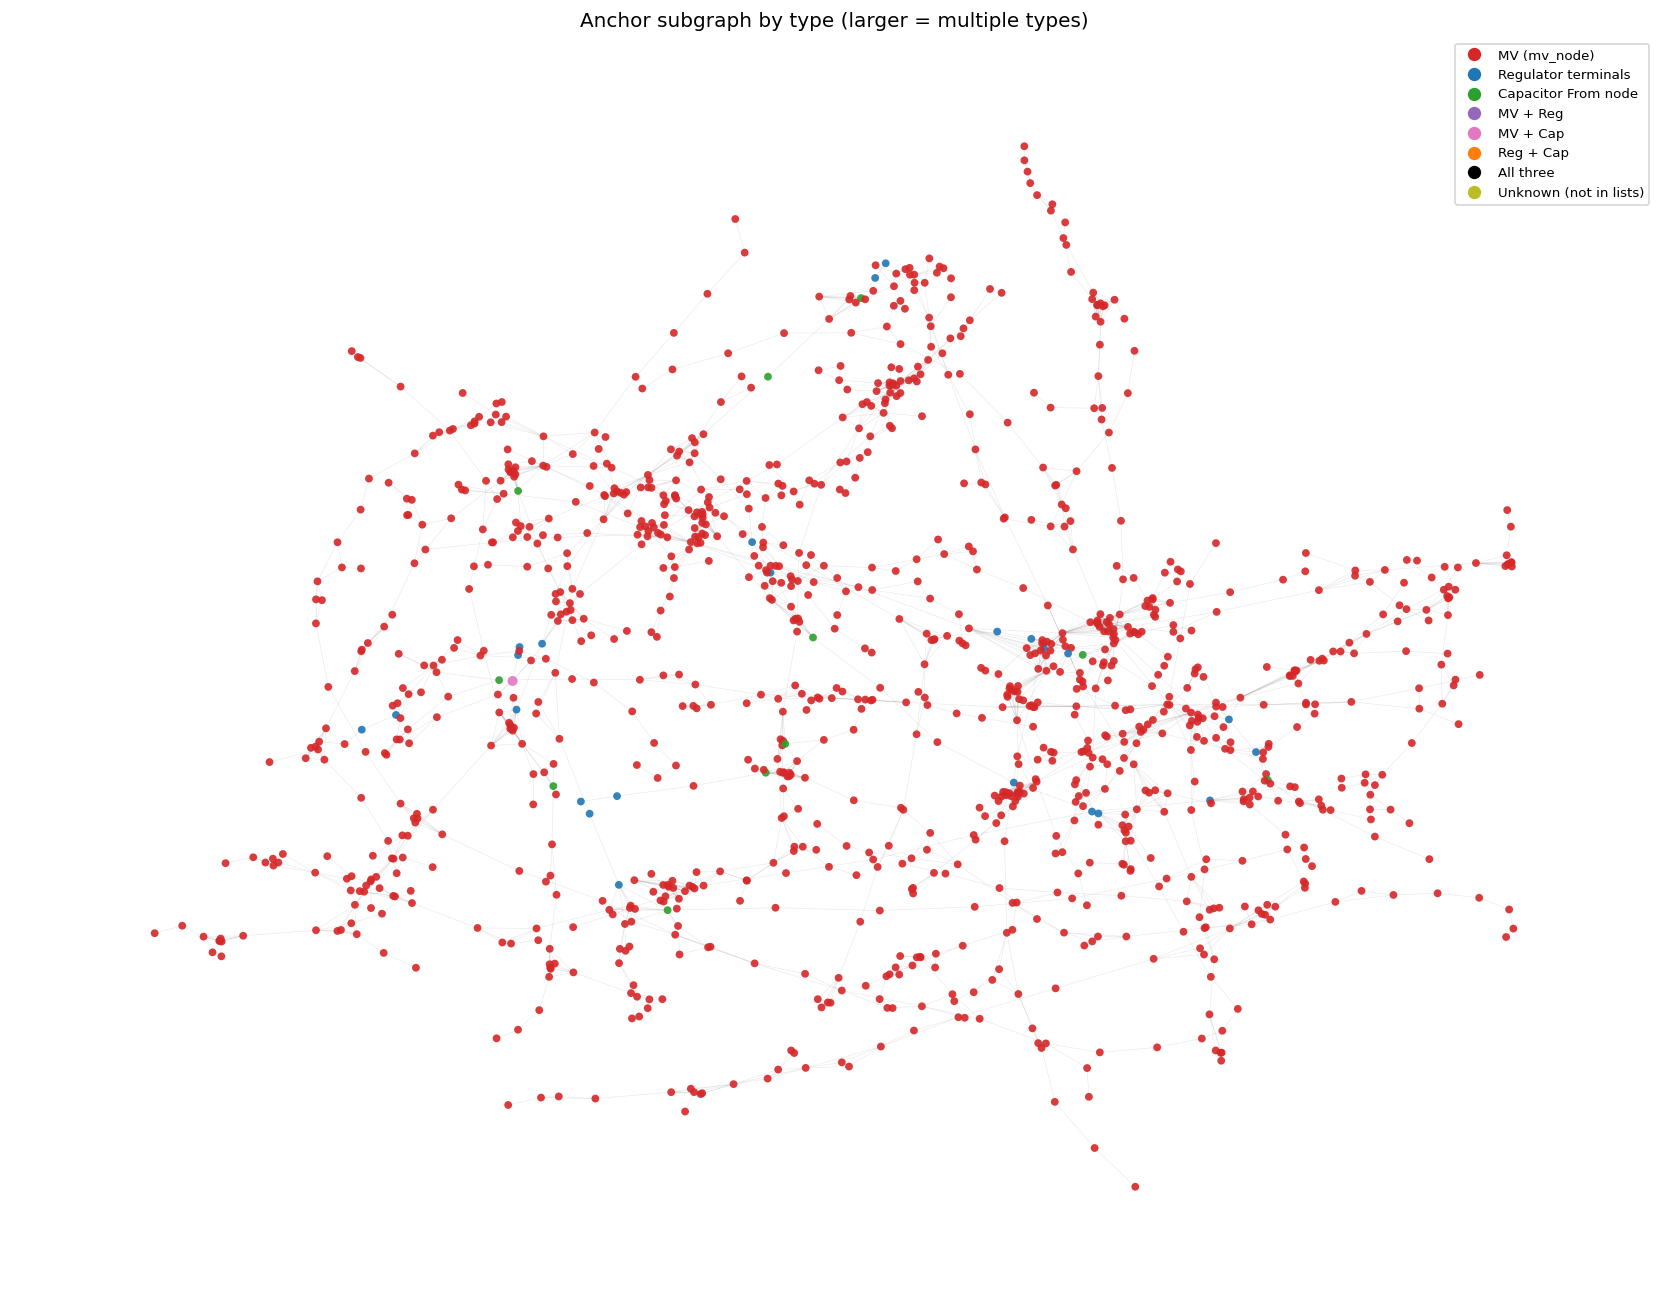

In [18]:
import os
from pathlib import Path

# Repo root (Colab: os.chdir("/content/GNN-Sandia") or your clone path)
os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run visualize_mv_anchor_subgraph.py


### Heterogeneous MV edge dataset (line vs regulator)

Runs `build_hetero_mv_edge_dataset.py` to build:

- **`hetero_mv_edge_catalog.csv`** — all edges from `gnn_edges_phase_static_mv_only.csv` with `edge_type` (`line` or `regulator`), `R_full` / `X_full`, `u_idx` / `v_idx`
- **`hetero_mv_line_edge_attr.csv`** — static `R_full`, `X_full` for line edges only
- **`hetero_mv_regulator_edge_features.csv`** — per `sample_id` × regulator edge: 12 tap columns from `gnn_sample_meta.csv`

Default data folder: `datasets_gnn2/loadtype_8500_dailyagg/`.

In [20]:
import os
from pathlib import Path

os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run build_hetero_mv_edge_dataset.py

[build_hetero_mv_edge_dataset] wrote C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg/
  edges total=2741  line=2729  regulator=12
  samples=9907  regulator-edge feature rows=118884 (= 9907 * 12)
  hetero_mv_edge_catalog.csv
  hetero_mv_line_edge_attr.csv
  hetero_mv_regulator_edge_features.csv


### Hetero node-type CSVs (full `gnn_node_features_and_targets`)

Runs `build_hetero_mv_node_type_datasets.py`: regulator up/down from full graph; cap file = **12 fixed From nodes** only; load-transformer = nodes listed in `gnn_node_features_and_targets_mv_only.csv`, features from **full** node CSV.

In [1]:
import os
from pathlib import Path

os.chdir(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
%run build_hetero_mv_node_type_datasets.py

[build_hetero_mv_node_type_datasets] out_dir=C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
  hetero_mv_nodes_regulator_upstream.csv: 118884 rows
  hetero_mv_nodes_regulator_downstream.csv: 118884 rows
  hetero_mv_nodes_capacitor_related.csv: 118884 rows
  hetero_mv_nodes_load_transformer.csv: 11660539 rows
  sets: regulator terminal_1=12 terminal_2=12 cap_from_fixed=12 load_xfmr(nodes_in_mv_only)=1177


### Heterogeneous MV GNN — architecture search (8500)

**Data folder:** `datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset/`  
- **Nodes (4 CSVs):** regulator terminal_1 / terminal_2, 12 cap From buses, load-transformer MV buses.  
- **Edges:** MV-only graph — `line` (R,X) + `regulator` (per-sample `reg_tap_pu`).

**Model:** `HeteroConv` on node type `bus` with two relations (`line`, `reg`). **Target:** `vmag_pu` only.  
**Training:** default **1/3** of samples, early stopping; **`l2823592.1`** excluded from **training** loss (not from val).

**Script:** `search_hetero_mv_gnn_architectures.py` — tries **5** architectures and saves rankings under `gnn2_architecture_search/hetero_mv_8500/`.

In [ ]:
import os

REPO_DIR = "/content/GNN-Sandia"
os.chdir(REPO_DIR)
print("cwd:", os.getcwd())

%run search_hetero_mv_gnn_architectures.py --target-node-types load

cwd: /content/GNN-Sandia
[hetero_mv_search] reading edge catalog + line attrs...
[hetero_mv_search] scanning node CSVs for bus names (load file can take several minutes)...
[hetero_mv_search] membership scan (full pass over load CSV in chunks)...
[hetero_mv_search] building typed topology + tensors...
[hetero_mv_search] loading regulator tap table...
[hetero_mv_search] device=cuda typed_nodes={'upstream': 12, 'downstream': 12, 'capacitor': 11, 'load': 1177} relations=13
  E_line(undir pairs)~2729 E_reg~12
  samples total=9907 pool(frac)=3302 train=2642 val=660
  exclude from train loss: type=load local=997 (frozenset({'l2823592.1'}))
  exclude from train loss: 1 bus(es) in 2+ node CSVs (global_idx sample: [3450])
  vmag_pu loss restricted to storages ['load'] (1177 node positions; loss only where labels exist)
[hetero_mv_search] accumulating per-sample node features (another full load-CSV pass)...
  ... reading upstream CSV
  ... reading downstream CSV
  ... reading capacitor CSV
  ... reading load CSV
[hetero_mv_search] building GPU cache for train/val samples...

>>> Training hetero_sage_2x96 (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.055128  best_val_rmse=0.055128  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.034517  best_val_rmse=0.034517  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.029759  best_val_rmse=0.028418  no_improve_streak=1/18
    epoch   30/120  val_rmse=0.026338  best_val_rmse=0.025980  no_improve_streak=1/18
    epoch   40/120  val_rmse=0.023036  best_val_rmse=0.022772  no_improve_streak=1/18
    epoch   50/120  val_rmse=0.021722  best_val_rmse=0.021722  no_improve_streak=0/18
    epoch   60/120  val_rmse=0.020748  best_val_rmse=0.020290  no_improve_streak=1/18
    epoch   70/120  val_rmse=0.019459  best_val_rmse=0.019459  no_improve_streak=0/18
    epoch   80/120  val_rmse=0.019335  best_val_rmse=0.019075  no_improve_streak=2/18
    epoch   90/120  val_rmse=0.042375  best_val_rmse=0.019075  no_improve_streak=12/18

>>> Training hetero_sage_4x64_ln_drop (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.056965  best_val_rmse=0.056965  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.023154  best_val_rmse=0.022878  no_improve_streak=3/18
    epoch   20/120  val_rmse=0.014866  best_val_rmse=0.014866  no_improve_streak=0/18
    epoch   30/120  val_rmse=0.009533  best_val_rmse=0.009243  no_improve_streak=2/18
    epoch   40/120  val_rmse=0.007345  best_val_rmse=0.007211  no_improve_streak=5/18
    epoch   50/120  val_rmse=0.006751  best_val_rmse=0.006372  no_improve_streak=4/18
    epoch   60/120  val_rmse=0.005747  best_val_rmse=0.005747  no_improve_streak=0/18
    epoch   70/120  val_rmse=0.007185  best_val_rmse=0.005747  no_improve_streak=10/18

>>> Training hetero_gat_2L4h128 (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.072095  best_val_rmse=0.072095  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.031452  best_val_rmse=0.031452  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.024642  best_val_rmse=0.023282  no_improve_streak=7/18
    epoch   30/120  val_rmse=0.026474  best_val_rmse=0.023262  no_improve_streak=3/18
    epoch   40/120  val_rmse=0.025283  best_val_rmse=0.023262  no_improve_streak=13/18

>>> Training hetero_sage_3x112_wide (gine_edge_attr=False)
    epoch    1/120  val_rmse=0.069060  best_val_rmse=0.069060  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.037041  best_val_rmse=0.037041  no_improve_streak=0/18
    epoch   20/120  val_rmse=0.024723  best_val_rmse=0.023227  no_improve_streak=2/18
    epoch   30/120  val_rmse=0.026293  best_val_rmse=0.023227  no_improve_streak=12/18

>>> Training hetero_gine_3x80 (gine_edge_attr=True)
    epoch    1/120  val_rmse=0.057133  best_val_rmse=0.057133  no_improve_streak=0/18
    epoch   10/120  val_rmse=0.010533  best_val_rmse=0.010005  no_improve_streak=1/18
    epoch   20/120  val_rmse=0.007750  best_val_rmse=0.006388  no_improve_streak=1/18
    epoch   30/120  val_rmse=0.006505  best_val_rmse=0.005912  no_improve_streak=6/18
    epoch   40/120  val_rmse=0.007944  best_val_rmse=0.005912  no_improve_streak=16/18

========================================================================
                cfg_name  best_val_rmse  val_mae  epochs_ran          sec
hetero_sage_4x64_ln_drop       0.005747 0.004432          78 11501.036531
        hetero_gine_3x80       0.005912 0.004461          42  6043.124469
        hetero_sage_2x96       0.019075 0.014658          96  6422.614147
  hetero_sage_3x112_wide       0.023227 0.017760          36  3935.435601
      hetero_gat_2L4h128       0.023262 0.017811          45  6299.583941

Wrote /content/GNN-Sandia/gnn2_architecture_search/hetero_mv_8500/search_results.csv

## 8500 Daily Comparison (OpenDSS Baseline vs Hetero Checkpoint)

Run the script below to compare one trained hetero model against the OpenDSS 24h daily solve on the 8500 feeder.

**What it does**
- Runs OpenDSS daily simulation (`5 min`, `24h`)
- Loads your hetero checkpoint (`*_best.pt`)
- Predicts node voltages from the model each timestep
- Plots selected nodes (`OpenDSS` vs `Model`)
- Saves all-node error distribution and per-node MAE CSV

**Outputs**
- Folder: `gnn2_daily_compare_8500_output`
- Files include:
  - `daily_compare_<cfg>_<node>.png`
  - `daily_error_hist_<cfg>.png`
  - `daily_mae_per_node_<cfg>.csv`

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_hetero_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_sage_4x64_ln_drop] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_hetero_mv_daily] model=hetero_sage_4x64_ln_drop device=cpu
[compare_hetero_mv_daily] checkpoint meta: vmag supervised on storages ['load']
[compare_hetero_mv_daily] OpenDSS solve timing: per-step snapshot mode (not daily warm-start).
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] feature diag (first converged step): hetero load slots with |P|+|Q|>1e-3 kW/kvar: 1171/1177
[24/288] timing so far — OpenDSS apply=0.14s | reassert=0.00s solve_only=3.99s | get V=0.84s | feature build=0.15s | GNN bucket=4.04s fwd-only=4.04s
[48/288] timing so far — OpenDSS apply=0.26s | reassert=0.00s solve_only=7.94s | get V=1.72s | feature build=0.31s | GNN bucket=7.62s fwd-only=

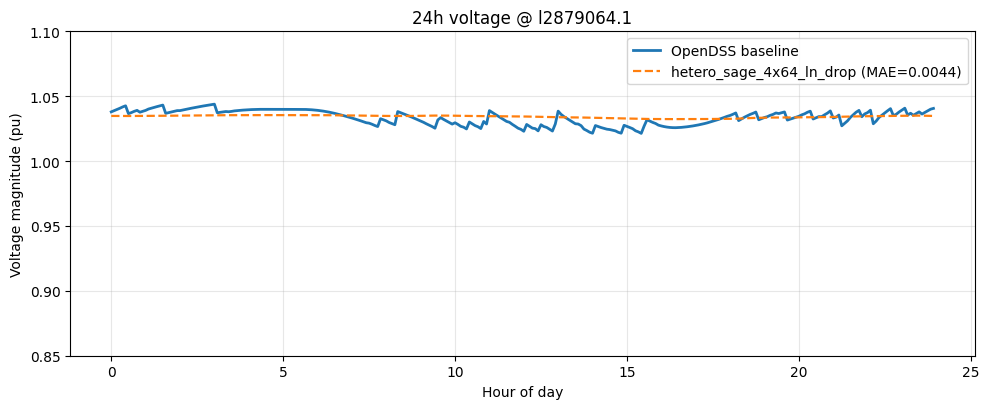

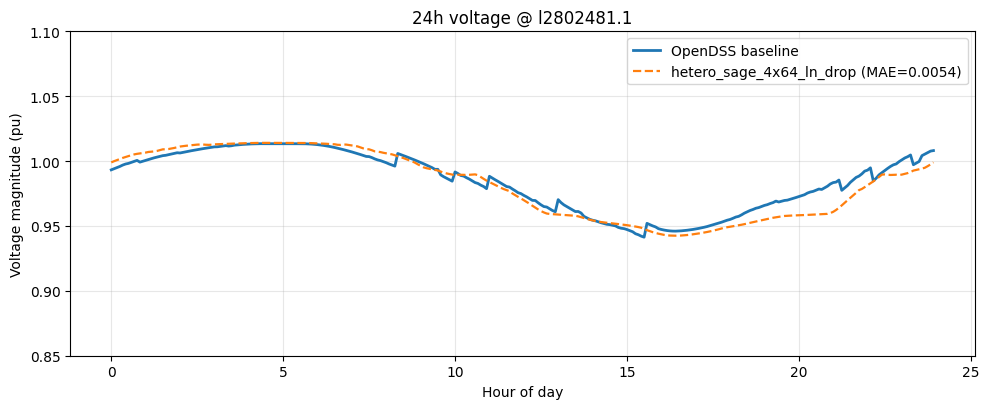

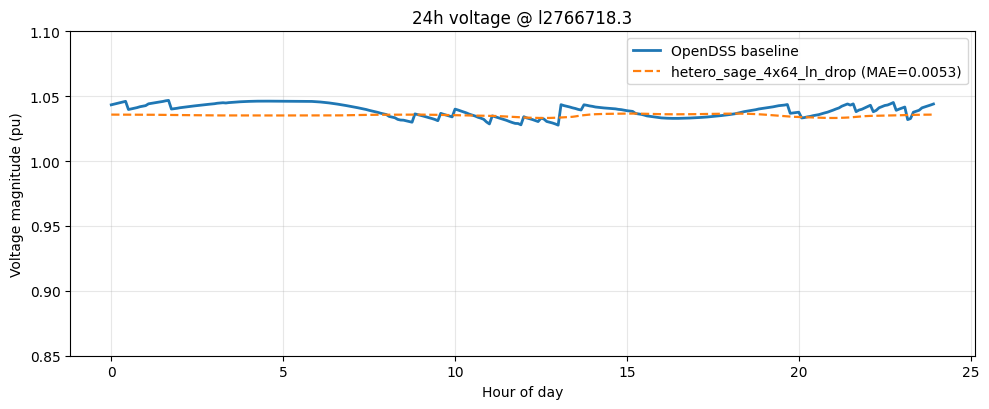

[compare_hetero_mv_daily] warning: node 'regxfmr_190-8593.1' is hetero type 'upstream' but checkpoint only supervised ['load'] — GNN curve is not meaningful.


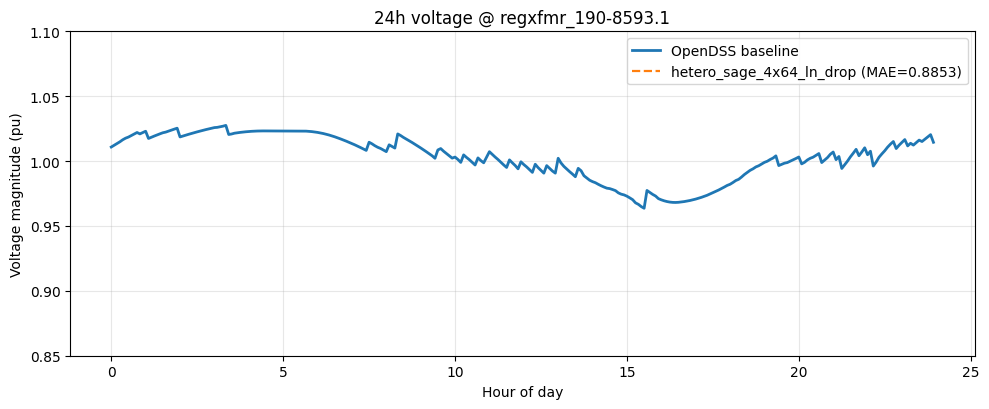

[compare_hetero_mv_daily] warning: node 'q16483.3' is hetero type 'capacitor' but checkpoint only supervised ['load'] — GNN curve is not meaningful.


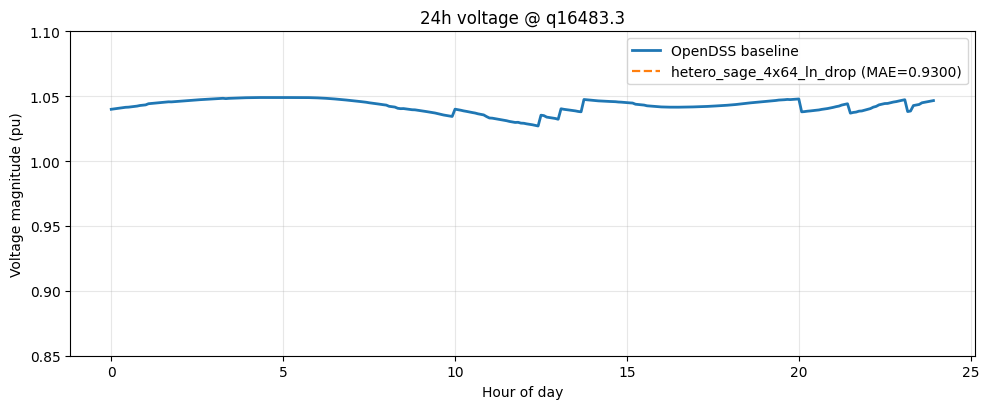

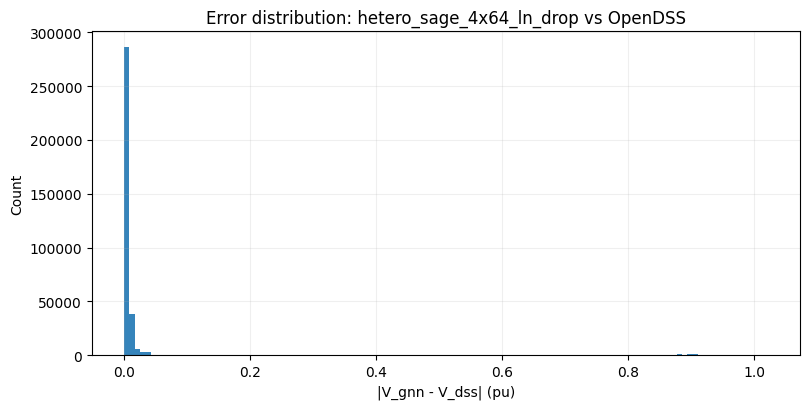


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output
                  node      mae
    regxfmr_190-8581.3 1.003321
              q16642.3 0.951004
            l2823592.3 0.947755
regxfmr_hvmv_sub_lsb.3 0.942597
              q16642.1 0.941463
              q16483.2 0.932233
              r18242.3 0.932096
              q16483.3 0.929968
              r18242.1 0.925738
regxfmr_hvmv_sub_lsb.1 0.911789


In [33]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
from compare_hetero_mv_daily_wrappers import run_sage_not_edge_aware, run_gine_edge_aware, run_homo_gine_mv, run_homo_gcn_mv
run_sage_not_edge_aware()
#run_gine_edge_aware()
#run_homo_gine_mv()
#run_homo_gcn_mv()  

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_hetero_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[hetero_gine_3x80] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_hetero_mv_daily] model=hetero_gine_3x80 device=cpu
[compare_hetero_mv_daily] checkpoint meta: target_node_types=all (if meta missing, assume all storages supervised)
[compare_hetero_mv_daily] GINE: reg edge_attr from OpenDSS each step (12 RegControls)
[reg_tap_diag] catalog: 12 regulator edges; Regulator labels missing from REGULATOR_TO_TAP_COL: 0; tap_column != map: 0
[reg_tap_diag] hetero_mv_regulator_edge_features.csv: 12 regulator edge_ids; global reg_tap_pu min/max over all samples: 0.981250 / 1.100000 pu
[reg_tap_diag]   edge_id=4 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=11 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=21 training reg_tap_pu: min=0.993750 max=1.056250 n=9907
[compare_hetero_mv_daily]

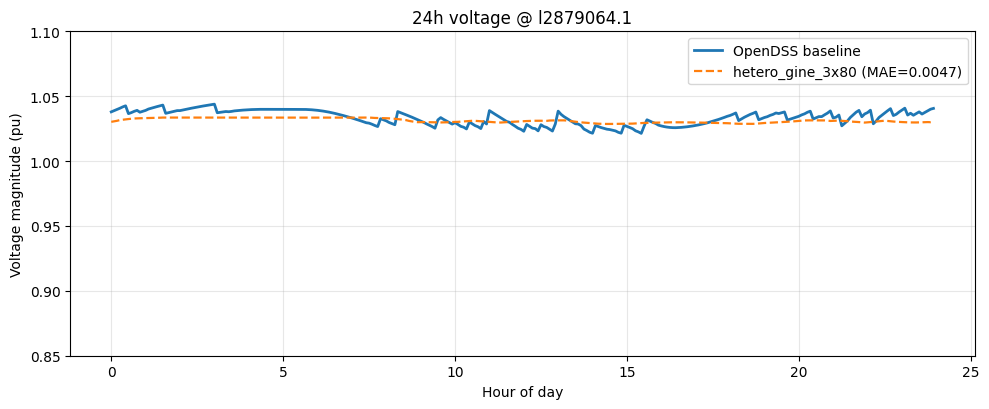

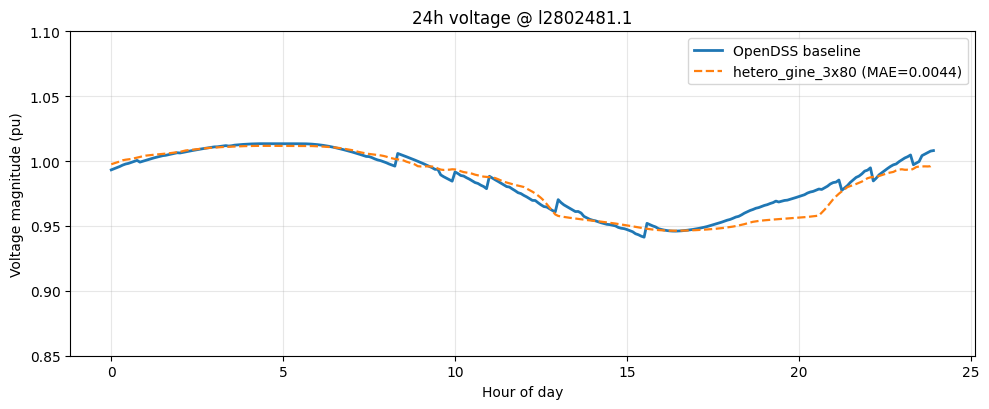

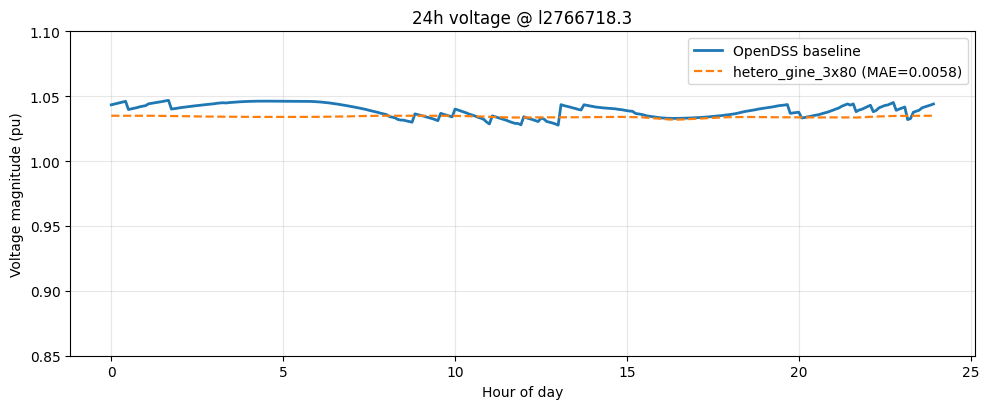

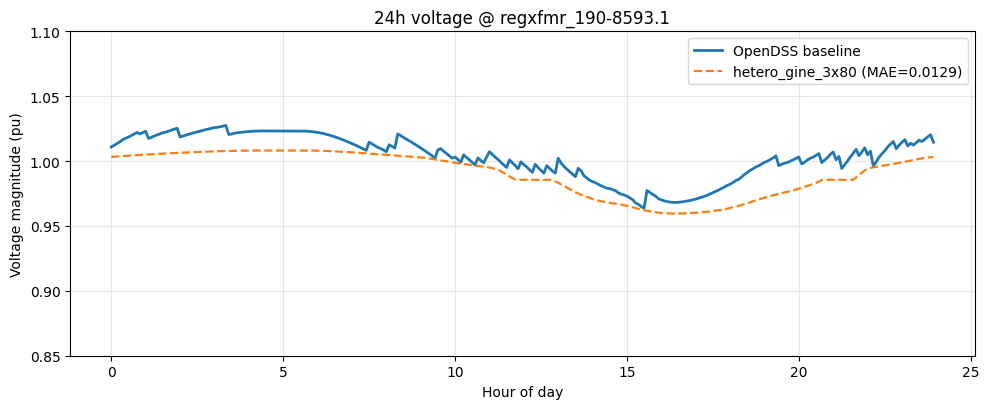

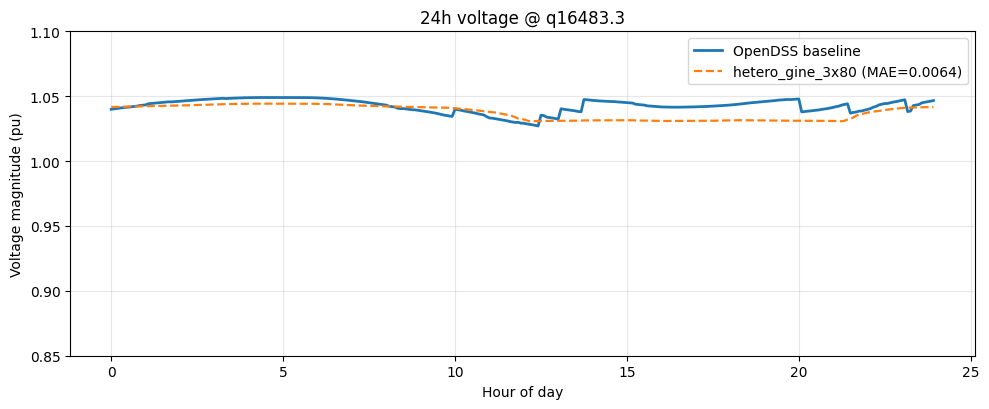

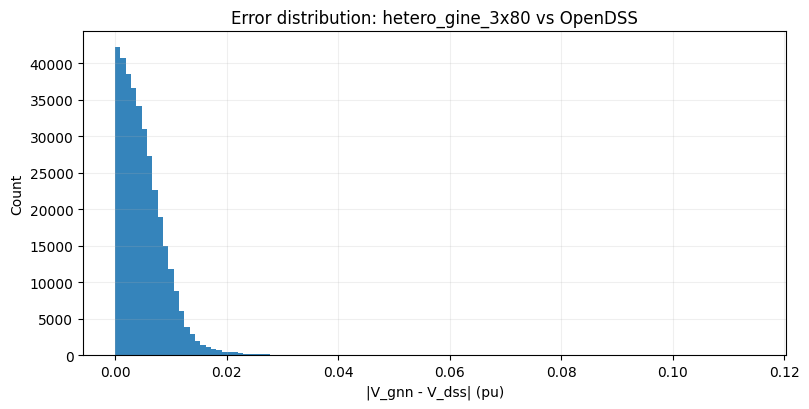


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_gine_edgeaware
      node      mae
l3123509.3 0.023229
l2730108.3 0.021908
l3011293.3 0.021512
l2842384.3 0.020192
l3048966.3 0.019619
l2936268.3 0.019046
l3030203.3 0.019011
l3030205.3 0.018810
l3179673.3 0.017502
l3234149.3 0.017287


In [34]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
from compare_hetero_mv_daily_wrappers import run_sage_not_edge_aware, run_gine_edge_aware, run_homo_gine_mv, run_homo_gcn_mv
#run_sage_not_edge_aware()
run_gine_edge_aware()
#run_homo_gine_mv()
#run_homo_gcn_mv()  

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_homo_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] resolved checkpoint -> C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\GINE-128-4\homo_gine_h128_L4_best.pt
[compare_homo_mv_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_homo_mv_daily] model=gine hidden=128 L=4 N=1177 device=cpu
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.11s reassert=0.00s solve_only=3.89s | get V=0.86s | homo feat=0.16s | GNN bucket=1.57s fwd-only=1.55s
[48/288] timing — apply=0.21s reassert=0.00s solve_only=7.69s | get V=2.19s | homo feat=0.31s | GNN bucket=3.13s fwd-only=3.08s
[72/2

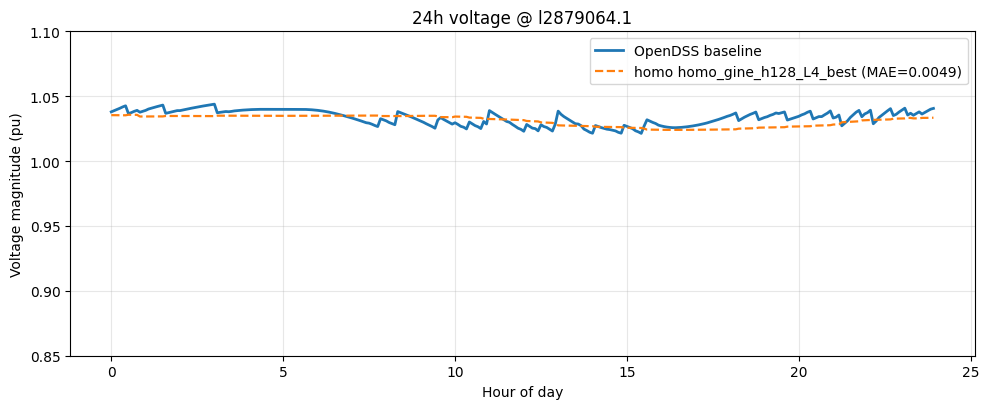

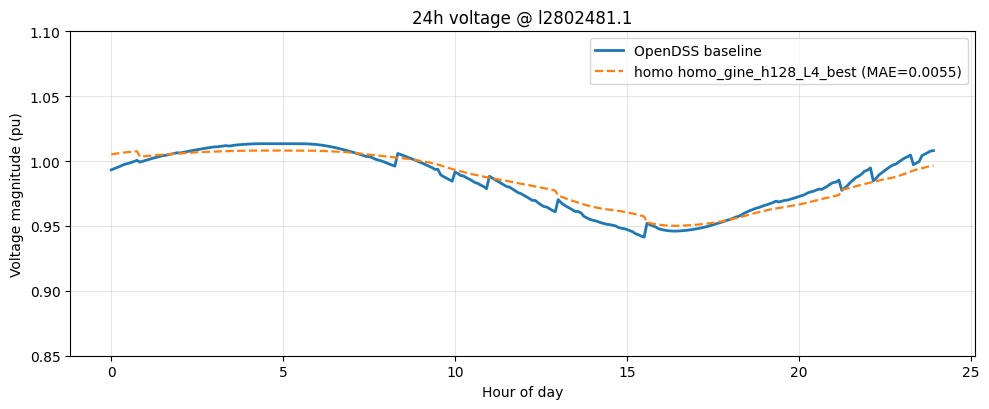

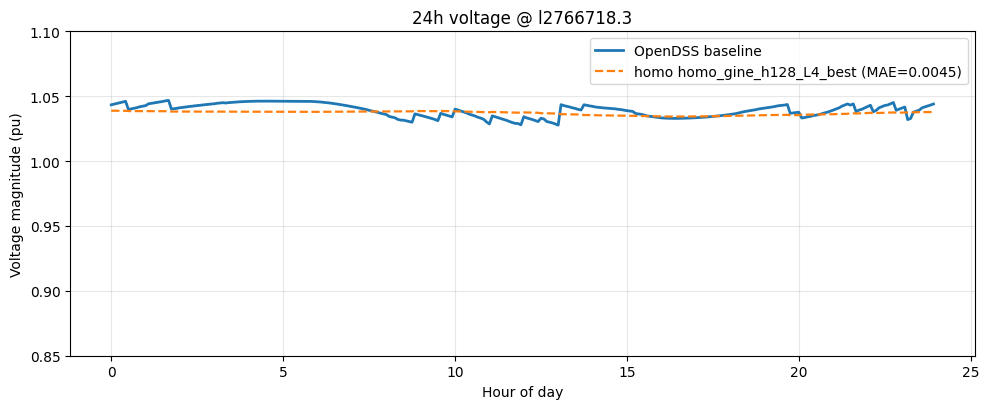

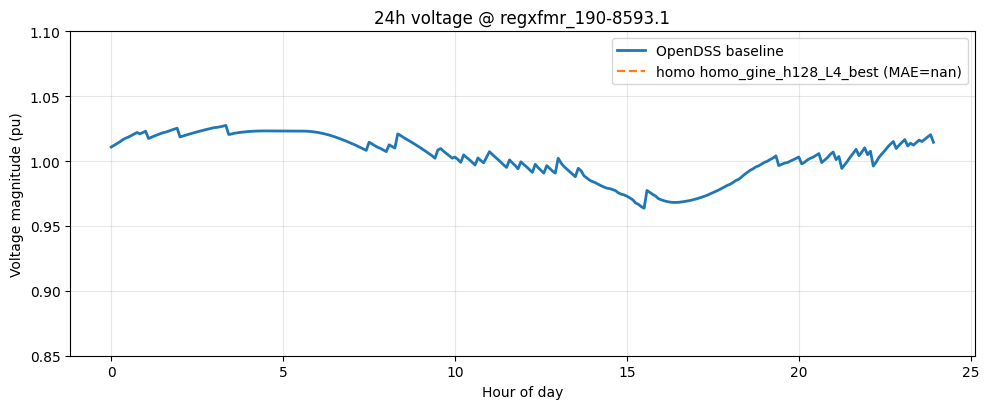

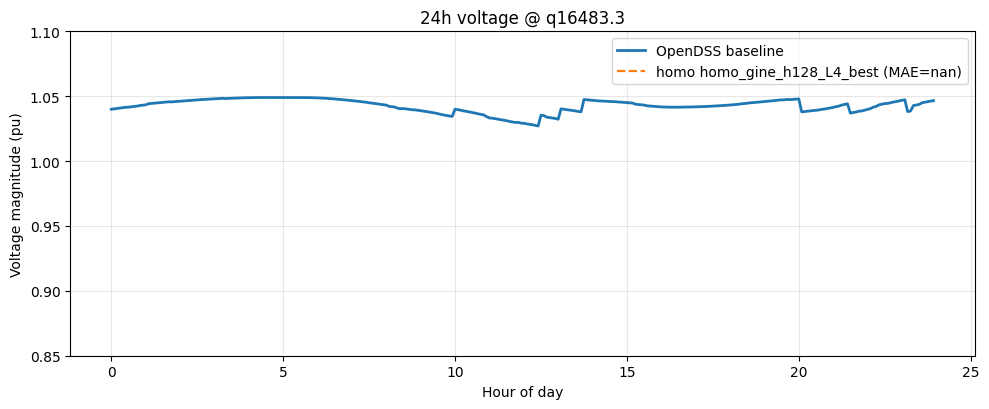

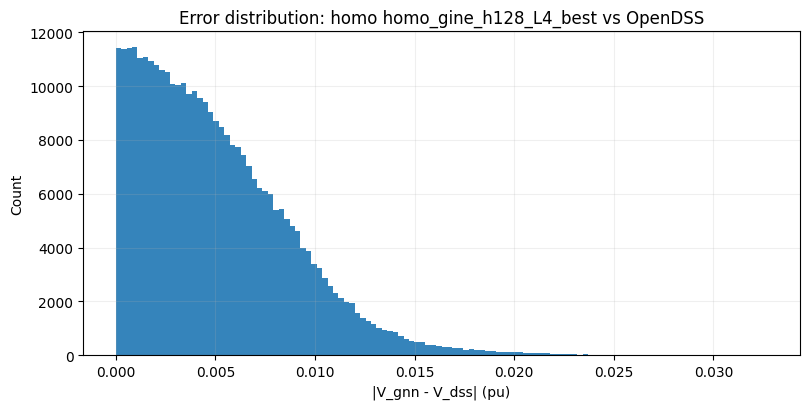


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_homo_gine
      node      mae
l3139103.1 0.016565
l2673318.3 0.015344
l3214112.2 0.015105
l3312692.1 0.014464
l2691947.1 0.014332
l3216348.1 0.013243
l3254216.1 0.012711
l3101787.1 0.012580
l3254214.2 0.012378
l3101788.1 0.012276


In [37]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
from compare_hetero_mv_daily_wrappers import run_sage_not_edge_aware, run_gine_edge_aware, run_homo_gine_mv, run_homo_gcn_mv
#run_sage_not_edge_aware()
#run_gine_edge_aware()
run_homo_gine_mv()
#run_homo_gcn_mv()  

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_homo_mv_daily] inference device: cpu (set device= or env GNN_COMPARE_DEVICE=auto|cpu|cuda)
[compare_homo_mv_daily] resolved checkpoint -> C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\GCN-64-3\homo_gcn_h64_L3_best.pt
[compare_homo_mv_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_homo_mv_daily] model=gcn hidden=64 L=3 N=1177 device=cpu
[compare_homo_mv_daily] OpenDSS: snapshot mode for each Solve() (not daily marching).
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.10s reassert=0.00s solve_only=4.15s | get V=0.90s | homo feat=0.16s | GNN bucket=0.72s fwd-only=0.70s
[48/288] timing — apply=0.20s reassert=0.00s solve_only=7.93s | get V=1.77s | homo feat=0.32s | GNN bucket=1.32s fwd-only=1.28s
[72/288] ti

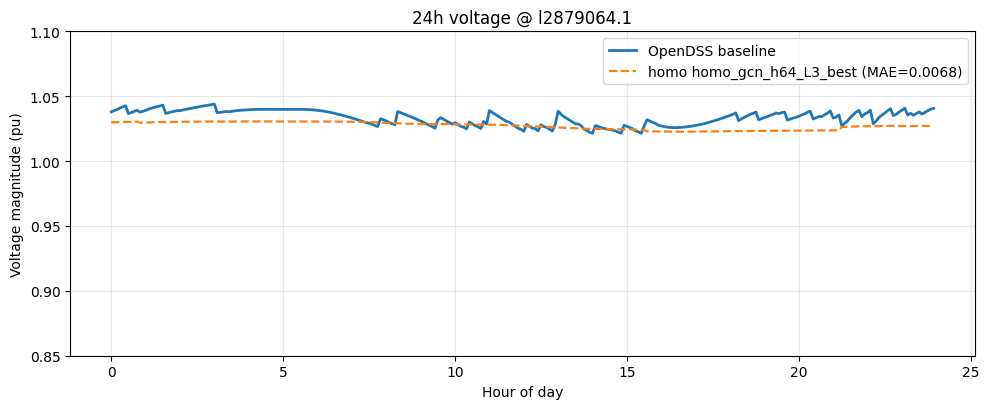

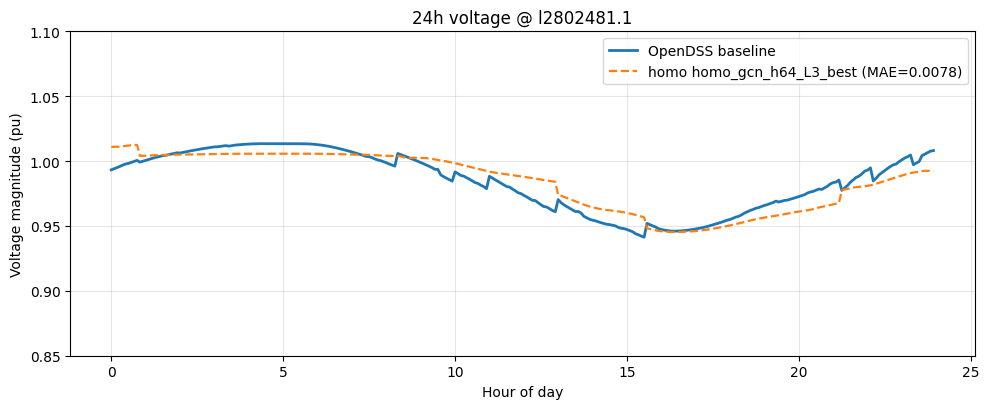

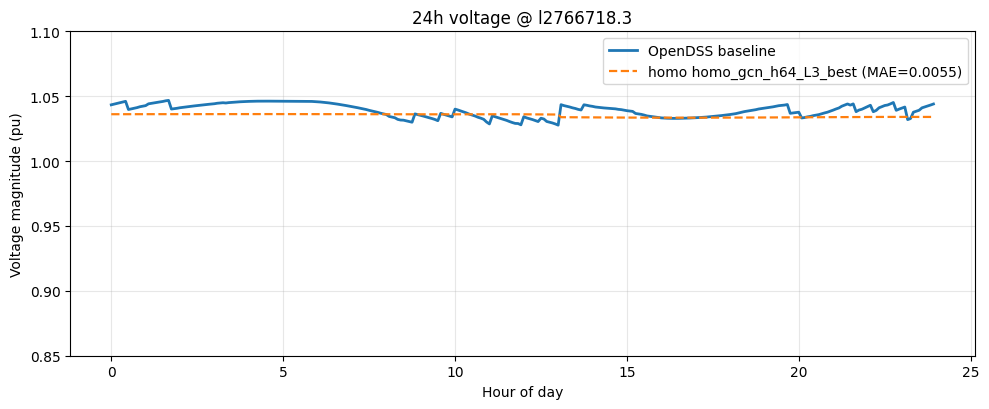

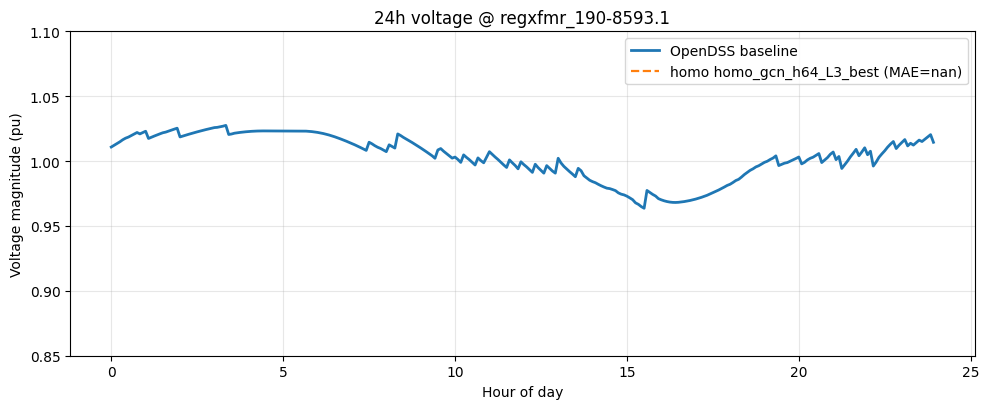

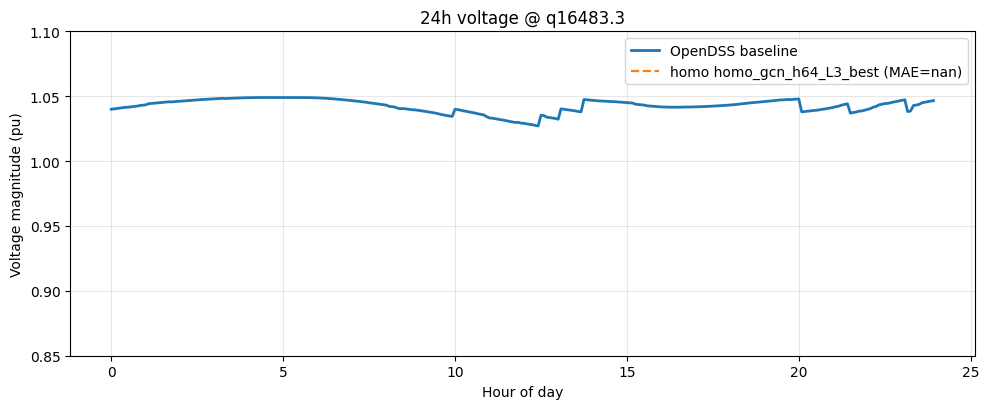

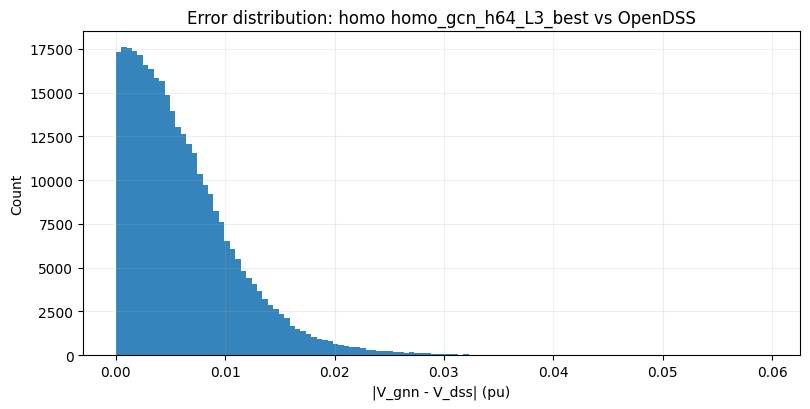


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_homo_gcn
      node      mae
l2936270.1 0.037016
l3086078.1 0.036235
l2823592.1 0.032598
l2823611.1 0.025775
l3217056.1 0.025488
l3217057.1 0.024670
l3030204.1 0.021718
l3141401.1 0.018850
l3104129.1 0.016827
l2972930.1 0.014630


In [38]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
from compare_hetero_mv_daily_wrappers import run_sage_not_edge_aware, run_gine_edge_aware, run_homo_gine_mv, run_homo_gcn_mv
#run_sage_not_edge_aware()
#run_gine_edge_aware()
#run_homo_gine_mv()
run_homo_gcn_mv()  

run with torch compile + snapshot open dss

[compare_homo_mv_daily] resolved checkpoint -> C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_architecture_search\homo_mv_8500\GCN\homo_gcn_h128_L4_best.pt
[compare_homo_mv_daily] torch.compile disabled (GNN_TORCH_COMPILE='0')
[compare_homo_mv_daily] model=gcn hidden=128 L=4 N=1177 device=cpu
[compare_homo_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_homo_mv_daily] feature diag (first step): nodes with |P|+|Q|>1e-3: 1171/1177
[24/288] timing — apply=0.18s solve=0.51s | get V=0.84s | homo feat=0.09s | GNN=0.58s
[48/288] timing — apply=0.37s solve=0.74s | get V=2.21s | homo feat=0.18s | GNN=1.16s
[72/288] timing — apply=0.58s solve=0.91s | get V=3.10s | homo feat=0.27s | GNN=1.77s
[96/288] timing — apply=0.77s solve=1.16s | get V=3.97s | homo feat=0.35s | GNN=2.37s
[120/288] timing — apply=0.95s solve=1.50s | get V=5.12s | homo feat=0.44s | GNN=2.96s
[144/288] timing — apply=1.13s solve=1.98s | get V=5.99s | hom

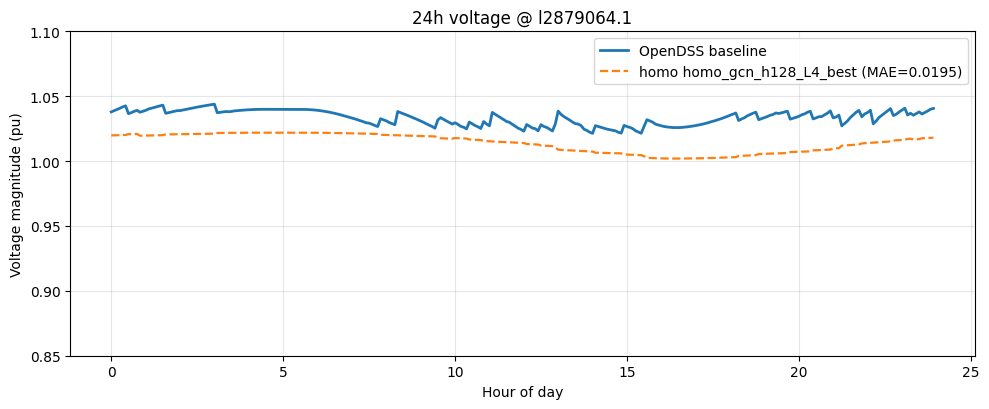

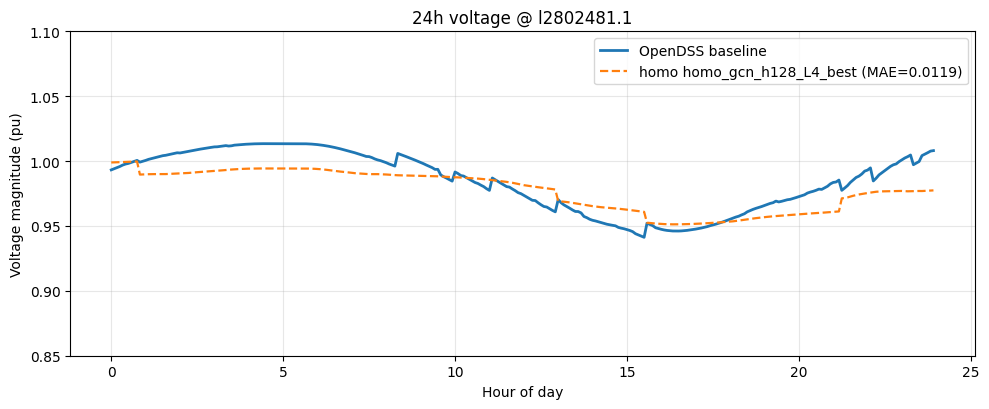

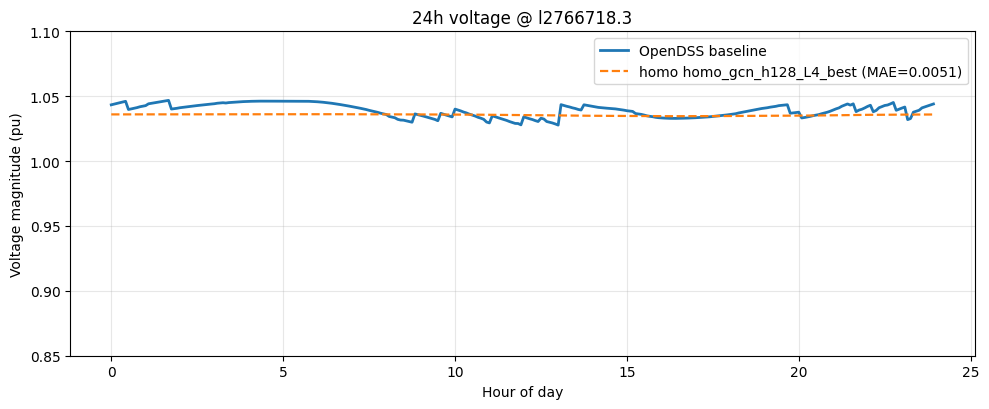

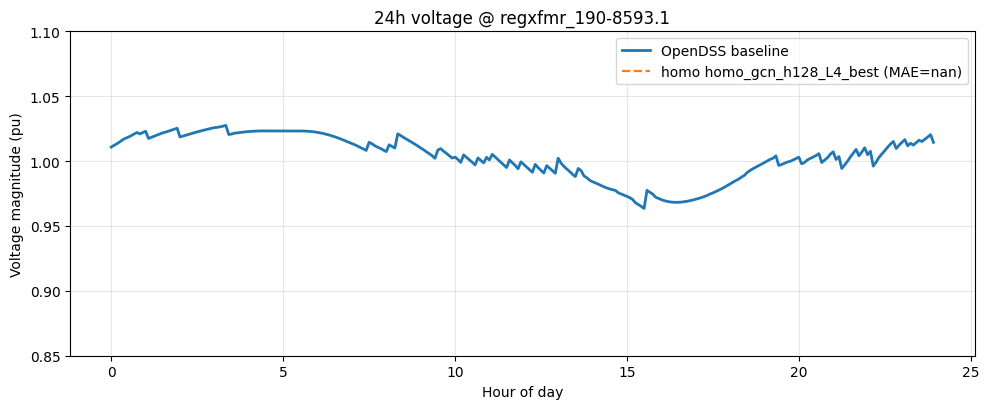

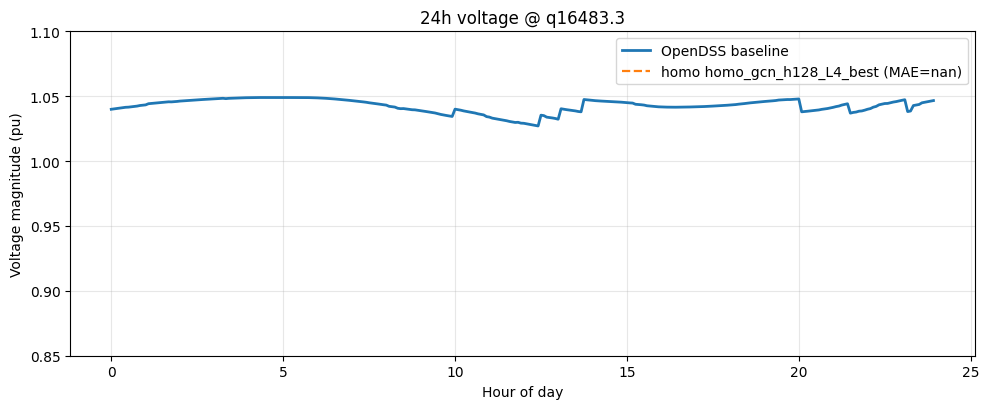

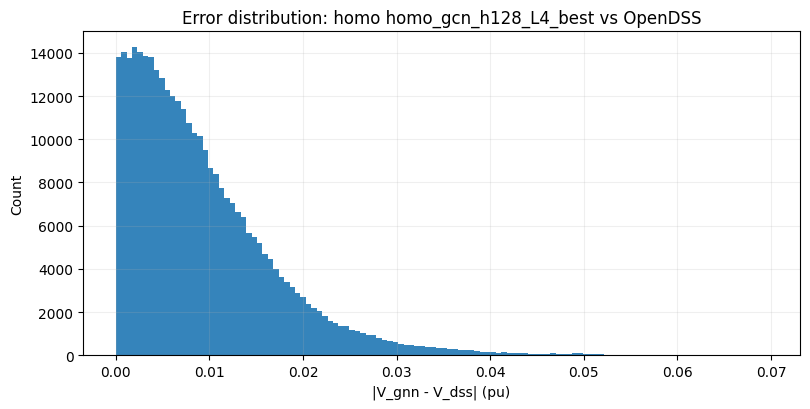


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_homo_gcn
      node      mae
l3179699.2 0.039594
l2805036.2 0.039442
l2786273.2 0.039137
l2729405.2 0.037995
l2785516.2 0.035682
l2823592.1 0.033549
l3108449.1 0.032838
l3011229.1 0.032585
l3065665.1 0.031587
l3235946.1 0.031495


In [27]:
from compare_hetero_mv_daily_wrappers import run_homo_gcn_mv
run_homo_gcn_mv()

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_hetero_mv_daily] juxtapose: mode=both_fail_dss  A=hetero_sage_4x64_ln_drop (gine=False)  B=hetero_gine_3x80 (gine=True)  device=cpu
[compare_hetero_mv_daily] juxtapose: regulator taps from OpenDSS (12 RegControls)
[reg_tap_diag] catalog: 12 regulator edges; Regulator labels missing from REGULATOR_TO_TAP_COL: 0; tap_column != map: 0
[reg_tap_diag] hetero_mv_regulator_edge_features.csv: 12 regulator edge_ids; global reg_tap_pu min/max over all samples: 0.981250 / 1.100000 pu
[reg_tap_diag]   edge_id=4 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=11 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=21 training reg_tap_pu: min=0.993750 max=1.056250 n=9907
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] juxtapose feature diag: hetero load slots with |P|+|Q|>1e-3: 1171/1177


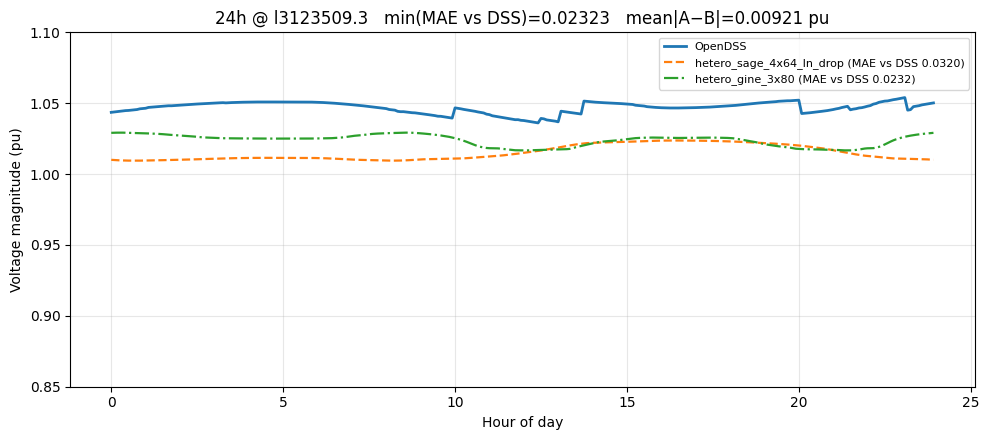

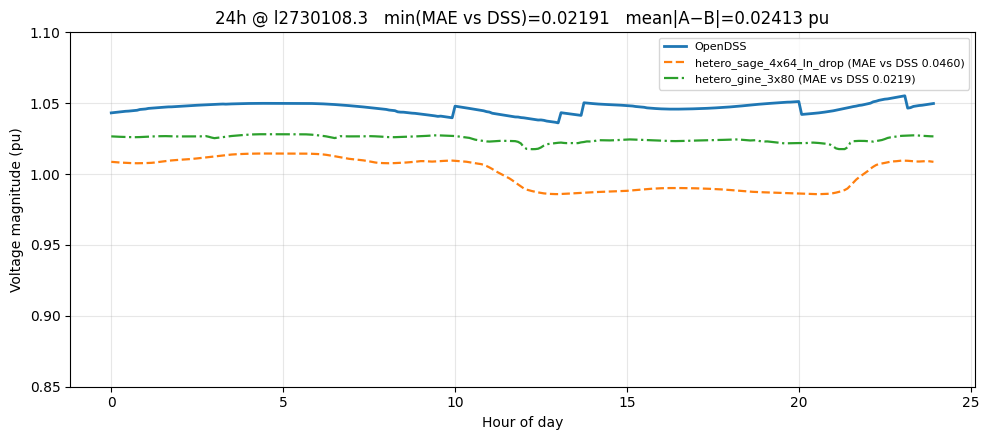

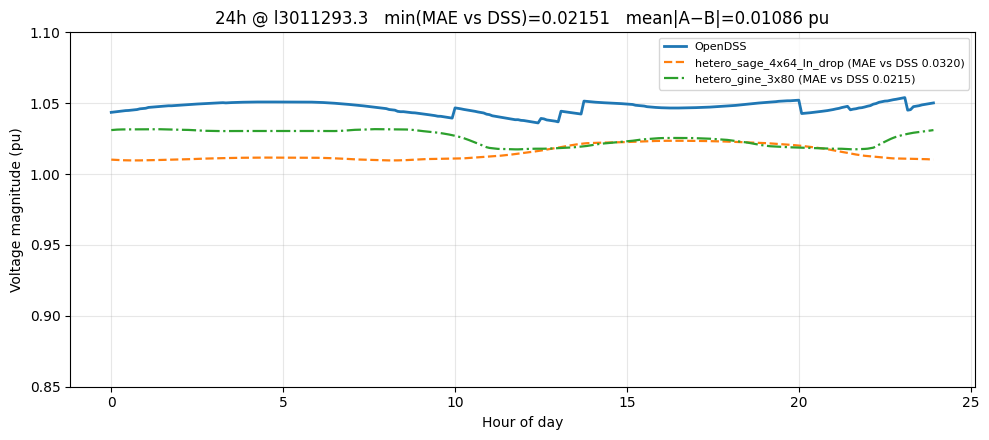

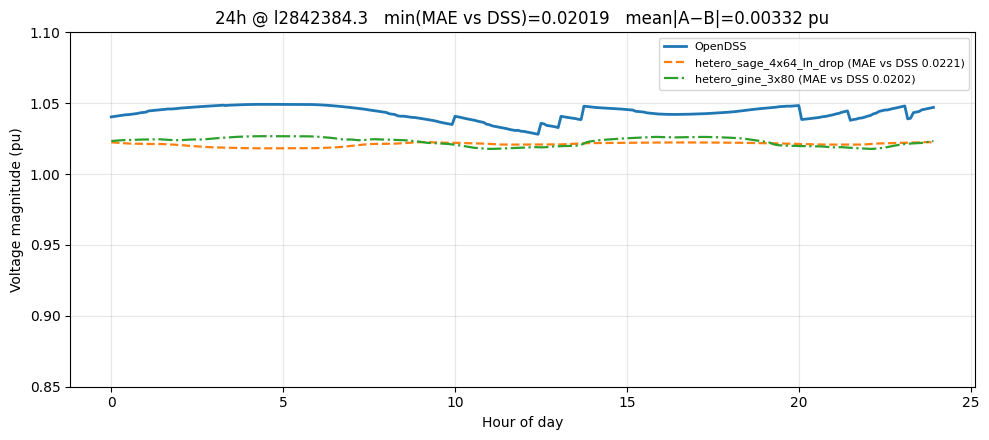

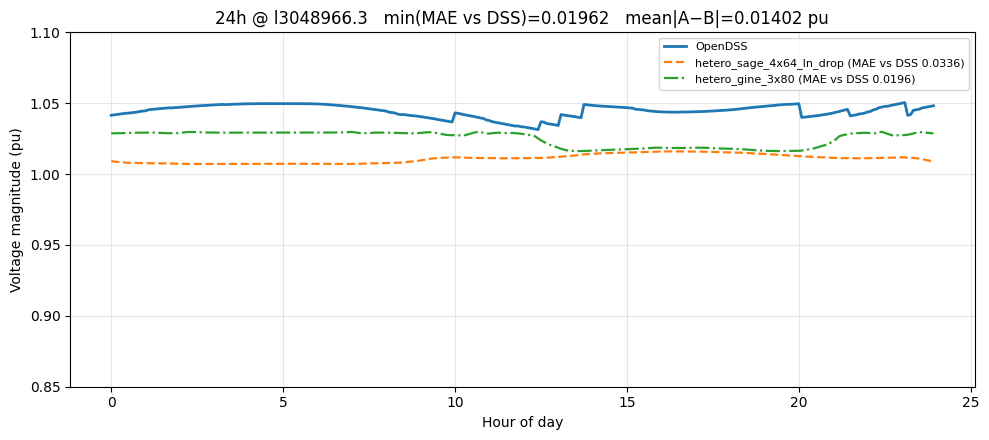

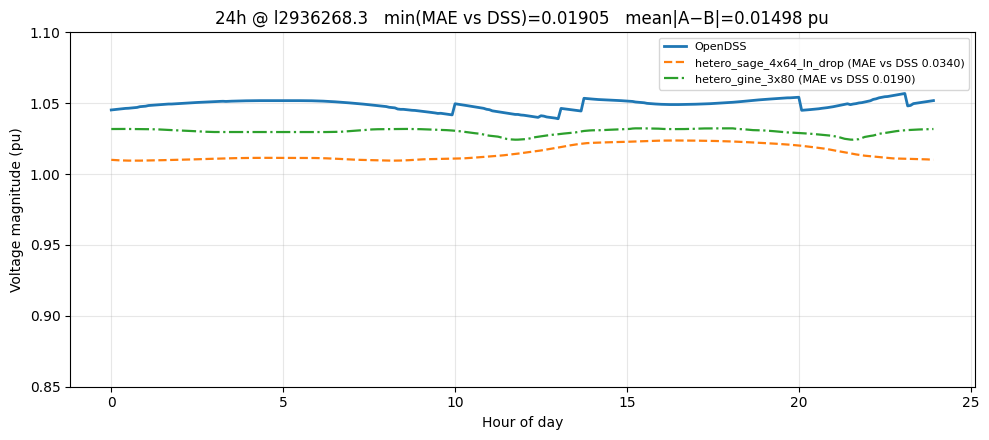

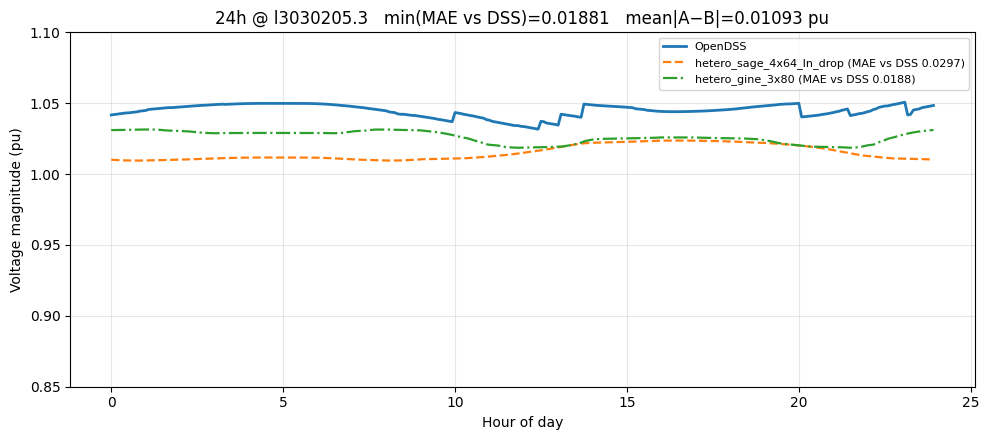

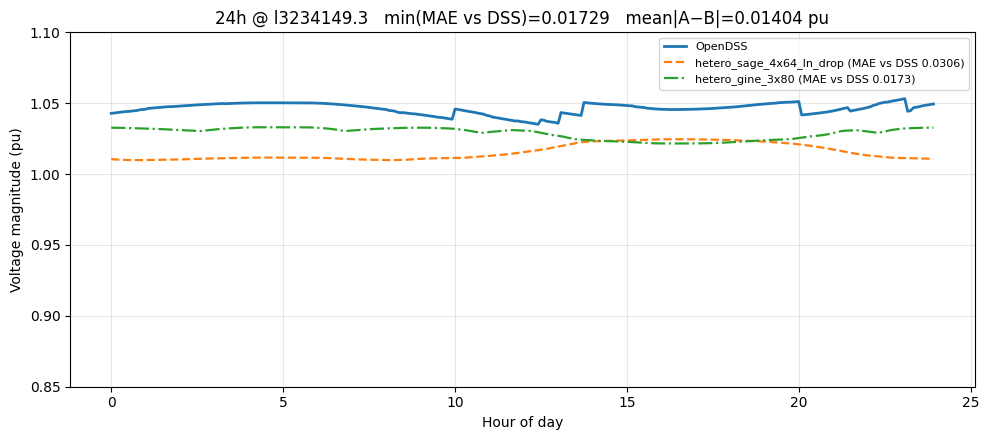

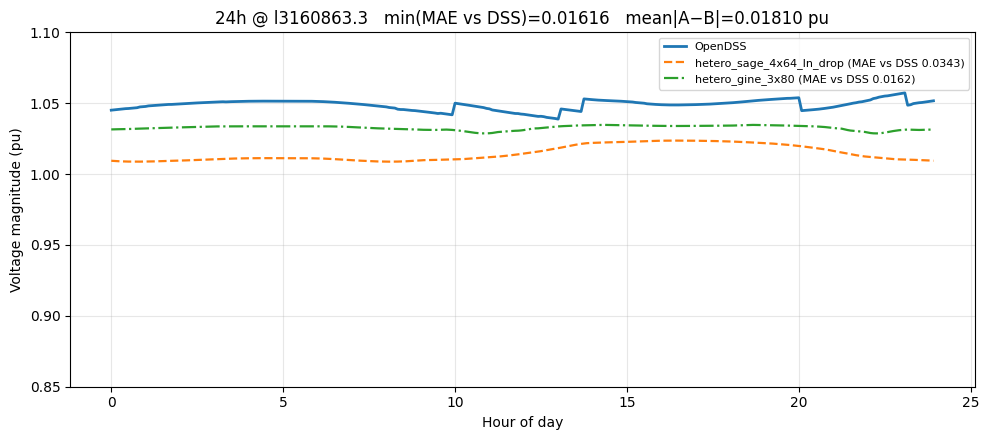

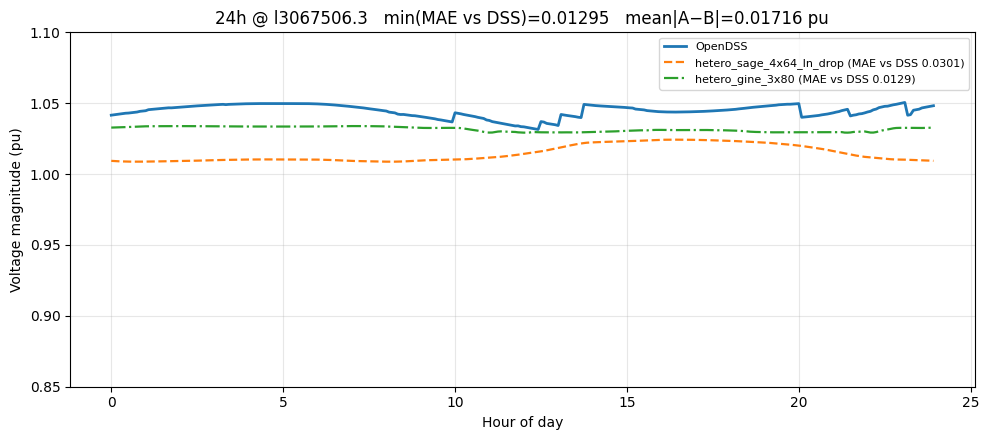


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_both_fail_vs_dss
      node hetero_type  mae_a_vs_dss_pu  mae_b_vs_dss_pu  min_mae_vs_dss_pu  max_mae_vs_dss_pu  mean_combined_err_vs_dss_pu  mean_abs_diff_ab_pu
l3123509.3        load         0.032022         0.023231           0.023231           0.032022                     0.027626             0.009215
l2730108.3        load         0.046036         0.021910           0.021910           0.046036                     0.033973             0.024126
l3011293.3        load         0.031981         0.021515           0.021515           0.031981                     0.026748             0.010863
l2842384.3        load         0.022128         0.020195           0.020195           0.022128                     0.021161             0.003319
l3048966.3        load         0.033641         0.019621           0.019621           0.033641                     0.026631             0.014020
l2936268.3        load         0.0340

In [3]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
%run juxtapose_both_fail_vs_dss_daily.py

c:\Users\alita\OneDrive\Desktop\GNN2
[compare_hetero_mv_daily] juxtapose: mode=lowest_min_v_dss  A=hetero_sage_4x64_ln_drop (gine=False)  B=hetero_gine_3x80 (gine=True)  device=cpu
[compare_hetero_mv_daily] juxtapose: regulator taps from OpenDSS (12 RegControls)
[reg_tap_diag] catalog: 12 regulator edges; Regulator labels missing from REGULATOR_TO_TAP_COL: 0; tap_column != map: 0
[reg_tap_diag] hetero_mv_regulator_edge_features.csv: 12 regulator edge_ids; global reg_tap_pu min/max over all samples: 0.981250 / 1.100000 pu
[reg_tap_diag]   edge_id=4 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=11 training reg_tap_pu: min=1.000000 max=1.100000 n=9907
[reg_tap_diag]   edge_id=21 training reg_tap_pu: min=0.993750 max=1.056250 n=9907
[compare_hetero_mv_daily] mv↔sx mapping: 1177 rules from C:\Users\alita\OneDrive\Desktop\GNN2\8500-node\mv_x_sx_node_mapping_8500.csv
[compare_hetero_mv_daily] juxtapose feature diag: hetero load slots with |P|+|Q|>1e-3: 1171/11

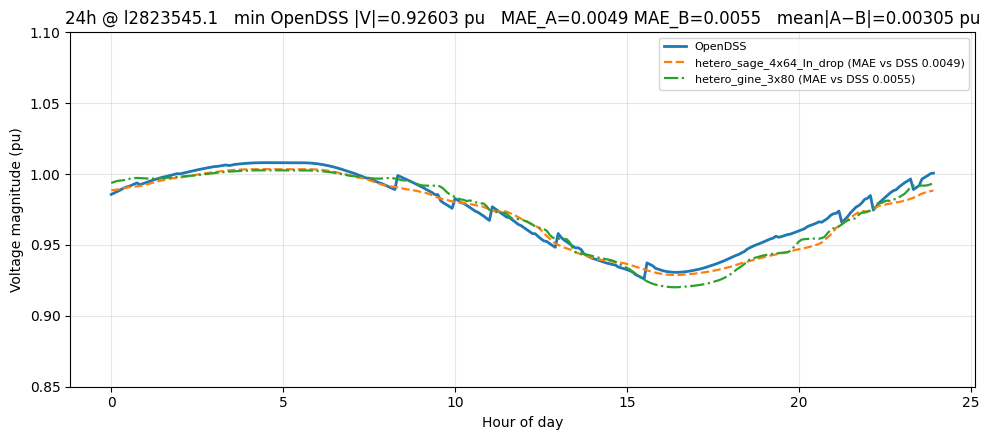

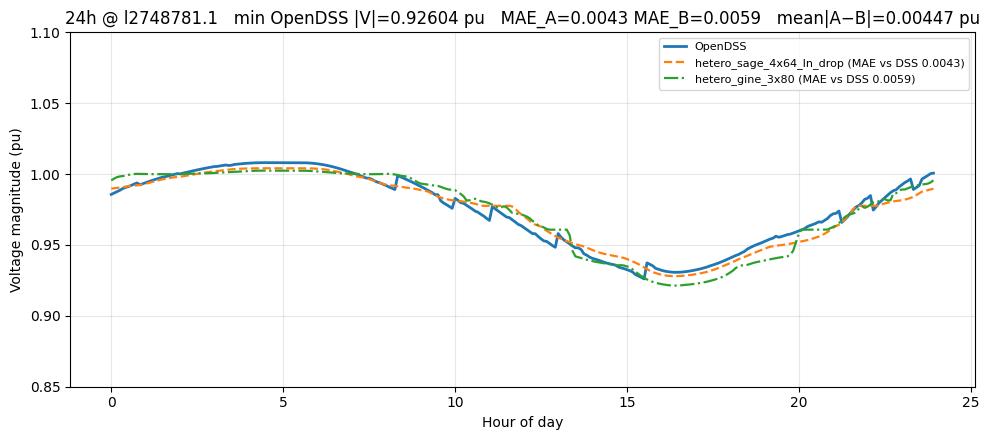

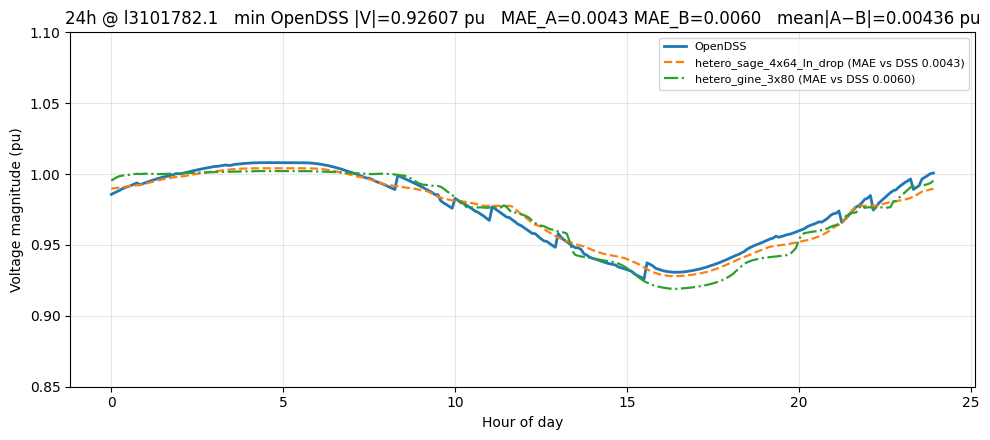

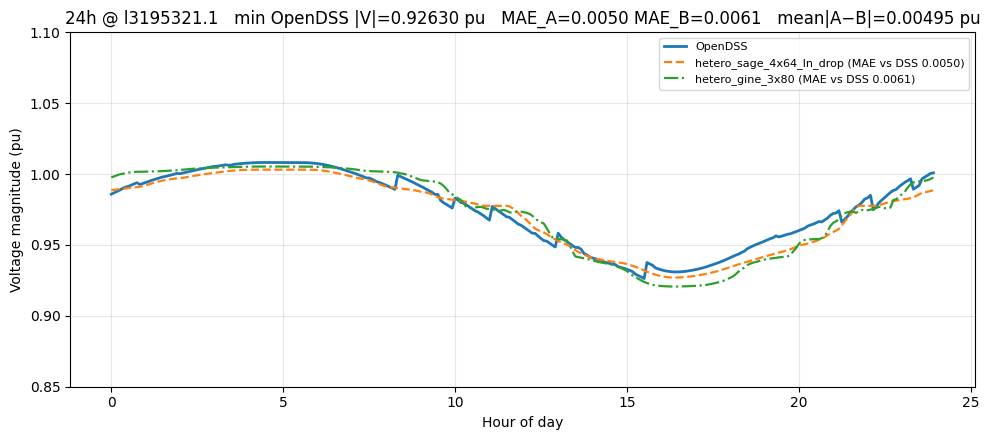

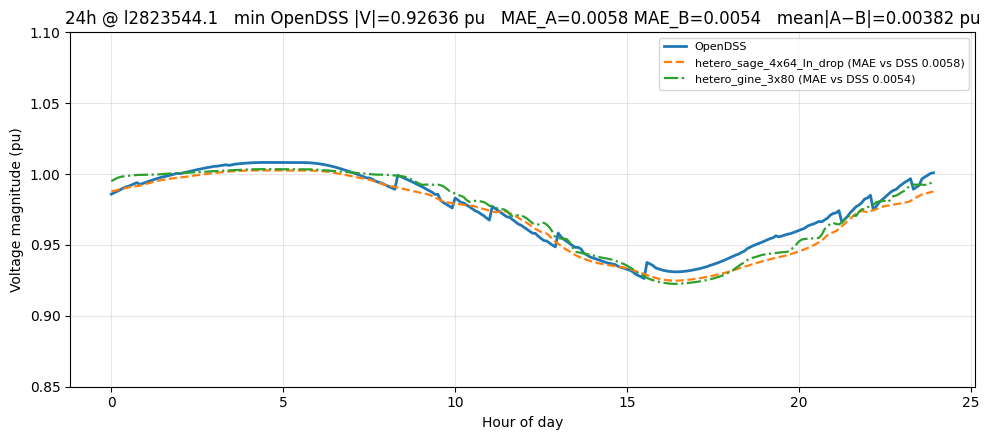


Saved: C:\Users\alita\OneDrive\Desktop\GNN2\gnn2_daily_compare_8500_output_lowest_min_v_top5
      node hetero_type  min_v_open_dss_pu  max_v_open_dss_pu  mae_a_vs_dss_pu  mae_b_vs_dss_pu  mean_abs_diff_ab_pu
l2823545.1        load           0.926035           1.008060         0.004873         0.005531             0.003051
l2748781.1        load           0.926042           1.008064         0.004337         0.005903             0.004465
l3101782.1        load           0.926073           1.008079         0.004344         0.005972             0.004362
l3195321.1        load           0.926301           1.008194         0.005047         0.006124             0.004947
l2823544.1        load           0.926365           1.008227         0.005761         0.005381             0.003823
l2748780.1        load           0.926510           1.008300         0.005697         0.004625             0.006285
l2767342.1        load           0.926630           1.008361         0.004750         0.004133

In [6]:
%cd C:\Users\alita\OneDrive\Desktop\GNN2
%run juxtapose_lowest_min_v_top5_daily.py

## Load → regulator electrical distances

Runs `compute_load_electrical_distance_to_regulators.py` on the hetero MV bundle.

**What it produces:** `edges/load_electrical_distance_to_each_regulator.csv`  
- Rows: load nodes from `hetero_mv_nodes_load_transformer.csv`  
- Columns: `node`, then one column per **Regulator** name  
- **Numeric cell:** cumulative Ω (√(R²+X²) summed along lines) from that regulator’s **downstream** terminal (`terminal_2`) to the load, **only if** downstream on the static graph  
- **Empty cell:** not downstream of that regulator  

**Inputs (defaults):**  
`hetero_mv_edge_catalog.csv`, `hetero_mv_line_edge_attr.csv`, `regulator_involved_nodes.csv`, `gnn_node_index_master.csv`, load node CSV under `nodes/`.

**Run:** set `REPO` to your clone, then execute the next cell.

In [9]:
import subprocess
import sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
DATASET = REPO / "datasets_gnn2/loadtype_8500_dailyagg/Heterogenous GNN dataset"

script = REPO / "compute_load_electrical_distance_to_regulators.py"
assert script.is_file(), script
assert (DATASET / "edges" / "hetero_mv_edge_catalog.csv").is_file(), (
    "Missing catalog; fix DATASET path."
)

cmd = [
    sys.executable,
    str(script),
    "--dataset-dir",
    str(DATASET),
]
print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = DATASET / "edges" / "load_electrical_distance_to_each_regulator.csv"
print("Output:", out.resolve())
print("Exists:", out.is_file())

Running: c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\compute_load_electrical_distance_to_regulators.py --dataset-dir C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset
Output: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\edges\load_electrical_distance_to_each_regulator.csv
Exists: True


## Load transformer × (reg distance × tap)

Runs `merge_load_transformer_reg_dist_times_tap.py`.

**Inputs**
- `nodes/hetero_mv_nodes_load_transformer.csv` — all original columns kept  
- `edges/load_electrical_distance_to_each_regulator.csv` — Ω per load per regulator  
- `gnn_sample_meta.csv` — `reg_feeder_*_tap_pu`, `reg_vreg*_tap_pu`  

**New columns (12):**  
`FEEDER_REGA` … `VREG4_C` = `distance × tap_pu` for that row’s `node` and `sample_id`.

**Output:**  
`nodes/hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv`  

Run the next cell after `load_electrical_distance_to_each_regulator.csv` exists.

In [3]:
import subprocess, sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
ROOT = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg"

script = REPO / "merge_load_transformer_reg_dist_times_tap.py"
assert script.is_file()

cmd = [sys.executable, str(script), "--dataset-root", str(ROOT)]
print(" ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = ROOT / "Heterogenous GNN dataset" / "nodes" / "hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv"
print("Written:", out.resolve(), out.is_file())

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\merge_load_transformer_reg_dist_times_tap.py --dataset-root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
Written: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv True


In [4]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_dist_x_tap.csv")
df = pd.read_csv(path, nrows=20)
print(df.to_string())
# or: display(df)   # in Jupyter

    sample_id        node  node_idx  electrical_distance_ohm  p_load_kw  q_load_kvar  q_capacitor_bank   vmag_pu    vang_deg  FEEDER_REGA  FEEDER_REGB  FEEDER_REGC   VREG2_A   VREG2_B  VREG2_C   VREG3_A   VREG3_B  VREG3_C  VREG4_A   VREG4_B   VREG4_C
0           0  l2673322.2        12                13.326756   1.711504     0.458415               0.0  1.032566 -157.452714     0.000000    13.312103     0.000000  0.000000  6.317540      0.0  0.000000  8.894349      0.0      0.0  0.000000  0.000000
1           0  l2673309.3        14                 9.829356   4.369270     1.187493               0.0  1.038601   85.121515     0.000000     0.000000     9.798615  0.000000  0.000000      0.0  0.000000  0.000000      0.0      0.0  0.000000  3.301291
2           0  l2804270.2        16                 7.902460   2.723958     0.641758               0.0  1.040575 -156.650368     0.000000     7.868016     0.000000  0.000000  0.000000      0.0  0.000000  3.382211      0.0      0.0  0.000000  0.000

In [9]:
import subprocess, sys
from pathlib import Path

REPO = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2").resolve()
ROOT = REPO / "datasets_gnn2" / "loadtype_8500_dailyagg"

script = REPO / "merge_load_transformer_reg_tap_only.py"
assert script.is_file()

cmd = [sys.executable, str(script), "--dataset-root", str(ROOT)]
print(" ".join(cmd))
subprocess.run(cmd, cwd=str(REPO), check=True)

out = ROOT / "Heterogenous GNN dataset" / "nodes" / "hetero_mv_nodes_load_transformer_reg_tap_only.csv"
print("Written:", out.resolve(), out.is_file())

c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Scripts\python.exe C:\Users\alita\OneDrive\Desktop\GNN2\merge_load_transformer_reg_tap_only.py --dataset-root C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg
Written: C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv True


In [10]:
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2\loadtype_8500_dailyagg\Heterogenous GNN dataset\nodes\hetero_mv_nodes_load_transformer_reg_tap_only.csv")
df = pd.read_csv(path, nrows=20)
print(df.to_string())
# or: display(df)   # in Jupyter

    sample_id        node  node_idx  electrical_distance_ohm  p_load_kw  q_load_kvar  q_capacitor_bank   vmag_pu    vang_deg  FEEDER_REGA  FEEDER_REGB  FEEDER_REGC  VREG2_A  VREG2_B  VREG2_C  VREG3_A  VREG3_B  VREG3_C  VREG4_A  VREG4_B  VREG4_C
0           0  l2673322.2        12                13.326756   1.711504     0.458415               0.0  1.032566 -157.452714          0.0          1.0          0.0   0.0000  1.00625      0.0    0.000   1.0125      0.0      0.0  0.00000      0.0
1           0  l2673309.3        14                 9.829356   4.369270     1.187493               0.0  1.038601   85.121515          0.0          0.0          1.0   0.0000  0.00000      0.0    0.000   0.0000      0.0      0.0  0.00000      1.0
2           0  l2804270.2        16                 7.902460   2.723958     0.641758               0.0  1.040575 -156.650368          0.0          1.0          0.0   0.0000  0.00000      0.0    0.000   1.0125      0.0      0.0  0.00000      0.0
3           0  l2935

### What this run does
- Trains **one** model: **GINE** (`--model gine`).
- Default in script: **`--sample_frac 0.1`** (10% of timesteps) and **`--log_every 1`** (log every epoch). Use **`--sample_frac 1.0`** for the full dataset.
- Writes under `OUT_DIR`: best checkpoint (`homo_gine_h*_L*_best.pt`), `train_metrics.json`, and `feature_norm.pt` (unless `--no_normalize`).


In [ ]:
import os
import subprocess
import sys

REPO_DIR = "/content/GNN-Sandia"
DATA_ROOT = os.path.join(REPO_DIR, "datasets_gnn2", "loadtype_8500_dailyagg")
OUT_DIR = "/content/checkpoints_homo_gine"  # or e.g. "/content/drive/MyDrive/checkpoints_homo_gine"

assert os.path.isdir(DATA_ROOT), (
    "Set DATA_ROOT to your loadtype_8500_dailyagg folder (repo or Drive)."
)

cmd = [
    sys.executable,
    "train_homo_gine_csv.py",
    "--data_root", DATA_ROOT,
    "--nodes_csv", "Heterogenous GNN dataset/nodes/hetero_mv_nodes_load_transformer_reg_tap_only.csv",
    "--edge_catalog_csv", "Heterogenous GNN dataset/edges/hetero_mv_edge_catalog.csv",
    "--out_dir", OUT_DIR,
    "--model", "gine",
    "--hidden", "128",
    "--layers", "4",
    "--epochs", "300",
    "--batch_size", "16",
    # "--sample_frac", "1.0",  # uncomment for full dataset
]
subprocess.run(cmd, cwd=REPO_DIR, check=True)